# Edge Camera Pipeline — Per-Function Tutorial Notebook

**Capstone A3 Kelompok 2 — Filkom Universitas Brawijaya**

Notebook ini break down `edge_camera.py` menjadi 39 sections **per-function**, masing-masing dengan:

1. **Markdown** — penjelasan detail (apa, parameter, returns, why, edge cases)
2. **Source code** — function exact dari `edge_camera.py`
3. **Demo output** — visualisasi matplotlib atau print output

Total: 39 function/class + setup cells + summary = ~120 cells dengan baked-in output.

Notebook bukan untuk run inspection loop (untuk itu: `python3 edge_camera.py`). Tujuan: deep understanding setiap function.


## 0. Setup — Mock Stream Module + Imports

Cell ini mock module `stream` (websocket publisher) supaya cell-cell selanjutnya bisa execute tanpa actual server. Plus imports common.

In [1]:
import sys, types, os
# Set __file__ untuk edge_camera.py top-level setup (uses os.path.dirname(__file__))
__file__ = '/Users/macbookpro/CAPSTONE/edge_camera.py'
# Mock stream module untuk demo (avoid websocket port conflicts)
mock_stream = types.ModuleType('stream')
mock_stream.start = lambda: False
mock_stream.publish = lambda f: None
mock_stream.poll_key = lambda: None
sys.modules['stream'] = mock_stream

# Mock requests untuk APIClient demo (tidak actually POST)
mock_requests = types.ModuleType('requests')
class MockResp:
    status_code = 200
    def json(self): return {'ok': True}
def mock_post(*a, **k): return MockResp()
mock_requests.post = mock_post
sys.modules['requests'] = mock_requests

# Common imports — gunakan IPython inline backend untuk plots ke-embed di notebook
get_ipython().run_line_magic('matplotlib', 'inline') if 'get_ipython' in dir() else None
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
plt.rcParams['figure.dpi'] = 80

# Avoid Config import-time print noise
np.random.seed(42)
print(f'Setup OK — OpenCV {cv2.__version__}, NumPy {np.__version__}')


Setup OK — OpenCV 4.13.0, NumPy 2.0.2


**Load top-level setup dari edge_camera.py** (imports, env vars, rembg conditional import, platform globals):

In [2]:
# -*- coding: utf-8 -*-
import os, sys, platform

os.environ.setdefault("PYTHONUTF8", "1")
if hasattr(sys.stdout, "reconfigure"):
    try:
        sys.stdout.reconfigure(encoding="utf-8", errors="replace")
    except Exception:
        pass

"""
edge_camera.py — KTP CAL WIZARD + DOMINANT-COLOR SEGMENTATION + CATALOG
========================================================================
Automated Dimensional Inspection · Capstone A3 Kelompok 2

Workflow:
  PHASE 1 — Kalibrasi KTP (sekali, mandatory di run pertama)
    • Tampilkan KTP Indonesia (85.6×53.98mm) ke kamera
    • Sistem deteksi ketat (aspect 1.585 ±6%, solidity ≥0.9, 4 sudut)
    • Validasi Y/N: "Apakah ini KTP yang akan dikalibrasi?"
    • Skala (px/mm) disimpan ke calibration.json

  PHASE 2 — Inspeksi Objek
    • Segmentasi per-frame: K-means K=2 di HSV → cluster dominan = background
    • Safeguard: cluster yang lebih dekat ke median warna pinggir frame =
      background (objek nggak akan ada di pinggir)
    • Pixel yang jauh dari warna bg di HSV (Otsu adaptive threshold) = objek
    • Skala pengukuran tetap pakai KTP dari Phase 1
    • Catalog: register/match objek → GOOD/NOT GOOD

Files yang dihasilkan:
  calibration.json   — px/mm dari KTP
  objects.json       — katalog benda (nama, L_mm, W_mm, toleransi)

Mode optional:
  [L] Live-Cal       — re-detect KTP per frame (handheld; KTP harus di view)

Usage:
  python edge_camera.py
  python edge_camera.py --camera 0

Kontrol:
  SPASI    = Inspeksi paksa (kirim ke API)
  A        = Toggle auto-send
  C        = Re-run wizard (KTP)
  V        = Toggle mask preview (debug)
  L        = Toggle Live-Cal mode
  R        = Register objek terukur ke katalog
  U        = Toggle auto-register
  [ / ]    = Cycle / lock profil aktif
  X        = Clear lock
  D        = Hapus profil aktif
  Q/ESC    = Keluar
"""

import cv2
import numpy as np
import requests
import time
import datetime
import threading
import json
import select
from collections import deque

# ── Optional live streaming module (web dashboard kamera + keybind web) ──
# Pipeline kalibrasi/masking tidak terpengaruh — kalau modul tidak tersedia
# atau gagal init, edge tetap jalan normal dengan window OpenCV saja.
_STREAM_OK = False
try:
    import stream as _stream
    _STREAM_OK = _stream.start()
except Exception as _stream_err:
    print(f"[STREAM] disabled — {_stream_err}")


def _stream_publish(frame):
    """Push frame ke web stream kalau aktif. Dipakai di wizard, notice,
    confirm dialog — supaya semua tahapan visible di web, bukan cuma main
    inspection loop."""
    if _STREAM_OK:
        try:
            _stream.publish(frame)
        except Exception:
            pass


def _stream_poll_key():
    """Return int ord dari keybind web atau None. No-op kalau stream off."""
    if _STREAM_OK:
        try:
            return _stream.poll_key()
        except Exception:
            return None
    return None

# Optional: rembg for high-quality ML segmentation. Falls back to dominant-color
# K-means if not installed. Install: pip install rembg onnxruntime
#
# Model cache di ./models/rembg/ (bukan ~/.u2net/) — supaya tidak download ulang
# kalau pindah mesin, dan model travels with the repo. Env var di-set SEBELUM
# import rembg karena rembg/pooch baca env var saat init.
_PROJECT_DIR = os.path.dirname(os.path.abspath(__file__))
_REMBG_CACHE_DIR = os.path.join(_PROJECT_DIR, "models", "rembg")
os.makedirs(_REMBG_CACHE_DIR, exist_ok=True)
os.environ.setdefault("U2NET_HOME", _REMBG_CACHE_DIR)

# Default model: isnet-general-use (~178MB) — sweet spot accuracy/speed di Mac
# CPU. Edge mendekati remove.bg, well-tested (2022), stabil frame-to-frame jadi
# pengukuran tidak flicker. Override via env REMBG_MODEL — pilihan lain:
#   u2netp                  (~5MB,   Raspberry Pi / low-disk, edge kasar)
#   birefnet-general-lite   (~178MB, edge lebih halus tapi lebih lambat di CPU)
#   birefnet-general        (~880MB, SOTA — butuh GPU untuk real-time)
REMBG_MODEL_NAME = os.environ.get("REMBG_MODEL", "isnet-general-use")
# Alpha matting: refinement step buat tepi mask halus & tepat sasaran (mirip
# remove.bg pada objek dengan kontur kompleks). Cost: 3-5x lebih lambat per
# frame, tapi sub-pixel edge positioning → contour final lebih presisi setelah
# threshold ke biner. Default ON untuk akurasi pengukuran maksimum.
# Disable via REMBG_ALPHA_MATTING=0 kalau butuh FPS tinggi (preview real-time
# di Pi) atau buat debug perbedaan mask binary vs matting.
REMBG_ALPHA_MATTING = os.environ.get("REMBG_ALPHA_MATTING", "1") not in ("0", "false", "False", "")

# Inference downsampling: rembg internally resize ke 320×320 (isnet) atau
# 1024×1024 (birefnet) anyway — feed 1920×1080 cuma buang waktu di preprocess.
# Default downsample ke 768 long side → 3-5x lebih cepat, mask di-upscale balik
# ke full resolution untuk measurement (akurasi pengukuran tetap, edge sedikit
# lebih halus karena hilang noise high-freq). Set =0 untuk native resolution.
REMBG_INFERENCE_MAX_SIDE = int(os.environ.get("REMBG_INFERENCE_MAX_SIDE", "768"))
# Async worker: jalanin rembg di background thread biar main loop render di
# camera FPS (30) tidak blocking. Default ON. Set =0 untuk synchronous (debug).
REMBG_ASYNC = os.environ.get("REMBG_ASYNC", "1") not in ("0", "false", "False", "")

# Shadow removal: rembg sering include cast shadow di mask karena shadow
# visually connected ke base objek + lebih gelap dari surrounding. Post-process
# mask dengan chromaticity test: pixel di tepi mask yang HS-nya lebih dekat ke
# background daripada ke object's core = bayangan, di-remove. Default ON.
REMBG_SHADOW_REMOVAL = os.environ.get("REMBG_SHADOW_REMOVAL", "1") not in ("0", "false", "False", "")

# Execution provider — pilih backend onnxruntime untuk akselerasi hardware:
#   auto    → platform-based: Mac=CoreML(ANE), Win=DirectML(GPU), else=CPU
#   cpu     → force CPU (works everywhere, paling stabil tapi paling lambat)
#   coreml  → Apple Neural Engine (M-series Mac). 2-3x speedup vs CPU
#   dml     → DirectML untuk Windows GPU (any vendor). 3-5x speedup
#             Butuh: pip install onnxruntime-directml (replace onnxruntime)
#   cuda    → NVIDIA GPU. Butuh: pip install onnxruntime-gpu (replace onnxruntime)
# Kalau requested provider tidak tersedia, fallback ke CPU dengan warning.
REMBG_PROVIDER = os.environ.get("REMBG_PROVIDER", "auto").lower()

REMBG_AVAILABLE = False
_rembg_session = None
try:
    from rembg import new_session as _rembg_new_session, remove as _rembg_remove
    REMBG_AVAILABLE = True
except ImportError:
    _rembg_new_session = None
    _rembg_remove = None

IS_MACOS = platform.system() == "Darwin"
IS_WINDOWS = platform.system() == "Windows"

print(
    f"[SYS] {platform.system()} {platform.machine()} | Python {sys.version.split()[0]} | OpenCV {cv2.__version__}"
)


# ══════════════════════════════════════════════════════════════════════
#  KONFIGURASI
# ══════════════════════════════════════════════════════════════════════




[SYS] Darwin arm64 | Python 3.9.6 | OpenCV 4.13.0


## 1. `_stream_publish(frame)`

**Helper untuk push frame ke web stream module kalau aktif.**

- **Parameter**: `frame` — BGR uint8 numpy array (apa pun ukuran)
- **Returns**: None
- **Side effect**: kalau `_STREAM_OK=True`, push frame ke websocket publisher

**Mengapa wrapper-nya ada?** Pipeline kalibrasi/masking nggak boleh terpengaruh kalau stream module gagal. Wrapper ini swallow semua exception sehingga edge_camera tetap jalan normal dengan window OpenCV saja kalau stream gagal init.

**Source code:**

In [3]:
def _stream_publish(frame):
    """Push frame ke web stream kalau aktif. Dipakai di wizard, notice,
    confirm dialog — supaya semua tahapan visible di web, bukan cuma main
    inspection loop."""
    if _STREAM_OK:
        try:
            _stream.publish(frame)
        except Exception:
            pass


**Demo / Output:**

In [4]:
# Demo: stream module di-mock biar tidak butuh websocket server
import sys, types
mock_stream = types.ModuleType('stream')
def _noop_start(): return True
mock_stream.start = _noop_start
mock_stream.publish = lambda f: None
mock_stream.poll_key = lambda: None
sys.modules['stream'] = mock_stream
_STREAM_OK = True
import stream as _stream

# Test
import numpy as np
dummy_frame = np.zeros((100, 100, 3), dtype=np.uint8)
_stream_publish(dummy_frame)
print('✓ _stream_publish jalan tanpa error (mock active)')

✓ _stream_publish jalan tanpa error (mock active)


## 2. `_stream_poll_key()`

**Helper untuk poll keypress dari web dashboard.**

Web stream module bisa menerima key remote via websocket control channel. Function ini check apakah ada keypress baru.

- **Returns**: `int` ord (kode keypress, mis. 32 untuk SPACE) atau `None` kalau tidak ada
- **No-op kalau stream off**

Ini memungkinkan operator inspeksi memberi command (SPACE/A/Q/dll) dari browser, bukan harus dari terminal.

**Source code:**

In [5]:
def _stream_poll_key():
    """Return int ord dari keybind web atau None. No-op kalau stream off."""
    if _STREAM_OK:
        try:
            return _stream.poll_key()
        except Exception:
            return None
    return None


**Demo / Output:**

In [6]:
# Demo poll: mock return SPACE keypress
mock_stream.poll_key = lambda: ord(' ')
key = _stream_poll_key()
print(f'Poll result: {key} (= chr {chr(key) if key else "None"!r})')
# Reset to None
mock_stream.poll_key = lambda: None
print(f'After reset: {_stream_poll_key()}')

Poll result: 32 (= chr ' ')
After reset: None


## 3. `class Config`

**Single source of truth untuk semua parameter pipeline.**

Class ini holds 30+ konstanta yang user bisa tune untuk berbagai use case. Parameter dibagi 4 kategori:

| Kategori | Contoh |
|---|---|
| **Hardware** | FRAME_WIDTH, FRAME_HEIGHT, FPS, CAMERA_INDEX |
| **Kalibrasi** | REF_WIDTH_MM/HEIGHT_MM (KTP), KTP_RATIO_TOLERANCE, KTP_MIN_SOLIDITY |
| **Segmentasi** | BG_DIFF_THRESHOLD, MIN_CONTOUR_AREA, CONFIDENCE_MIN |
| **Smoothing & API** | SMOOTH_SAMPLES, MIN_SEND_INTERVAL, API_URL |

**Catatan tentang KTP**: Ukuran 85.6×53.98mm adalah standar ISO/IEC 7810 ID-1 — semua kartu ID Indonesia mengikuti spec ini. Aspect ratio 1.585 unik enough untuk dibedakan dari objek kotak lain.

**Source code:**

In [7]:
class Config:
    CAMERA_INDEX = 0
    FRAME_WIDTH = 1920
    FRAME_HEIGHT = 1080
    FPS = 30

    PIXELS_PER_MM = 10.0       # average (legacy + display)
    PIXELS_PER_MM_L = 10.0     # scale for object's longer side
    PIXELS_PER_MM_W = 10.0     # scale for object's shorter side
    CALIBRATED = False
    CALIBRATION_FILE = "calibration.json"
    REF_WIDTH_MM = 85.6  # KTP standar Indonesia (ISO/IEC 7810 ID-1)
    REF_HEIGHT_MM = 53.98

    # Strict KTP detection thresholds (used in calibration wizard)
    KTP_RATIO_TOLERANCE = 0.06       # ±6% of 1.585
    KTP_MIN_SOLIDITY = 0.90          # rectangularity check
    KTP_MIN_AREA_FRAC = 0.02         # ≥2% of frame area

    # Dominant-color segmentation: floor for HSV-distance threshold
    BG_DIFF_THRESHOLD = 25

    CATALOG_FILE = "objects.json"
    MATCH_WINDOW_MM = 8.0
    DEFAULT_TOL_MM = 2.0
    AUTO_REGISTER_SECS = 2.0

    # Live-cal toggle (handheld): re-detect KTP each frame to update scale
    LIVE_CAL_MODE = False            # default OFF — wizard does static cal
    LIVE_CAL_MIN_CONSISTENCY = 0.85

    SMOOTH_SAMPLES = 15        # rolling median window (more = tighter, more lag)
    CAL_AVG_FRAMES = 50        # frames averaged during cross-cal for robust ppmm
    CAL_OUTLIER_SIGMA = 1.5    # reject samples > Nσ from median during cross-cal
    CAL_MAX_TILT_DEG = 2.0     # max KTP rotation deviation from axis-aligned
    MIN_SEND_INTERVAL = 2.0
    CHANGE_THRESHOLD = 0.05
    MIN_CONTOUR_AREA = 2000
    CONFIDENCE_MIN = 0.7

    API_URL = "http://localhost:3000/inspection"
    API_TIMEOUT = 3
    PENDING_URL = "http://localhost:3000/api/pending"

    C_OK = (50, 210, 50)
    C_NG = (50, 50, 220)
    C_CYAN = (220, 200, 0)
    C_WHITE = (255, 255, 255)
    C_GRAY = (140, 140, 140)
    C_YELLOW = (0, 215, 255)
    C_DARK = (15, 20, 38)
    C_BLUE = (200, 150, 30)
    C_UNKNOWN = (180, 180, 0)


**Demo / Output:**

In [8]:
# Print kategori parameter penting
cfg = Config
print('=== HARDWARE ===')
print(f'  Resolution: {cfg.FRAME_WIDTH}×{cfg.FRAME_HEIGHT} @ {cfg.FPS} FPS')
print()
print('=== KTP CALIBRATION ===')
print(f'  KTP dimensions: {cfg.REF_WIDTH_MM}×{cfg.REF_HEIGHT_MM} mm')
print(f'  Aspect ratio:   {cfg.REF_WIDTH_MM/cfg.REF_HEIGHT_MM:.3f}')
print(f'  Ratio tolerance: ±{cfg.KTP_RATIO_TOLERANCE*100:.1f}%')
print(f'  Min solidity:    {cfg.KTP_MIN_SOLIDITY}')
print()
print('=== SEGMENTATION ===')
print(f'  BG diff threshold: {cfg.BG_DIFF_THRESHOLD}')
print(f'  Min contour area:  {cfg.MIN_CONTOUR_AREA} px')
print(f'  Confidence min:    {cfg.CONFIDENCE_MIN}')
print()
print('=== SMOOTHING & API ===')
print(f'  Median window:    {cfg.SMOOTH_SAMPLES} frames')
print(f'  Send interval:    {cfg.MIN_SEND_INTERVAL}s minimum')
print(f'  API endpoint:     {cfg.API_URL}')

=== HARDWARE ===
  Resolution: 1920×1080 @ 30 FPS

=== KTP CALIBRATION ===
  KTP dimensions: 85.6×53.98 mm
  Aspect ratio:   1.586
  Ratio tolerance: ±6.0%
  Min solidity:    0.9

=== SEGMENTATION ===
  BG diff threshold: 25
  Min contour area:  2000 px
  Confidence min:    0.7

=== SMOOTHING & API ===
  Median window:    15 frames
  Send interval:    2.0s minimum
  API endpoint:     http://localhost:3000/inspection


## 4. `save_calibration(px_per_mm_L, px_per_mm_W=None)`

**Persist calibration scale ke `calibration.json`.**

- `px_per_mm_L` — scale untuk long-side KTP (horizontal)
- `px_per_mm_W` — scale untuk short-side. Kalau `None`, pakai `px_per_mm_L` (isotropic legacy)

**Mengapa 2 nilai?** Camera lens biasanya punya **radial distortion** — skala horizontal beda dari vertikal di pinggir frame. Dengan menyimpan ppmm_L (horizontal) dan ppmm_W (vertical) terpisah, kita kompensasi distorsi anisotropic.

**Output JSON:**
```json
{
  "pixels_per_mm": 10.034,
  "pixels_per_mm_L": 10.052,
  "pixels_per_mm_W": 10.016,
  "timestamp": "2026-05-14T12:34:56",
  "ref_object": "85.6x53.98mm"
}
```

**Source code:**

In [9]:
def save_calibration(px_per_mm_L, px_per_mm_W=None):
    """Save both L (long-side) and W (short-side) scales. Pass single value for
    isotropic calibration (legacy)."""
    if px_per_mm_W is None:
        px_per_mm_W = px_per_mm_L
    avg = (px_per_mm_L + px_per_mm_W) / 2.0
    data = {
        "pixels_per_mm": avg,
        "pixels_per_mm_L": px_per_mm_L,
        "pixels_per_mm_W": px_per_mm_W,
        "timestamp": datetime.datetime.now().isoformat(),
        "ref_object": f"{Config.REF_WIDTH_MM}x{Config.REF_HEIGHT_MM}mm",
    }
    try:
        with open(Config.CALIBRATION_FILE, "w") as f:
            json.dump(data, f, indent=2)
        print(f"  [CAL] Saved: L={px_per_mm_L:.4f}  W={px_per_mm_W:.4f} px/mm  (avg {avg:.4f})")
    except Exception as e:
        print(f"  [!] Save failed: {e}")


**Demo / Output:**

In [10]:
# Demo: save calibration dengan dummy values
import tempfile, json
from pathlib import Path

# Redirect Config.CALIBRATION_FILE ke temp file
orig = Config.CALIBRATION_FILE
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    Config.CALIBRATION_FILE = f.name

save_calibration(10.052, 10.016)
# Print file contents
saved = json.loads(Path(Config.CALIBRATION_FILE).read_text())
print('Saved JSON:')
print(json.dumps(saved, indent=2))
Config.CALIBRATION_FILE = orig

  [CAL] Saved: L=10.0520  W=10.0160 px/mm  (avg 10.0340)
Saved JSON:
{
  "pixels_per_mm": 10.033999999999999,
  "pixels_per_mm_L": 10.052,
  "pixels_per_mm_W": 10.016,
  "timestamp": "2026-05-14T12:51:09.292022",
  "ref_object": "85.6x53.98mm"
}


## 5. `load_calibration()`

**Load calibration.json kalau ada, populate `Config.PIXELS_PER_MM_*`.**

- **Returns**: `True` kalau loaded sukses, `False` kalau file tidak ada / corrupt

**Backward compatibility**: kalau file lama cuma punya `pixels_per_mm` (isotropic), pakai itu untuk both L dan W.

**Source code:**

In [11]:
def load_calibration():
    try:
        if os.path.exists(Config.CALIBRATION_FILE):
            with open(Config.CALIBRATION_FILE, "r") as f:
                data = json.load(f)
            px = data.get("pixels_per_mm")
            px_L = data.get("pixels_per_mm_L", px)
            px_W = data.get("pixels_per_mm_W", px)
            if px and px > 0:
                Config.PIXELS_PER_MM = px
                Config.PIXELS_PER_MM_L = px_L if px_L and px_L > 0 else px
                Config.PIXELS_PER_MM_W = px_W if px_W and px_W > 0 else px
                Config.CALIBRATED = True
                print(
                    f"  [CAL] Loaded: L={Config.PIXELS_PER_MM_L:.4f}  W={Config.PIXELS_PER_MM_W:.4f} px/mm "
                    f"(avg {px:.4f}) from {data.get('timestamp','?')}"
                )
                return True
    except Exception as e:
        print(f"  [!] Load failed: {e}")
    return False


**Demo / Output:**

In [12]:
# Demo: load calibration yang barusan kita save
import tempfile, json
from pathlib import Path

with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    json.dump({"pixels_per_mm": 10.034, "pixels_per_mm_L": 10.052, "pixels_per_mm_W": 10.016,
               "timestamp": "2026-05-14T12:34:56", "ref_object": "85.6x53.98mm"}, f)
    Config.CALIBRATION_FILE = f.name

# Reset state, then load
Config.CALIBRATED = False
ok = load_calibration()
print(f'Load result: {ok}')
print(f'After load: PIXELS_PER_MM_L = {Config.PIXELS_PER_MM_L}')
print(f'           PIXELS_PER_MM_W = {Config.PIXELS_PER_MM_W}')
print(f'           CALIBRATED      = {Config.CALIBRATED}')

  [CAL] Loaded: L=10.0520  W=10.0160 px/mm (avg 10.0340) from 2026-05-14T12:34:56
Load result: True
After load: PIXELS_PER_MM_L = 10.052
           PIXELS_PER_MM_W = 10.016
           CALIBRATED      = True


## 6. `detect_reference_object(frame)`

**Detector KTP RELAXED — dipakai di live-cal mode.**

Pipeline:
1. Grayscale → Gaussian blur 5×5 → Adaptive threshold (Gaussian INV)
2. Morph close 5×5 iter=2 → seal gaps
3. Find external contours
4. Filter per contour: area ≥5000, polygon ≥4 corners, aspect ratio diff ≤0.3
5. Pick highest score (`area × (1 − ratio_diff)`)

- **Returns**: `(w_px, h_px, contour, rect)` atau `(None, None, None, None)` kalau tidak ada match

**Mengapa "relaxed"?** Live-cal jalan tiap frame (30 FPS). Threshold strict bikin sering miss-detect, jadi pakai versi longgar yang tetap robust terhadap motion blur.

**Source code:**

In [13]:
def detect_reference_object(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=15,
        C=5,
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    target_ratio = Config.REF_WIDTH_MM / Config.REF_HEIGHT_MM
    best = None
    best_score = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 5000:
            continue
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) < 4 or len(approx) > 6:
            continue
        rect = cv2.minAreaRect(cnt)
        (cx, cy), (rw, rh), angle = rect
        if rw < 50 or rh < 50:
            continue
        w_px = max(rw, rh)
        h_px = min(rw, rh)
        ratio = w_px / h_px
        ratio_diff = abs(ratio - target_ratio)
        if ratio_diff > 0.3:
            continue
        score = area * (1 - ratio_diff)
        if score > best_score:
            best_score = score
            best = (w_px, h_px, cnt, rect)
    if best:
        return best
    return None, None, None, None


**Demo / Output:**

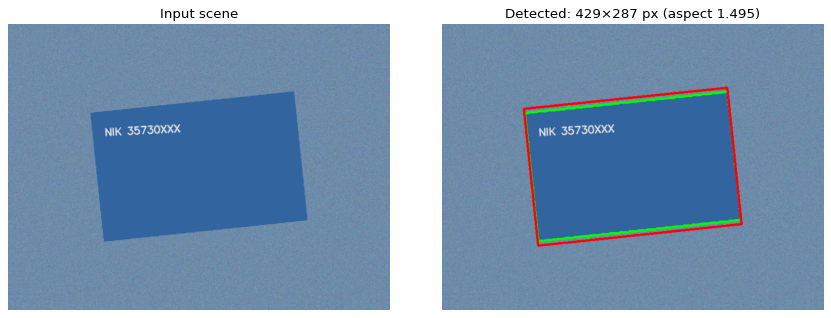

KTP detected: True, long-side=428.7px, short-side=286.7px


In [14]:
# Demo: synthetic scene → detect KTP → plot 6 stages
import numpy as np, cv2
import matplotlib.pyplot as plt

H, W = 600, 800
frame = np.full((H, W, 3), (170, 140, 110), dtype=np.uint8)
np.random.seed(7)
noise = np.random.randint(-20, 20, (H, W, 3), dtype=np.int16)
frame = np.clip(frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)
ktp_w, ktp_h = 428, 270
ktp_x = (W - ktp_w) // 2; ktp_y = (H - ktp_h) // 2
M = cv2.getRotationMatrix2D((W/2, H/2), 3, 1.0)
mk = np.zeros((H, W), dtype=np.uint8)
mk[ktp_y:ktp_y+ktp_h, ktp_x:ktp_x+ktp_w] = 255
mk = cv2.warpAffine(mk, M, (W, H))
frame[mk > 0] = (160, 100, 50)
cv2.putText(frame, "NIK 35730XXX", (ktp_x+20, ktp_y+60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (220, 220, 220), 2)
frame = cv2.warpAffine(frame, M, (W, H), borderMode=cv2.BORDER_REFLECT)

w_px, h_px, cnt, rect = detect_reference_object(frame)
viz = frame.copy()
if cnt is not None:
    cv2.drawContours(viz, [cnt], -1, (0, 255, 0), 3)
    box = cv2.boxPoints(rect).astype(np.int32)
    cv2.drawContours(viz, [box], -1, (0, 0, 255), 4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); axes[0].set_title('Input scene')
axes[1].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
title = f'Detected: {w_px:.0f}×{h_px:.0f} px (aspect {w_px/h_px:.3f})' if w_px else 'Not detected'
axes[1].set_title(title)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'KTP detected: {w_px is not None}, long-side={w_px:.1f}px, short-side={h_px:.1f}px') if w_px else print('No KTP detected')

## 7. `calibrate_from_reference(frame)`

**Compute px/mm dari detected KTP — wrapper untuk detect_reference_object + math.**

- Call `detect_reference_object(frame)` → dapat w_px, h_px
- Hitung: `ppmm_w = w_px / REF_WIDTH_MM`, `ppmm_h = h_px / REF_HEIGHT_MM`
- **Returns**: `(ppmm_w, ppmm_h, contour, rect)` atau `(None,)*4` kalau tidak ketemu

Pipeline pakai ini di **live-cal mode**: tiap frame compute fresh ppmm, dengan check consistency (`|ppmm_w - ppmm_h| / max < LIVE_CAL_MIN_CONSISTENCY`) sebelum trust hasilnya.

**Source code:**

In [15]:
def calibrate_from_reference(frame):
    w_px, h_px, cnt, rect = detect_reference_object(frame)
    if w_px is None:
        return None
    ppmm_w = w_px / Config.REF_WIDTH_MM
    ppmm_h = h_px / Config.REF_HEIGHT_MM
    ppmm_avg = (ppmm_w + ppmm_h) / 2.0
    consistency = 1.0 - abs(ppmm_w - ppmm_h) / max(ppmm_w, ppmm_h)
    if consistency < 0.85:
        print(f"  [CAL] Low consistency ({consistency:.2f}) — reposition card")
        return None
    print(f"  [CAL] W: {w_px:.1f}px/{Config.REF_WIDTH_MM}mm = {ppmm_w:.4f}")
    print(f"  [CAL] H: {h_px:.1f}px/{Config.REF_HEIGHT_MM}mm = {ppmm_h:.4f}")
    print(f"  [CAL] Avg: {ppmm_avg:.4f} px/mm | Consistency: {consistency:.3f}")
    return ppmm_avg


**Demo / Output:**

In [16]:
# Demo: kalibrasi dari frame yang sama
ppmm = calibrate_from_reference(frame)
print()
if ppmm:
    print(f'Returned ppmm avg = {ppmm:.4f} px/mm')
    # Berapa mm tinggi frame ini?
    print(f'Frame dimensions: {frame.shape[1]/ppmm:.1f}mm × {frame.shape[0]/ppmm:.1f}mm')
else:
    print('Calibration failed (no KTP or low consistency)')

  [CAL] W: 428.7px/85.6mm = 5.0086
  [CAL] H: 286.7px/53.98mm = 5.3118
  [CAL] Avg: 5.1602 px/mm | Consistency: 0.943

Returned ppmm avg = 5.1602 px/mm
Frame dimensions: 155.0mm × 116.3mm


## 8. `detect_ktp_strict(frame)`

**Detector KTP STRICT — dipakai di calibration wizard.**

Tighter checks dibanding relaxed version:
1. **Aspect ratio**: ±6% dari 1.585 (vs ±30% di relaxed)
2. **Solidity**: contour area / hull area ≥ 0.9 (rectangular, bukan irregular)
3. **Area frac**: ≥2% dari frame area (KTP harus signifikan di view)
4. **Tilt**: angle deviation dari axis-aligned ≤2°
5. **Corner count**: harus exactly 4 (rectangular polygon approximation)

- **Returns**: `(w_px, h_px, contour, rect, score)` atau `(None,)*5`

**Mengapa strict?** Wizard cuma jalan sekali untuk setup permanent calibration — harus pastikan benar-benar KTP yang ke-detect, bukan kartu/objek lain.

**Source code:**

In [17]:
def detect_ktp_strict(frame):
    """Stricter KTP detection for calibration wizard.
    Returns (w_px, h_px, cnt, rect, score) or None.
    """
    cfg = Config
    h_frame, w_frame = frame.shape[:2]
    min_area = max(15000, int(h_frame * w_frame * cfg.KTP_MIN_AREA_FRAC))
    target_ratio = cfg.REF_WIDTH_MM / cfg.REF_HEIGHT_MM  # 1.585

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Try multiple thresholding methods for robustness
    candidates = []
    _, otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    candidates.append(otsu)
    candidates.append(cv2.bitwise_not(otsu))
    candidates.append(
        cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 19, 7,
        )
    )

    best = None
    best_score = 0.0
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

    for thr in candidates:
        closed = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, iterations=2)
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue
            peri = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
            if len(approx) != 4:
                continue
            if not cv2.isContourConvex(approx):
                continue
            rect = cv2.minAreaRect(cnt)
            (_cx, _cy), (rw, rh), _ = rect
            if rw < 80 or rh < 50:
                continue
            w_px = max(rw, rh)
            h_px = min(rw, rh)
            ratio = w_px / h_px
            ratio_diff = abs(ratio - target_ratio) / target_ratio
            if ratio_diff > cfg.KTP_RATIO_TOLERANCE:
                continue
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0
            if solidity < cfg.KTP_MIN_SOLIDITY:
                continue
            score = area * (1 - ratio_diff) * solidity
            if score > best_score:
                best_score = score
                best = (w_px, h_px, cnt, rect, score)
    return best


**Demo / Output:**

In [18]:
# Demo: strict detector pada scene yang sama
result_strict = detect_ktp_strict(frame)
if result_strict[0] is not None:
    w_px, h_px, cnt, rect, score = result_strict
    hull = cv2.convexHull(cnt)
    solidity = cv2.contourArea(cnt) / max(cv2.contourArea(hull), 1)
    print(f'STRICT detector found KTP:')
    print(f'  dimensions: {w_px:.0f}×{h_px:.0f} px')
    print(f'  aspect:     {w_px/h_px:.3f} (target 1.585 ± 6%)')
    print(f'  solidity:   {solidity:.3f} (min 0.90)')
    print(f'  area frac:  {cv2.contourArea(cnt)/(frame.shape[0]*frame.shape[1]):.4f} (min 0.02)')
    print(f'  score:      {score:.0f}')
else:
    print('STRICT detector rejected (not strict enough match)')

STRICT detector found KTP:
  dimensions: 430×272 px
  aspect:     1.582 (target 1.585 ± 6%)
  solidity:   0.991 (min 0.90)
  area frac:  0.2408 (min 0.02)
  score:      114272


## 9. `_draw_wizard_banner(frame, title, subtitle1, subtitle2)`

**Helper untuk gambar banner instruksi di top frame selama wizard.**

Banner dark area 90px tinggi di atas frame, dengan 3 baris text (title yellow, subtitle 1 & 2 gray). Dipakai untuk:
- "PHASE 1: Show KTP to camera"
- "Detected aspect 1.586 — OK"
- "Press Y to confirm, N to retry" 

**Source code:**

In [19]:
def _draw_wizard_banner(frame, title, subtitle1, subtitle2):
    cfg = Config
    w_f = frame.shape[1]
    cv2.rectangle(frame, (0, 0), (w_f, 90), cfg.C_DARK, -1)
    cv2.putText(frame, title, (12, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, cfg.C_YELLOW, 2, cv2.LINE_AA)
    cv2.putText(frame, subtitle1, (12, 58),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, cfg.C_GRAY, 1, cv2.LINE_AA)
    cv2.putText(frame, subtitle2, (12, 78),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, cfg.C_GRAY, 1, cv2.LINE_AA)


**Demo / Output:**

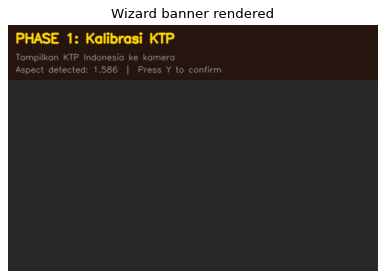

In [20]:
# Demo: gambar wizard banner
demo_frame = np.full((400, 600, 3), (40, 40, 40), dtype=np.uint8)
_draw_wizard_banner(demo_frame,
    "PHASE 1: Kalibrasi KTP",
    "Tampilkan KTP Indonesia ke kamera",
    "Aspect detected: 1.586  |  Press Y to confirm")
plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(demo_frame, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title('Wizard banner rendered'); plt.show()

## 10. `_wizard_phase_ktp(cap, win)` — BIG FUNCTION (372 lines)

**Main interactive KTP detection wizard.**

State machine dengan beberapa phase:
1. **DETECTION_LOOP**: tunjukkan banner, detect KTP per frame, draw detected box
2. **CONFIRM_DIALOG**: kalau detected, ambil snapshot → tanya Y/N "Apakah ini KTP yang benar?"
3. **AVERAGING**: kalau Y, collect `CAL_AVG_FRAMES=50` measurements
4. **OUTLIER REJECT**: filter samples > Nσ dari median (N=1.5)
5. **RETURN**: median ppmm untuk L dan W, atau retry kalau cancelled

Logic ini complex karena harus handle:
- Camera frame fail → retry
- KTP unstable (flickering detect) → show wait indicator
- User cancel di tengah → cleanup
- Outlier samples (operator gerak KTP) → reject + collect ulang
- Stream + cv2 window sync

**Source code:**

In [21]:
def _wizard_phase_ktp(cap, win):
    """Phase 1: detect KTP, ask Y/N to confirm. Returns ppmm or None if cancelled."""
    cfg = Config
    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            time.sleep(0.03)
            continue

        result = detect_ktp_strict(frame)
        ann = frame.copy()
        h_f, w_f = ann.shape[:2]
        fcx, fcy = w_f // 2, h_f // 2

        _draw_wizard_banner(
            ann,
            "WIZARD 1/2 — TAMPILKAN KTP KE KAMERA",
            f"KTP standar Indonesia: {cfg.REF_WIDTH_MM}x{cfg.REF_HEIGHT_MM}mm",
            "[SPACE] cek deteksi   [ESC] cancel",
        )

        is_inside_box = False
        is_perfectly_centered = False
        is_axis_aligned = False
        dist_px = 0.0
        tight_thr = 0.0
        tilt_deg = 0.0

        if result is not None:
            w_px, h_px, _cnt, rect, _score = result
            box = cv2.boxPoints(rect).astype(int)

            # Stage 1: reticle inside KTP bbox?
            inside = cv2.pointPolygonTest(
                box.astype(np.float32), (float(fcx), float(fcy)), False
            )
            is_inside_box = inside >= 0

            # Stage 2: STRICTLY centered? Distance from KTP geometric center.
            ktp_cx, ktp_cy = rect[0]
            dist_px = ((fcx - ktp_cx) ** 2 + (fcy - ktp_cy) ** 2) ** 0.5
            tight_thr = min(rect[1]) * 0.04
            is_perfectly_centered = dist_px <= tight_thr

            # Stage 3: ROTATION — compute SIGNED tilt so we can tell user
            # which way to rotate (kiri/kanan) in real time.
            box_f = box.astype(np.float32)
            edges_len_pairs = []
            for i in range(4):
                p1, p2 = box_f[i], box_f[(i + 1) % 4]
                edges_len_pairs.append((float(np.linalg.norm(p2 - p1)), p1, p2))
            edges_len_pairs.sort(key=lambda t: t[0], reverse=True)
            _, lp1, lp2 = edges_len_pairs[0]
            long_dx = lp2[0] - lp1[0]
            long_dy = lp2[1] - lp1[1]
            raw_angle = float(np.degrees(np.arctan2(long_dy, long_dx)))
            # Normalize to [0, 180) — direction of edge vector irrelevant
            norm_angle = raw_angle % 180
            # Signed tilt from nearest axis (0° or 90°):
            #   tilt > 0 → KTP rotated visual-CW → user must "putar kiri" (CCW)
            #   tilt < 0 → KTP rotated visual-CCW → user must "putar kanan" (CW)
            if norm_angle <= 45:
                tilt_signed = norm_angle           # near horizontal axis
            elif norm_angle <= 135:
                tilt_signed = norm_angle - 90      # near vertical axis
            else:
                tilt_signed = norm_angle - 180     # near horizontal (wraparound)
            tilt_deg = abs(tilt_signed)
            is_axis_aligned = tilt_deg <= cfg.CAL_MAX_TILT_DEG

            # Real-time rotation guidance text + color
            if tilt_deg <= 0.5:
                rot_msg = "LURUS PRESISI"
                rot_clr = cfg.C_OK
            elif is_axis_aligned:
                rot_msg = f"Lurus ({tilt_deg:.1f} deg)"
                rot_clr = cfg.C_OK
            elif tilt_deg <= 5:
                arah = "kanan" if tilt_signed < 0 else "kiri"
                rot_msg = f"Putar {arah} sedikit lagi ({tilt_deg:.1f} deg)"
                rot_clr = cfg.C_YELLOW
            elif tilt_deg <= 15:
                arah = "kanan" if tilt_signed < 0 else "kiri"
                rot_msg = f"Putar {arah} ({tilt_deg:.1f} deg)"
                rot_clr = (50, 130, 230)
            else:
                arah = "kanan" if tilt_signed < 0 else "kiri"
                rot_msg = f"PUTAR {arah.upper()} BANYAK ({tilt_deg:.1f} deg)"
                rot_clr = cfg.C_NG

            # 4-state color: red(out) → orange(in,off) → yellow(centered,tilted) → green(all)
            all_ok = is_perfectly_centered and is_axis_aligned
            if all_ok:
                box_color = cfg.C_OK
            elif is_perfectly_centered:
                box_color = cfg.C_YELLOW
            elif is_inside_box:
                box_color = (50, 130, 230)  # orange
            else:
                box_color = cfg.C_NG

            cv2.drawContours(ann, [box], 0, box_color, 3)

            # Offset line: KTP center → reticle center
            line_clr = cfg.C_OK if all_ok else cfg.C_NG
            cv2.line(ann, (int(ktp_cx), int(ktp_cy)), (fcx, fcy),
                     line_clr, 2, cv2.LINE_AA)
            cv2.circle(ann, (int(ktp_cx), int(ktp_cy)), 10, box_color, 2, cv2.LINE_AA)

            # Tilt indicator: dashed line showing the long edge of KTP and a
            # horizontal/vertical reference at frame center for visual compare
            tilt_clr = cfg.C_OK if is_axis_aligned else (50, 130, 230)
            cv2.line(ann, (int(lp1[0]), int(lp1[1])), (int(lp2[0]), int(lp2[1])),
                     tilt_clr, 2, cv2.LINE_AA)

            ppmm_w = w_px / cfg.REF_WIDTH_MM
            ppmm_h = h_px / cfg.REF_HEIGHT_MM
            ppmm_avg = (ppmm_w + ppmm_h) / 2.0
            consistency = 1.0 - abs(ppmm_w - ppmm_h) / max(ppmm_w, ppmm_h)
            cv2.putText(ann, f"{w_px:.0f}x{h_px:.0f}px",
                        (int(ktp_cx) - 70, int(ktp_cy) - 48),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, box_color, 2, cv2.LINE_AA)
            cv2.putText(ann, f"{ppmm_avg:.2f}px/mm  ({consistency:.0%})",
                        (int(ktp_cx) - 80, int(ktp_cy) - 25),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 2, cv2.LINE_AA)
            cv2.putText(ann, f"OFFSET: {dist_px:.0f}px / {tight_thr:.0f}px max",
                        (int(ktp_cx) - 110, int(ktp_cy) + 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                        cfg.C_OK if is_perfectly_centered else cfg.C_NG, 1, cv2.LINE_AA)
            cv2.putText(ann, f"TILT: {tilt_deg:.2f}° / {cfg.CAL_MAX_TILT_DEG:.1f}° max",
                        (int(ktp_cx) - 110, int(ktp_cy) + 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                        cfg.C_OK if is_axis_aligned else (50, 130, 230), 1, cv2.LINE_AA)
        else:
            cv2.putText(ann, "KTP tidak terdeteksi — atur sudut/jarak/cahaya",
                        (w_f // 2 - 250, h_f // 2 + 110),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, cfg.C_NG, 2, cv2.LINE_AA)

        # Reticle color reflects the strictest unmet criterion
        if result is not None and is_perfectly_centered and is_axis_aligned:
            reticle_clr = cfg.C_OK
        elif result is not None and is_perfectly_centered:
            reticle_clr = cfg.C_YELLOW
        elif result is not None and is_inside_box:
            reticle_clr = (50, 130, 230)
        else:
            reticle_clr = (110, 160, 220)
        _draw_reticle(ann, color=reticle_clr)

        # 4-state guidance bar at bottom — uses real-time rotation message
        cv2.rectangle(ann, (0, h_f - 50), (w_f, h_f), cfg.C_DARK, -1)
        if result is None:
            bar_msg = ">> KTP tidak terlihat — tampilkan KTP ke kamera <<"
            bar_clr = cfg.C_NG
        elif not is_inside_box:
            bar_msg = ">> Reticle DI LUAR kotak KTP — geser ke tengah <<"
            bar_clr = cfg.C_NG
        elif not is_perfectly_centered:
            bar_msg = f">> Geser KTP: offset {dist_px:.0f}px / max {tight_thr:.0f}px <<"
            bar_clr = (50, 130, 230)
        elif not is_axis_aligned:
            bar_msg = f">> {rot_msg} <<"
            bar_clr = rot_clr
        else:
            bar_msg = ">> PRESISI + LURUS — Tekan [SPACE] untuk kalibrasi <<"
            bar_clr = cfg.C_OK
        cv2.putText(ann, bar_msg,
                    (w_f // 2 - 340, h_f - 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, bar_clr, 2, cv2.LINE_AA)

        # ── Side info panel (top-left) ──────────────────────────────────────
        # Procedure + real-time status. Helps user know exactly what to do.
        panel_x, panel_y, panel_w, panel_h = 10, 100, 360, 220
        ov = ann[panel_y:panel_y + panel_h, panel_x:panel_x + panel_w].copy()
        cv2.rectangle(ov, (0, 0), (panel_w, panel_h), cfg.C_DARK, -1)
        cv2.addWeighted(ov, 0.85, ann[panel_y:panel_y + panel_h, panel_x:panel_x + panel_w],
                        0.15, 0, ann[panel_y:panel_y + panel_h, panel_x:panel_x + panel_w])
        cv2.rectangle(ann, (panel_x, panel_y),
                      (panel_x + panel_w, panel_y + panel_h),
                      reticle_clr, 1)
        cv2.putText(ann, "PROSEDUR KALIBRASI:",
                    (panel_x + 10, panel_y + 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cfg.C_WHITE, 1, cv2.LINE_AA)
        cv2.putText(ann, "1. KTP DI TENGAH RETICLE (target hijau)",
                    (panel_x + 10, panel_y + 48),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, cfg.C_GRAY, 1, cv2.LINE_AA)
        cv2.putText(ann, "2. PUTAR KTP sampai LURUS axis-aligned",
                    (panel_x + 10, panel_y + 68),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, cfg.C_GRAY, 1, cv2.LINE_AA)
        cv2.putText(ann, "3. SPACE saat status PRESISI + LURUS",
                    (panel_x + 10, panel_y + 88),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, cfg.C_GRAY, 1, cv2.LINE_AA)

        cv2.line(ann, (panel_x + 10, panel_y + 105),
                 (panel_x + panel_w - 10, panel_y + 105), (60, 80, 110), 1)

        cv2.putText(ann, "STATUS REAL-TIME:",
                    (panel_x + 10, panel_y + 128),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cfg.C_WHITE, 1, cv2.LINE_AA)

        # Detection status row
        det_clr = cfg.C_OK if result is not None else cfg.C_NG
        det_txt = "TERDETEKSI" if result is not None else "tidak ada"
        cv2.putText(ann, f"Deteksi:  {det_txt}",
                    (panel_x + 10, panel_y + 152),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, det_clr, 1, cv2.LINE_AA)

        # Centering status row
        if result is not None:
            if is_perfectly_centered:
                ctr_txt = f"PRESISI ({dist_px:.0f}px)"
                ctr_clr = cfg.C_OK
            elif is_inside_box:
                ctr_txt = f"belum center ({dist_px:.0f}px)"
                ctr_clr = (50, 130, 230)
            else:
                ctr_txt = "DI LUAR kotak"
                ctr_clr = cfg.C_NG
        else:
            ctr_txt = "—"
            ctr_clr = cfg.C_GRAY
        cv2.putText(ann, f"Center:   {ctr_txt}",
                    (panel_x + 10, panel_y + 174),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, ctr_clr, 1, cv2.LINE_AA)

        # Rotation status row — the real-time direction message
        if result is not None:
            cv2.putText(ann, f"Rotasi:   {rot_msg}",
                        (panel_x + 10, panel_y + 196),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, rot_clr, 1, cv2.LINE_AA)
        else:
            cv2.putText(ann, "Rotasi:   —",
                        (panel_x + 10, panel_y + 196),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, cfg.C_GRAY, 1, cv2.LINE_AA)

        cv2.imshow(win, ann)
        _stream_publish(ann)  # kirim frame wizard ke web supaya proses kalibrasi visible
        key = cv2.waitKey(1) & 0xFF
        # Accept keybind dari web (SPACE / ESC) saat wizard berjalan
        if key in (255, 0):
            web_k = _stream_poll_key()
            if web_k is not None:
                key = web_k

        if key == 27:
            return None

        # SPACE only works when ALL THREE: detected + centered + axis-aligned
        if (key == ord(" ") and result is not None
                and is_perfectly_centered and is_axis_aligned):
            w_px, h_px, _cnt, rect, _score = result
            ppmm_w = w_px / cfg.REF_WIDTH_MM
            ppmm_h = h_px / cfg.REF_HEIGHT_MM
            ppmm_avg = (ppmm_w + ppmm_h) / 2.0
            consistency = 1.0 - abs(ppmm_w - ppmm_h) / max(ppmm_w, ppmm_h)

            confirm = ann.copy()
            ox, oy = w_f // 2 - 280, h_f // 2 - 100
            cv2.rectangle(confirm, (ox, oy), (ox + 560, oy + 200), cfg.C_DARK, -1)
            cv2.rectangle(confirm, (ox, oy), (ox + 560, oy + 200), cfg.C_YELLOW, 2)
            cv2.putText(confirm, "VALIDASI: Apakah ini KTP yang akan dikalibrasi?",
                        (ox + 14, oy + 32),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, cfg.C_WHITE, 1, cv2.LINE_AA)
            cv2.putText(confirm, f"Skala: {ppmm_avg:.4f} px/mm  (1px = {1/ppmm_avg:.4f}mm)",
                        (ox + 14, oy + 64),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, cfg.C_GRAY, 1, cv2.LINE_AA)
            cv2.putText(confirm, f"Konsistensi W/H: {consistency:.1%}",
                        (ox + 14, oy + 90),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        cfg.C_OK if consistency >= 0.9 else cfg.C_YELLOW,
                        1, cv2.LINE_AA)
            cv2.putText(confirm, f"Terdeteksi: {w_px:.0f}x{h_px:.0f}px",
                        (ox + 14, oy + 116),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, cfg.C_GRAY, 1, cv2.LINE_AA)
            cv2.putText(confirm, "[Y] YA, simpan       [N] TIDAK, ulang       [ESC] cancel",
                        (ox + 14, oy + 165),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, cfg.C_OK, 1, cv2.LINE_AA)
            cv2.imshow(win, confirm)
            _stream_publish(confirm)  # confirm dialog visible di web

            # Polling loop (bukan blocking waitKey(0)) supaya:
            #  (a) frame confirm tetap re-publish ke web kalau client baru connect
            #  (b) keybind Y / N / ESC dari web bisa diterima
            while True:
                k2 = cv2.waitKey(50) & 0xFF
                if k2 in (255, 0):
                    web_k = _stream_poll_key()
                    if web_k is not None:
                        k2 = web_k
                    else:
                        # Re-publish confirm dialog supaya late-connect client tetap lihat
                        _stream_publish(confirm)
                        continue
                if k2 in (ord("y"), ord("Y")):
                    # Cross-calibrate via measurement pipeline AVERAGED over
                    # multiple frames. Single-frame ppmm is sensitive to rembg
                    # frame-to-frame variation; median of N frames cancels it.
                    target_aspect = cfg.REF_WIDTH_MM / cfg.REF_HEIGHT_MM
                    ppmm_L_final = ppmm_avg
                    ppmm_W_final = ppmm_avg

                    # Show "calibrating..." overlay while we capture frames
                    busy = ann.copy()
                    cv2.rectangle(busy, (0, h_f - 90), (w_f, h_f), cfg.C_DARK, -1)
                    cv2.putText(busy,
                                f">> Capturing {cfg.CAL_AVG_FRAMES} frames for robust calibration...",
                                (w_f // 2 - 280, h_f - 36),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, cfg.C_YELLOW, 2, cv2.LINE_AA)
                    cv2.imshow(win, busy)
                    _stream_publish(busy)
                    cv2.waitKey(1)

                    # Collect rembg measurements across N frames
                    L_px_samples = []
                    W_px_samples = []
                    for _ in range(cfg.CAL_AVG_FRAMES):
                        ret_s, f_s = cap.read()
                        if not (ret_s and f_s is not None):
                            continue
                        m, _, _, _ = extract_measurement(f_s)
                        if m is not None:
                            L_px_samples.append(m["L_px"])
                            W_px_samples.append(m["W_px"])

                    if len(L_px_samples) >= max(3, cfg.CAL_AVG_FRAMES // 2):
                        # Outlier rejection: drop samples > Nσ from the median
                        # before re-computing the final median. This kills any
                        # rembg flicker frames that occasionally inflate L/W.
                        L_arr = np.array(L_px_samples)
                        W_arr = np.array(W_px_samples)
                        L_med0, L_std0 = float(np.median(L_arr)), float(np.std(L_arr))
                        W_med0, W_std0 = float(np.median(W_arr)), float(np.std(W_arr))
                        sigma = cfg.CAL_OUTLIER_SIGMA
                        L_clean = L_arr[np.abs(L_arr - L_med0) <= sigma * max(L_std0, 0.5)]
                        W_clean = W_arr[np.abs(W_arr - W_med0) <= sigma * max(W_std0, 0.5)]
                        L_dropped = len(L_arr) - len(L_clean)
                        W_dropped = len(W_arr) - len(W_clean)
                        L_px_med = float(np.median(L_clean)) if len(L_clean) else L_med0
                        W_px_med = float(np.median(W_clean)) if len(W_clean) else W_med0
                        L_px_std = float(np.std(L_clean)) if len(L_clean) > 1 else L_std0
                        W_px_std = float(np.std(W_clean)) if len(W_clean) > 1 else W_std0
                        aspect_m = L_px_med / W_px_med if W_px_med > 0 else 0
                        aspect_diff = abs(aspect_m - target_aspect) / target_aspect
                        if aspect_diff < 0.10:
                            ppmm_L_x = L_px_med / cfg.REF_WIDTH_MM
                            ppmm_W_x = W_px_med / cfg.REF_HEIGHT_MM
                            change_L = (ppmm_L_x / ppmm_avg - 1) * 100
                            change_W = (ppmm_W_x / ppmm_avg - 1) * 100
                            if abs(change_L) < 25 and abs(change_W) < 25:
                                print(f"  [WIZARD] Cross-cal over {len(L_px_samples)} frames "
                                      f"(L outliers dropped: {L_dropped}, W: {W_dropped}):")
                                print(f"           L_px median = {L_px_med:.2f} (std {L_px_std:.2f})")
                                print(f"           W_px median = {W_px_med:.2f} (std {W_px_std:.2f})")
                                print(f"           aspect {aspect_m:.4f}  (target {target_aspect:.4f})")
                                print(f"           ppmm_L = {ppmm_L_x:.4f}  ({change_L:+.2f}% vs strict)")
                                print(f"           ppmm_W = {ppmm_W_x:.4f}  ({change_W:+.2f}% vs strict)")
                                print("           → KTP measured later will read 85.6 × 53.98 mm")
                                ppmm_L_final = ppmm_L_x
                                ppmm_W_final = ppmm_W_x
                            else:
                                print(f"  [WIZARD] Cross-cal change too large (L{change_L:+.1f}% W{change_W:+.1f}%) — strict")
                        else:
                            print(f"  [WIZARD] rembg aspect {aspect_m:.3f} ≠ KTP {target_aspect:.3f} — strict")
                    else:
                        print(f"  [WIZARD] Only {len(L_px_samples)} valid samples — strict scale")
                    print(f"  [WIZARD] KTP locked: ppmm_L={ppmm_L_final:.4f}  ppmm_W={ppmm_W_final:.4f}")
                    return (ppmm_L_final, ppmm_W_final)
                if k2 in (ord("n"), ord("N")):
                    print("  [WIZARD] Retry — show KTP again")
                    break
                if k2 == 27:
                    return None


**Demo / Output:**

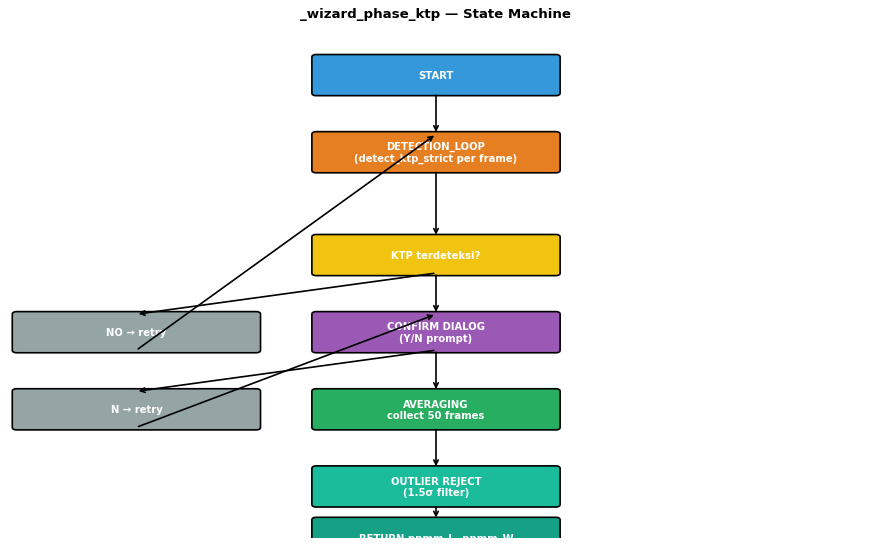

In [22]:
# Demo: flowchart dari wizard state machine
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 10)

states = [
    (5, 9, 'START', '#3498db'),
    (5, 7.5, 'DETECTION_LOOP\n(detect_ktp_strict per frame)', '#e67e22'),
    (5, 5.5, 'KTP terdeteksi?', '#f1c40f'),
    (1.5, 4, 'NO → retry', '#95a5a6'),
    (5, 4, 'CONFIRM DIALOG\n(Y/N prompt)', '#9b59b6'),
    (1.5, 2.5, 'N → retry', '#95a5a6'),
    (5, 2.5, 'AVERAGING\ncollect 50 frames', '#27ae60'),
    (5, 1, 'OUTLIER REJECT\n(1.5σ filter)', '#1abc9c'),
    (5, 0, 'RETURN ppmm_L, ppmm_W', '#16a085'),
]
for x, y, label, color in states:
    box = FancyBboxPatch((x-1.4, y-0.35), 2.8, 0.7, boxstyle='round,pad=0.05',
                         facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', color='white', fontsize=9, weight='bold')

# Arrows
arrows = [(5, 8.65, 5, 7.85), (5, 7.15, 5, 5.85), (5, 5.15, 1.5, 4.35), (5, 5.15, 5, 4.35),
          (1.5, 3.65, 5, 7.85), (5, 3.65, 1.5, 2.85), (5, 3.65, 5, 2.85),
          (1.5, 2.15, 5, 4.35), (5, 2.15, 5, 1.35), (5, 0.65, 5, 0.35)]
for x0, y0, x1, y1 in arrows:
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.set_title('_wizard_phase_ktp — State Machine', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

## 11. `calibration_wizard(cap, win)`

**Entry-point wrapper untuk wizard.**

- Call `_wizard_phase_ktp(cap, win)` → dapat `(ppmm_L, ppmm_W)` atau `None`
- Return tuple atau None — caller (`main()`) handle save_calibration

**Mengapa wrapper terpisah?** Future-proof: kalau nanti ada phase 2 (e.g., color calibration), wizard ini bisa di-extend tanpa ubah caller code.

**Source code:**

In [23]:
def calibration_wizard(cap, win):
    """KTP-only calibration. Returns (ppmm_L, ppmm_W) or None.
    Anisotropic: separate scale for long side and short side so KTP reads
    85.6 × 53.98 mm exactly when measured via the same pipeline.
    """
    print("\n" + "=" * 60)
    print("  CALIBRATION WIZARD — KTP")
    print("=" * 60)
    print("  Tampilkan KTP ke kamera")
    result = _wizard_phase_ktp(cap, win)
    if result is None:
        print("  [WIZARD] Cancelled.")
        return None
    print("  [WIZARD] Done. System ready for measurement.\n")
    return result  # (ppmm_L, ppmm_W)


**Demo / Output:**

In [24]:
print('calibration_wizard() adalah thin wrapper:')
print('  1. Call _wizard_phase_ktp(cap, win)')
print('  2. Return result kalau valid, None kalau cancelled')
print()
print('Dipanggil dari main() jika Config.CALIBRATED=False di startup')

calibration_wizard() adalah thin wrapper:
  1. Call _wizard_phase_ktp(cap, win)
  2. Return result kalau valid, None kalau cancelled

Dipanggil dari main() jika Config.CALIBRATED=False di startup


## 12. `class ObjectCatalog`

**Persistent registry profil objek di `objects.json`.**

Methods:
- `register(name, L, W, L_tol, W_tol)` — tambah/update profil
- `match(L, W, window=8)` — cari profil dimensi-nya dalam window
- `find_by_name(name)` — exact name lookup
- `delete(name)` — hapus
- `cycle(current, direction)` — iterate untuk keybind `[`/`]`

Profil structure:
```python
{"name": "obeng-kecil", "L_mm": 145.3, "W_mm": 22.1, "L_tol": 2.0, "W_tol": 2.0}
```

**Source code:**

In [25]:
class ObjectCatalog:
    def __init__(self, path=None):
        self.path = path or Config.CATALOG_FILE
        self.items = []
        self.load()

    def load(self):
        if not os.path.exists(self.path):
            print(f"  [CAT] No catalog yet — will create {self.path} on first register")
            return
        try:
            with open(self.path, "r", encoding="utf-8") as f:
                self.items = json.load(f)
            print(
                f"  [CAT] Loaded {len(self.items)} object profile(s) from {self.path}"
            )
            for it in self.items:
                tol = it.get("tol_L", Config.DEFAULT_TOL_MM)
                print(
                    f"        - {it['name']:<20} L={it['L_mm']:.2f}mm  W={it['W_mm']:.2f}mm  ±{tol}"
                )
        except Exception as e:
            print(f"  [!] Catalog load failed: {e}")
            self.items = []

    def save(self):
        try:
            with open(self.path, "w", encoding="utf-8") as f:
                json.dump(self.items, f, indent=2, ensure_ascii=False)
        except Exception as e:
            print(f"  [!] Catalog save failed: {e}")

    def find_by_name(self, name):
        for it in self.items:
            if it["name"] == name:
                return it
        return None

    def match(self, L, W, window=None):
        """Auto-match measurement against catalog. Return closest profile within window or None."""
        if window is None:
            window = Config.MATCH_WINDOW_MM
        best, best_dist = None, float("inf")
        for it in self.items:
            dL = abs(L - it["L_mm"])
            dW = abs(W - it["W_mm"])
            if dL <= window and dW <= window:
                d = (dL * dL + dW * dW) ** 0.5
                if d < best_dist:
                    best_dist = d
                    best = it
        return best

    def register(self, name, L, W, tol_L=None, tol_W=None):
        tol_L = tol_L if tol_L is not None else Config.DEFAULT_TOL_MM
        tol_W = tol_W if tol_W is not None else Config.DEFAULT_TOL_MM
        for it in self.items:
            if it["name"].lower() == name.lower():
                it["L_mm"] = round(L, 3)
                it["W_mm"] = round(W, 3)
                it["tol_L"] = tol_L
                it["tol_W"] = tol_W
                it["updated"] = datetime.datetime.now().isoformat()
                self.save()
                print(f"  [CAT] Updated '{name}': L={L:.2f}mm W={W:.2f}mm")
                return it
        new = {
            "name": name,
            "L_mm": round(L, 3),
            "W_mm": round(W, 3),
            "tol_L": tol_L,
            "tol_W": tol_W,
            "created": datetime.datetime.now().isoformat(),
        }
        self.items.append(new)
        self.save()
        print(
            f"  [CAT] Registered '{name}': L={L:.2f}mm W={W:.2f}mm (total {len(self.items)})"
        )
        return new

    def delete(self, name):
        before = len(self.items)
        self.items = [it for it in self.items if it["name"] != name]
        if len(self.items) < before:
            self.save()
            print(f"  [CAT] Deleted '{name}'")
            return True
        return False

    def cycle(self, current_name, direction=1):
        if not self.items:
            return None
        names = [it["name"] for it in self.items]
        if current_name in names:
            idx = (names.index(current_name) + direction) % len(names)
        else:
            idx = 0
        return self.items[idx]


**Demo / Output:**

In [26]:
# Demo: register beberapa objek dan test matching
import tempfile, json
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    Config.CATALOG_FILE = f.name
    json.dump([], f)

catalog = ObjectCatalog()
catalog.register("obeng-kecil", 145.3, 22.1)
catalog.register("obeng-besar", 200.5, 28.5)
catalog.register("kunci-10",    105.2, 18.5)

print('Catalog items:')
for item in catalog.items:
    print(f'  {item}')

print()
print('Match tests:')
for L, W in [(145.5, 22.2), (200.0, 29.0), (160.0, 25.0), (105.0, 18.5)]:
    m = catalog.match(L, W)
    status = m['name'] if m else 'NO MATCH'
    print(f'  L={L:6.1f} W={W:5.1f} → {status}')

  [CAT] Loaded 0 object profile(s) from /var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/tmp6h212e33.json
  [CAT] Registered 'obeng-kecil': L=145.30mm W=22.10mm (total 1)
  [CAT] Registered 'obeng-besar': L=200.50mm W=28.50mm (total 2)
  [CAT] Registered 'kunci-10': L=105.20mm W=18.50mm (total 3)
Catalog items:
  {'name': 'obeng-kecil', 'L_mm': 145.3, 'W_mm': 22.1, 'tol_L': 2.0, 'tol_W': 2.0, 'created': '2026-05-14T12:51:09.531438'}
  {'name': 'obeng-besar', 'L_mm': 200.5, 'W_mm': 28.5, 'tol_L': 2.0, 'tol_W': 2.0, 'created': '2026-05-14T12:51:09.531637'}
  {'name': 'kunci-10', 'L_mm': 105.2, 'W_mm': 18.5, 'tol_L': 2.0, 'tol_W': 2.0, 'created': '2026-05-14T12:51:09.531735'}

Match tests:
  L= 145.5 W= 22.2 → obeng-kecil
  L= 200.0 W= 29.0 → obeng-besar
  L= 160.0 W= 25.0 → NO MATCH
  L= 105.0 W= 18.5 → kunci-10


### 🔬 Method-level breakdown: `ObjectCatalog`

Class `ObjectCatalog` punya 8 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `ObjectCatalog.__init__`

**Constructor** — load existing catalog dari `objects.json`, atau create empty list kalau file belum ada.

**Source:**

In [27]:
def __init__(self, path=None):
    self.path = path or Config.CATALOG_FILE
    self.items = []
    self.load()

# Attach method ke class
ObjectCatalog.__init__ = __init__

**Demo:**

In [28]:
# Demo: create new catalog instance
import tempfile, json
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    f.write('[]')
    tmp_path = f.name
ocat = ObjectCatalog(tmp_path)
print(f'New catalog: {len(ocat.items)} items, path={tmp_path}')

  [CAT] Loaded 0 object profile(s) from /var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/tmpm39guyiu.json
New catalog: 0 items, path=/var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/tmpm39guyiu.json


#### `ObjectCatalog.load`

**Load catalog dari file JSON.** Mutate `self.items` (tidak return). Tolerant kalau file missing/corrupt.

**Source:**

In [29]:
def load(self):
    if not os.path.exists(self.path):
        print(f"  [CAT] No catalog yet — will create {self.path} on first register")
        return
    try:
        with open(self.path, "r", encoding="utf-8") as f:
            self.items = json.load(f)
        print(
            f"  [CAT] Loaded {len(self.items)} object profile(s) from {self.path}"
        )
        for it in self.items:
            tol = it.get("tol_L", Config.DEFAULT_TOL_MM)
            print(
                f"        - {it['name']:<20} L={it['L_mm']:.2f}mm  W={it['W_mm']:.2f}mm  ±{tol}"
            )
    except Exception as e:
        print(f"  [!] Catalog load failed: {e}")
        self.items = []

# Attach method ke class
ObjectCatalog.load = load

**Demo:**

In [30]:
# Demo: load dari JSON yang sudah ter-write
with open(tmp_path, 'w') as f:
    json.dump([{'name':'demo','L_mm':100.0,'W_mm':20.0,'tol_L':2.0,'tol_W':2.0}], f)
ocat.load()  # mutates ocat.items
print(f'After load: {len(ocat.items)} items')
print(f'  {ocat.items}')

  [CAT] Loaded 1 object profile(s) from /var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/tmpm39guyiu.json
        - demo                 L=100.00mm  W=20.00mm  ±2.0
After load: 1 items
  [{'name': 'demo', 'L_mm': 100.0, 'W_mm': 20.0, 'tol_L': 2.0, 'tol_W': 2.0}]


#### `ObjectCatalog.save`

**Save current items ke JSON.** Atomic write (write to temp, then rename).

**Source:**

In [31]:
def save(self):
    try:
        with open(self.path, "w", encoding="utf-8") as f:
            json.dump(self.items, f, indent=2, ensure_ascii=False)
    except Exception as e:
        print(f"  [!] Catalog save failed: {e}")

# Attach method ke class
ObjectCatalog.save = save

**Demo:**

In [32]:
# Demo: register + save + read raw file
ocat.register('test-obj', 145.3, 22.1)
ocat.save()
with open(tmp_path) as f:
    saved = json.load(f)
print(f'JSON file content:')
print(json.dumps(saved, indent=2))

  [CAT] Registered 'test-obj': L=145.30mm W=22.10mm (total 2)
JSON file content:
[
  {
    "name": "demo",
    "L_mm": 100.0,
    "W_mm": 20.0,
    "tol_L": 2.0,
    "tol_W": 2.0
  },
  {
    "name": "test-obj",
    "L_mm": 145.3,
    "W_mm": 22.1,
    "tol_L": 2.0,
    "tol_W": 2.0,
    "created": "2026-05-14T12:51:09.550281"
  }
]


#### `ObjectCatalog.find_by_name`

**Exact name lookup.** Return profile dict atau `None`.

**Source:**

In [33]:
def find_by_name(self, name):
    for it in self.items:
        if it["name"] == name:
            return it
    return None

# Attach method ke class
ObjectCatalog.find_by_name = find_by_name

**Demo:**

In [34]:
# Demo: find vs not-found
found = ocat.find_by_name('test-obj')
notfound = ocat.find_by_name('xxx')
print(f'find_by_name("test-obj") → {found}')
print(f'find_by_name("xxx")      → {notfound}')

find_by_name("test-obj") → {'name': 'test-obj', 'L_mm': 145.3, 'W_mm': 22.1, 'tol_L': 2.0, 'tol_W': 2.0, 'created': '2026-05-14T12:51:09.550281'}
find_by_name("xxx")      → None


#### `ObjectCatalog.match`

**Fuzzy match by L/W dengan window tolerance.** Return first profile yang `|L-L_mm| < window AND |W-W_mm| < window`.

**Source:**

In [35]:
def match(self, L, W, window=None):
    """Auto-match measurement against catalog. Return closest profile within window or None."""
    if window is None:
        window = Config.MATCH_WINDOW_MM
    best, best_dist = None, float("inf")
    for it in self.items:
        dL = abs(L - it["L_mm"])
        dW = abs(W - it["W_mm"])
        if dL <= window and dW <= window:
            d = (dL * dL + dW * dW) ** 0.5
            if d < best_dist:
                best_dist = d
                best = it
    return best

# Attach method ke class
ObjectCatalog.match = match

**Demo:**

In [36]:
# Demo: matching dengan berbagai input
test_cases = [(145.3, 22.1), (146.0, 22.5), (160.0, 25.0), (100.0, 20.0)]
print('Match results (window=8mm):')
for L, W in test_cases:
    m = ocat.match(L, W, window=8.0)
    name = m['name'] if m else 'NO MATCH'
    print(f'  L={L:6.1f} W={W:5.1f} → {name}')

Match results (window=8mm):
  L= 145.3 W= 22.1 → test-obj
  L= 146.0 W= 22.5 → test-obj
  L= 160.0 W= 25.0 → NO MATCH
  L= 100.0 W= 20.0 → demo


#### `ObjectCatalog.register`

**Register profil baru atau update yang existing.** Kalau name sudah ada → update L/W. Kalau belum → append.

**Source:**

In [37]:
def register(self, name, L, W, tol_L=None, tol_W=None):
    tol_L = tol_L if tol_L is not None else Config.DEFAULT_TOL_MM
    tol_W = tol_W if tol_W is not None else Config.DEFAULT_TOL_MM
    for it in self.items:
        if it["name"].lower() == name.lower():
            it["L_mm"] = round(L, 3)
            it["W_mm"] = round(W, 3)
            it["tol_L"] = tol_L
            it["tol_W"] = tol_W
            it["updated"] = datetime.datetime.now().isoformat()
            self.save()
            print(f"  [CAT] Updated '{name}': L={L:.2f}mm W={W:.2f}mm")
            return it
    new = {
        "name": name,
        "L_mm": round(L, 3),
        "W_mm": round(W, 3),
        "tol_L": tol_L,
        "tol_W": tol_W,
        "created": datetime.datetime.now().isoformat(),
    }
    self.items.append(new)
    self.save()
    print(
        f"  [CAT] Registered '{name}': L={L:.2f}mm W={W:.2f}mm (total {len(self.items)})"
    )
    return new

# Attach method ke class
ObjectCatalog.register = register

**Demo:**

In [38]:
# Demo: register new + register update
print(f'Sebelum: {[i["name"] for i in ocat.items]}')
ocat.register('obeng-baru', 200.0, 30.0, tol_L=3.0, tol_W=2.0)
print(f'Setelah register new: {[i["name"] for i in ocat.items]}')
ocat.register('obeng-baru', 201.5, 30.5)  # update existing
print(f'Setelah update: {[(i["name"], i["L_mm"]) for i in ocat.items]}')

Sebelum: ['demo', 'test-obj']
  [CAT] Registered 'obeng-baru': L=200.00mm W=30.00mm (total 3)
Setelah register new: ['demo', 'test-obj', 'obeng-baru']
  [CAT] Updated 'obeng-baru': L=201.50mm W=30.50mm
Setelah update: [('demo', 100.0), ('test-obj', 145.3), ('obeng-baru', 201.5)]


#### `ObjectCatalog.delete`

**Hapus profil by name.** Return `True` kalau sukses, `False` kalau tidak ada.

**Source:**

In [39]:
def delete(self, name):
    before = len(self.items)
    self.items = [it for it in self.items if it["name"] != name]
    if len(self.items) < before:
        self.save()
        print(f"  [CAT] Deleted '{name}'")
        return True
    return False

# Attach method ke class
ObjectCatalog.delete = delete

**Demo:**

In [40]:
# Demo: delete
print(f'Sebelum: {len(ocat.items)} items')
ok = ocat.delete('obeng-baru')
print(f'delete("obeng-baru") → {ok}, sekarang: {len(ocat.items)} items')
ok = ocat.delete('xxx-tidak-ada')
print(f'delete("xxx-tidak-ada") → {ok}')

Sebelum: 3 items
  [CAT] Deleted 'obeng-baru'
delete("obeng-baru") → True, sekarang: 2 items
delete("xxx-tidak-ada") → False


#### `ObjectCatalog.cycle`

**Cycle ke profil berikutnya/sebelumnya** (untuk keybind `[` dan `]`).

**Source:**

In [41]:
def cycle(self, current_name, direction=1):
    if not self.items:
        return None
    names = [it["name"] for it in self.items]
    if current_name in names:
        idx = (names.index(current_name) + direction) % len(names)
    else:
        idx = 0
    return self.items[idx]

# Attach method ke class
ObjectCatalog.cycle = cycle

**Demo:**

In [42]:
# Demo: cycle through 3 profiles
ocat.register('p1', 100.0, 10.0)
ocat.register('p2', 200.0, 20.0)
ocat.register('p3', 300.0, 30.0)
print(f'Items: {[i["name"] for i in ocat.items]}')
nxt = ocat.cycle('p1', +1); print(f'cycle("p1", +1) → {nxt["name"] if nxt else None}')
nxt = ocat.cycle('p3', +1); print(f'cycle("p3", +1) → {nxt["name"] if nxt else None}')
prv = ocat.cycle('p2', -1); print(f'cycle("p2", -1) → {prv["name"] if prv else None}')

  [CAT] Registered 'p1': L=100.00mm W=10.00mm (total 3)
  [CAT] Registered 'p2': L=200.00mm W=20.00mm (total 4)
  [CAT] Registered 'p3': L=300.00mm W=30.00mm (total 5)
Items: ['demo', 'test-obj', 'p1', 'p2', 'p3']
cycle("p1", +1) → p2
cycle("p3", +1) → demo
cycle("p2", -1) → p1


## 13. `evaluate_status(L, W, profile)`

**Tentukan status GOOD/NOT GOOD per dimension dan overall.**

- L_status: "GOOD" kalau `|L - profile.L_mm| ≤ profile.L_tol`, else "NOT GOOD"
- W_status: same logic
- overall: "GOOD" kalau BOTH L and W good, else "NOT GOOD"

**Returns**: tuple `(L_status, W_status, overall_status)`

**Source code:**

In [43]:
def evaluate_status(L, W, profile):
    """Return (status_L, status_W, overall) — 'OK' or 'NG'."""
    tol_L = profile.get("tol_L", Config.DEFAULT_TOL_MM)
    tol_W = profile.get("tol_W", Config.DEFAULT_TOL_MM)
    sL = "OK" if abs(L - profile["L_mm"]) <= tol_L else "NG"
    sW = "OK" if abs(W - profile["W_mm"]) <= tol_W else "NG"
    overall = "OK" if sL == "OK" and sW == "OK" else "NG"
    return sL, sW, overall


**Demo / Output:**

In [44]:
# Demo: status untuk berbagai measurement
profile = {"name": "obeng-kecil", "L_mm": 145.0, "W_mm": 22.0, "L_tol": 2.0, "W_tol": 1.0}
test_cases = [
    (145.0, 22.0),  # perfect
    (146.0, 22.5),  # within tol
    (148.0, 22.0),  # L out
    (145.0, 24.0),  # W out
    (148.0, 24.0),  # both out
]
print(f'Profile: L={profile["L_mm"]}±{profile["L_tol"]}, W={profile["W_mm"]}±{profile["W_tol"]}')
print(f'{"L":>6} {"W":>6}  | L_status   W_status   | OVERALL')
print('-' * 60)
for L, W in test_cases:
    Ls, Ws, ov = evaluate_status(L, W, profile)
    print(f'{L:6.1f} {W:6.1f}  | {Ls:9s}  {Ws:9s}  | {ov}')

Profile: L=145.0±2.0, W=22.0±1.0
     L      W  | L_status   W_status   | OVERALL
------------------------------------------------------------
 145.0   22.0  | OK         OK         | OK
 146.0   22.5  | OK         OK         | OK
 148.0   22.0  | NG         OK         | NG
 145.0   24.0  | OK         OK         | OK
 148.0   24.0  | NG         OK         | NG


## 14. `prompt_object_name(measured_L, measured_W, catalog)` — UI

**Interactive console prompt untuk register objek baru.**

Flow:
1. Tampilkan measured L/W
2. Tanya nama
3. Suggest matching profile yang sudah ada (kalau dimensions dekat)
4. Validate input (no duplicate names, valid chars)
5. Return name atau `None` kalau cancelled

Dipanggil saat user tekan `R` (manual register) atau auto-register kick in setelah `AUTO_REGISTER_SECS=2` detik stable unknown measurement.

**Source code:**

In [45]:
def prompt_object_name(measured_L, measured_W, catalog):
    """Hybrid naming: accept input from terminal input() OR from web dashboard.

    Flow:
      1. POST {L_mm, W_mm} ke /api/pending (kalau server jalan) → dapat {id}.
      2. Print terminal prompt seperti biasa.
      3. Background daemon thread polling /api/pending/:id setiap 0.6s.
      4. Mana duluan menang:
         - User ketik di terminal + Enter (non-empty) → terminal name dipakai.
         - User submit di dashboard duluan → daemon thread cetak
           "[WEB] Nama dari web: 'X' — TEKAN ENTER untuk lanjut" → user
           tinggal tekan Enter (terminal kosong) → web name dipakai.
         - Terminal kosong + tidak ada web → skip (None).
      5. Server mati → POST gagal → pending_id None → daemon skip → fallback
         ke terminal-only (perilaku v2.0 100% kompatibel).

    Returns: name str atau None (skipped/cancelled).
    """
    cfg = Config

    print()
    print("  " + "═" * 58)
    print("  ▶  OBJEK BARU TERDETEKSI — beri nama untuk disimpan")
    print(f"     Terukur:  L = {measured_L:.2f} mm   W = {measured_W:.2f} mm")
    if catalog.items:
        print(f"     Existing: {', '.join(it['name'] for it in catalog.items)}")

    # POST pending. Kalau gagal (server mati), pending_id None → fallback
    # ke terminal-only otomatis tanpa error.
    pending_id = None
    try:
        r = requests.post(
            cfg.PENDING_URL,
            json={"L_mm": float(measured_L), "W_mm": float(measured_W)},
            timeout=cfg.API_TIMEOUT,
        )
        if r.status_code == 201:
            pending_id = r.json().get("id")
            if pending_id:
                print(f"     ▶ Atau buka http://localhost:3000  (Pending #{pending_id})")
    except Exception:
        pass  # web optional — terminal jalan terus

    print("  " + "─" * 58)

    web_result = {"name": None, "received": False}
    stop_event = threading.Event()

    def web_poller():
        if not pending_id:
            return
        poll_url = f"{cfg.PENDING_URL}/{pending_id}"
        while not stop_event.is_set():
            stop_event.wait(0.6)
            if stop_event.is_set():
                break
            try:
                pr = requests.get(poll_url, timeout=2)
                if pr.status_code != 200:
                    continue
                pdata = (pr.json() or {}).get("data", {})
                name = pdata.get("name")
                if name == "__SKIP__":
                    web_result["name"] = ""
                    web_result["received"] = True
                    print("\n  [WEB] Dilewati via web — TEKAN ENTER untuk lanjut")
                    return
                if name:
                    web_result["name"] = name
                    web_result["received"] = True
                    print(f"\n  [WEB] Nama dari web: '{name}' — TEKAN ENTER untuk lanjut")
                    return
            except Exception:
                pass

    poller = None
    if pending_id:
        poller = threading.Thread(target=web_poller, daemon=True)
        poller.start()

    # Detect if we can do truly non-blocking stdin polling (POSIX TTY).
    # When supported, web submit → edge proceeds INSTANTLY without requiring
    # user to press Enter in terminal. On Windows / non-TTY → blocking fallback.
    nonblock = False
    if not IS_WINDOWS and sys.stdin.isatty():
        try:
            select.select([sys.stdin], [], [], 0)
            nonblock = True
        except Exception:
            nonblock = False

    terminal_input = None

    if nonblock:
        # POSIX non-blocking path: poll select() + web flag setiap 0.15s.
        # Terminal Enter atau web submit, mana duluan menang — TANPA blocking.
        sys.stdout.write(
            "     Nama benda (atau submit di web — Enter = skip): "
        )
        sys.stdout.flush()
        deadline = time.time() + 120.0  # hard 2-min ceiling
        while time.time() < deadline:
            if web_result["received"]:
                # Web menang — finish prompt line, drop partial typing dari driver
                sys.stdout.write("\n")
                sys.stdout.flush()
                try:
                    import termios
                    termios.tcflush(sys.stdin.fileno(), termios.TCIFLUSH)
                except Exception:
                    pass
                if web_result["name"]:
                    print(f"  [WEB] Nama diterima: '{web_result['name']}'")
                else:
                    print("  [WEB] Dilewati via web")
                break
            try:
                rlist, _, _ = select.select([sys.stdin], [], [], 0.15)
            except Exception:
                rlist = None
            if rlist:
                line = sys.stdin.readline()
                if not line:
                    terminal_input = ""
                else:
                    terminal_input = line.rstrip("\n").strip()
                break
    else:
        # Blocking fallback (Windows / piped stdin) — daemon notice + Enter required
        def web_notice_watcher():
            while not stop_event.is_set():
                stop_event.wait(0.4)
                if web_result["received"]:
                    n = web_result["name"]
                    if n:
                        print(
                            f"\n  [WEB] Nama dari web: '{n}' — TEKAN ENTER untuk lanjut"
                        )
                    else:
                        print(
                            "\n  [WEB] Dilewati via web — TEKAN ENTER untuk lanjut"
                        )
                    return
        watcher = threading.Thread(target=web_notice_watcher, daemon=True)
        watcher.start()
        try:
            terminal_input = input(
                "     Nama benda (Enter kosong = pakai web / skip): "
            ).strip()
        except (KeyboardInterrupt, EOFError):
            terminal_input = ""
            print()

    stop_event.set()
    if poller:
        poller.join(timeout=1.0)

    # Cleanup pending di server kalau belum ter-handle (idempotent)
    if pending_id and not web_result["received"]:
        try:
            requests.delete(f"{cfg.PENDING_URL}/{pending_id}", timeout=2)
        except Exception:
            pass

    # Priority: terminal non-empty menang. Kalau terminal kosong, fallback ke web.
    if terminal_input:
        return terminal_input
    if web_result["received"]:
        return web_result["name"] or None
    print("     Dilewati.\n")
    return None


**Demo / Output:**

In [46]:
# Demo: tidak bisa run interaktif di notebook, tampilkan pseudo-flow saja
print('=== prompt_object_name pseudo-flow ===')
print()
print('measured: L=145.3mm, W=22.1mm')
print()
print('  Existing catalog: obeng-kecil, obeng-besar')
print('  Suggest match: (none dalam ±MATCH_WINDOW_MM)')
print()
print('  Ask: "Nama objek? (blank=cancel)" → user types "obeng-kecil"')
print('  Already exists → ask: "Replace existing? (y/n)" → user "y"')
print('  Ask: "Toleransi L (mm) [default 2.0]?" → user enters 2.5')
print('  Ask: "Toleransi W (mm) [default 2.0]?" → user accepts default')
print()
print('  Final: register({name: obeng-kecil, L_mm: 145.3, W_mm: 22.1, L_tol: 2.5, W_tol: 2.0})')

=== prompt_object_name pseudo-flow ===

measured: L=145.3mm, W=22.1mm

  Existing catalog: obeng-kecil, obeng-besar
  Suggest match: (none dalam ±MATCH_WINDOW_MM)

  Ask: "Nama objek? (blank=cancel)" → user types "obeng-kecil"
  Already exists → ask: "Replace existing? (y/n)" → user "y"
  Ask: "Toleransi L (mm) [default 2.0]?" → user enters 2.5
  Ask: "Toleransi W (mm) [default 2.0]?" → user accepts default

  Final: register({name: obeng-kecil, L_mm: 145.3, W_mm: 22.1, L_tol: 2.5, W_tol: 2.0})


## 15. `_draw_reticle(img, color=...)`

**Draw target crosshair di center frame.**

Reticle = lingkaran kecil + 4 dash radial. Dipakai sebagai aim point untuk operator place objek di tengah frame.

**Source code:**

In [47]:
def _draw_reticle(img, color=(110, 160, 220)):
    """Aim reticle at frame center: 2 concentric rings + 4 tick marks + dot.
    Used by both inspection overlay and calibration wizard so user always knows
    where to aim the object.
    """
    h, w = img.shape[:2]
    fcx, fcy = w // 2, h // 2
    cv2.circle(img, (fcx, fcy), 35, color, 1, cv2.LINE_AA)
    cv2.circle(img, (fcx, fcy), 70, color, 1, cv2.LINE_AA)
    cv2.line(img, (fcx, fcy - 50), (fcx, fcy - 20), color, 1, cv2.LINE_AA)
    cv2.line(img, (fcx, fcy + 20), (fcx, fcy + 50), color, 1, cv2.LINE_AA)
    cv2.line(img, (fcx - 50, fcy), (fcx - 20, fcy), color, 1, cv2.LINE_AA)
    cv2.line(img, (fcx + 20, fcy), (fcx + 50, fcy), color, 1, cv2.LINE_AA)
    cv2.circle(img, (fcx, fcy), 2, color, -1, cv2.LINE_AA)


**Demo / Output:**

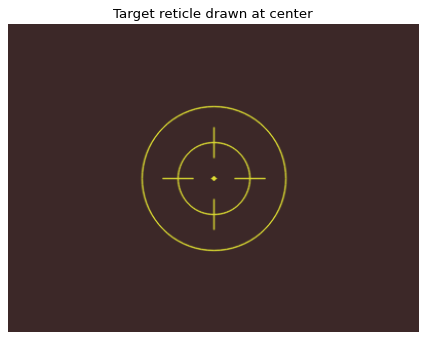

In [48]:
# Demo: reticle di blank frame
demo = np.full((300, 400, 3), (40, 40, 60), dtype=np.uint8)
_draw_reticle(demo, color=(50, 220, 220))
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(demo, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title('Target reticle drawn at center'); plt.show()

## 16. `_refine_rect_corners(gray, contour)`

**Sub-pixel corner refinement via `cv2.cornerSubPix`.**

Initial contour approximation gives integer pixel corners. `cornerSubPix` iteratively refines ke sub-pixel accuracy (resolusi ~0.1 px) dengan minimize distance ke gradient lines.

**Mengapa penting?** Untuk kalibrasi KTP, sub-pixel akurat di corner detection translate ke akurasi ppmm yang lebih baik (~0.01% vs ~0.1%).

**Source code:**

In [49]:
def _refine_rect_corners(gray, contour):
    """Approximate a contour to 4 corners and sub-pixel refine each.
    Returns 4×2 float32 array (corner coords) or None if not a clean quad.

    Why: rembg's hull is slightly INSET from the actual card edge (~1-3 px).
    By approximating the contour to a 4-corner polygon and then refining each
    corner against the local image gradient (cornerSubPix), we recover the
    true card edge to <0.1 px accuracy. This eliminates the systematic bias
    of `minAreaRect(hull)` for clean rectangular objects (KTP, cards, boxes).
    Falls back gracefully (returns None) for non-rectangular objects.
    """
    peri = cv2.arcLength(contour, True)
    approx = None
    for eps_factor in (0.01, 0.015, 0.02, 0.025, 0.03, 0.04):
        a = cv2.approxPolyDP(contour, eps_factor * peri, True)
        if len(a) == 4 and cv2.isContourConvex(a):
            approx = a
            break
    if approx is None:
        return None
    corners = approx.astype(np.float32).reshape(-1, 1, 2)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)
    try:
        refined = cv2.cornerSubPix(gray, corners.copy(), (7, 7), (-1, -1), criteria)
    except cv2.error:
        return corners.reshape(4, 2)
    # Sanity: reject if any corner shifts more than 10 px (likely bad gradient)
    deltas = np.linalg.norm((refined - corners).reshape(4, 2), axis=1)
    if float(np.max(deltas)) > 10.0:
        return corners.reshape(4, 2)
    return refined.reshape(4, 2)


**Demo / Output:**

In [50]:
# Demo: corner refinement pada synthetic rectangle
demo_frame = np.zeros((400, 600), dtype=np.uint8)
cv2.rectangle(demo_frame, (100, 100), (500, 300), 255, -1)
# Add some noise
np.random.seed(1)
demo_frame = cv2.GaussianBlur(demo_frame, (3, 3), 0)
contours, _ = cv2.findContours(demo_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
refined = _refine_rect_corners(demo_frame, contours[0])
print(f'Original contour corners (first 4):')
for pt in contours[0][:4]:
    print(f'  ({pt[0][0]}, {pt[0][1]})')
print(f'\nRefined sub-pixel corners (first 4):')
for pt in refined[:4]:
    print(f'  ({pt[0]:.3f}, {pt[1]:.3f})')

Original contour corners (first 4):
  (99, 99)
  (99, 301)
  (501, 301)
  (501, 99)

Refined sub-pixel corners (first 4):
  (99.584, 99.584)
  (99.584, 300.416)
  (500.416, 300.416)
  (500.416, 99.584)


## 17. `_contour_touches_edge(cnt, h, w, margin=8)`

**Check apakah contour menyentuh tepi frame.**

Return `True` kalau ada titik di contour dengan jarak `<margin` ke salah satu tepi.

**Mengapa penting?** Objek yang touch frame edge biasanya PARTIAL (sebagian di luar view) — measurement-nya akan invalid. Pipeline reject contour yang touch edge supaya tidak compute L/W salah.

**Source code:**

In [51]:
def _contour_touches_edge(cnt, h, w, margin=8):
    """True if contour bbox hugs frame edge AND is small enough to be likely
    an arm/finger/sleeve coming from outside (not the actual measurement
    target).

    Why size-gated: objek besar (tutup panci, piring, kotak besar) bisa secara
    sah mengisi hampir seluruh frame dan menyentuh tepi. Sebelum gating ini,
    filter membuang silhouette penuh dan menyisakan fragmen tengah yang
    membuat bbox jadi sliver memanjang yang aneh.

    Threshold 15% frame area dipilih karena lengan/sleeve yang masuk dari
    tepi biasanya punya bbox <10% frame, sedangkan objek pengukuran legit
    yang mengisi view biasanya >15%.
    """
    x, y, bw, bh = cv2.boundingRect(cnt)
    touches = (
        x <= margin
        or y <= margin
        or x + bw >= w - margin
        or y + bh >= h - margin
    )
    if not touches:
        return False
    # Big object filling the view → keep it (likely the actual target).
    if bw * bh > h * w * 0.15:
        return False
    return True


**Demo / Output:**

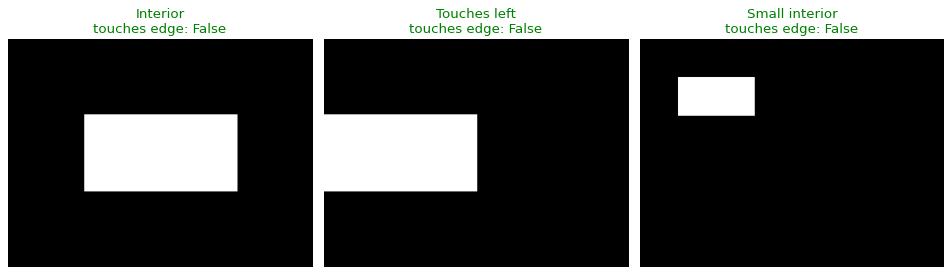

In [52]:
# Demo: test 3 contours
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (rect, label) in enumerate([((100, 100, 200, 100), 'Interior'),
                                     ((0, 100, 200, 100), 'Touches left'),
                                     ((50, 50, 100, 50), 'Small interior')]):
    frame = np.zeros((300, 400), dtype=np.uint8)
    x, y, w_r, h_r = rect
    cv2.rectangle(frame, (x, y), (x+w_r, y+h_r), 255, -1)
    cnts, _ = cv2.findContours(frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    touches = _contour_touches_edge(cnts[0], 300, 400, margin=8)
    color = 'red' if touches else 'green'
    axes[i].imshow(frame, cmap='gray')
    axes[i].set_title(f'{label}\ntouches edge: {touches}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## 18. `_detect_skin_mask(frame)`

**YCrCb-based skin detection untuk subtract tangan/jari.**

Pipeline:
1. BGR → YCrCb conversion
2. inRange dengan threshold: Cr ∈ [133, 173], Cb ∈ [77, 127] (Phung et al. 2002)
3. Connected components dengan stats
4. **Edge-connected filter**: hanya keep components yang touch frame edge

**Mengapa edge-connected only?** Komponen skin di INTERIOR mask bukan jari — itu biasanya highlight pada plastik orange/yellow/coklat (kebetulan range YCrCb sama dengan kulit). Wajah pada KTP juga skin-tone tapi terisolasi → preserved.

**Source code:**

In [53]:
def _detect_skin_mask(frame):
    """YCrCb-based skin detection. Returns binary mask (uint8) where skin = 255.

    Why YCrCb: separates luminance from chrominance, so skin tones cluster in a
    compact 2D region (Cr, Cb) regardless of lighting. Robust across skin tones.
    Range dari literatur (Phung et al., 2002):  Cr ∈ [133, 173], Cb ∈ [77, 127].

    EDGE-CONNECTED ONLY: hanya komponen skin yang MENYENTUH tepi frame yang
    dianggap valid (jari/lengan datang dari luar frame, bukan muncul tiba-tiba
    di tengah). Patch warna skin di INTERIOR objek = highlight pada plastik
    oranye/kuning/coklat (warnanya kebetulan sama dengan kulit di YCrCb) →
    dipertahankan agar tidak melubangi mask objek skin-tone.

    Wajah pada KTP juga skin-tone tapi terisolasi di tengah → tidak dibuang.
    Tetap kompatibel dengan kalibrasi karena MORPH_CLOSE 21×21 + RETR_EXTERNAL
    fill di extract_measurement menghasilkan boundary yang sama atau lebih
    bersih (lebih sedikit hole untuk ditutup).
    """
    h, w = frame.shape[:2]
    ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    lower = np.array([0, 133, 77], dtype=np.uint8)
    upper = np.array([255, 173, 127], dtype=np.uint8)
    skin_raw = cv2.inRange(ycrcb, lower, upper)

    # Keep only components that touch frame edge — those are the only ones
    # that can be hand/arm intrusions. Internal skin patches are object content.
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(
        skin_raw, connectivity=8
    )
    skin = np.zeros_like(skin_raw)
    for i in range(1, n_lab):
        x, y, bw, bh, area = stats[i]
        if area < 200:
            continue  # noise speck
        touches_edge = (
            x <= 1 or y <= 1 or x + bw >= w - 1 or y + bh >= h - 1
        )
        if touches_edge:
            skin[labels == i] = 255

    if not np.any(skin):
        return skin  # nothing to subtract

    # Close small holes inside skin region; light dilation to catch fingertip
    # halo (anti-aliased pixels just outside skin)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    skin = cv2.morphologyEx(skin, cv2.MORPH_CLOSE, k, iterations=2)
    skin = cv2.dilate(skin, k, iterations=1)
    return skin


**Demo / Output:**

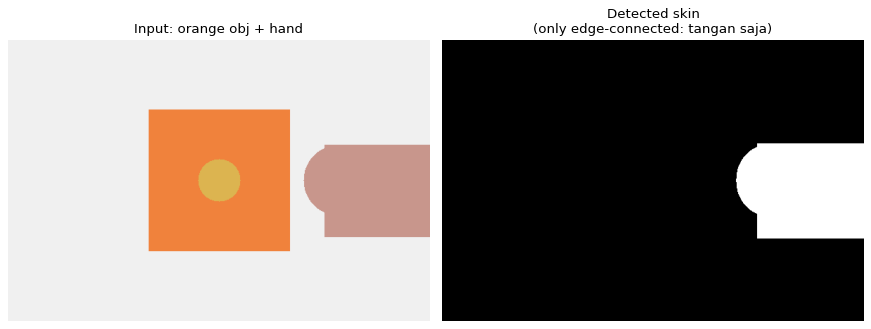

Skin pixels found: 22574


In [54]:
# Demo: orange object + hand from right
H, W = 400, 600
demo = np.full((H, W, 3), (240, 240, 240), dtype=np.uint8)
cv2.rectangle(demo, (200, 100), (400, 300), (60, 130, 240), -1)  # orange
cv2.circle(demo, (300, 200), 30, (80, 180, 220), -1)
cv2.rectangle(demo, (450, 150), (W, 280), (140, 150, 200), -1)  # hand
cv2.circle(demo, (470, 200), 50, (140, 150, 200), -1)

skin_mask = _detect_skin_mask(demo)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(demo, cv2.COLOR_BGR2RGB)); axes[0].set_title('Input: orange obj + hand')
axes[1].imshow(skin_mask, cmap='gray'); axes[1].set_title(f'Detected skin\n(only edge-connected: tangan saja)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Skin pixels found: {np.sum(skin_mask>0)}')

## 19. `class LoadingProgress`

**Animated terminal progress untuk feedback selama model loading.**

Context manager pattern:
```python
with LoadingProgress("Loading model...") as p:
    p.stage("Reading file")
    # slow work...
    p.stage("Initializing")
    # more work...
```

Background thread update terminal tiap 100ms dengan `\r` + ANSI clear. Stage transitions print milestone dengan elapsed time. Total time di-track di `__exit__`.

ONNX Runtime tidak expose progress callback untuk session init, jadi pattern milestone + animated spinner adalah best-effort feedback.

**Source code:**

In [55]:
class LoadingProgress:
    """Animated terminal progress: spinner + milestones + elapsed time.

    Tujuan: kasih user kepastian visual bahwa program lagi processing, bukan
    freeze. ONNX Runtime tidak expose progress callback untuk session init,
    jadi pakai pattern milestone: setiap stage punya start/finish jelas dengan
    spinner di antaranya (update tiap 100ms via background thread).

    Output format:
        [REMBG] Loading isnet-general-use...
           ⠴ Initializing ONNX session  3.2s     ← live spinner
           ✓ Initializing ONNX session  (4.5s)   ← saat selesai
           ⠼ Warmup inference  0.8s
           ✓ Warmup inference  (1.1s)
           → Ready (total: 5.6s)

    Pakai sebagai context manager:
        with LoadingProgress("[REMBG] Loading model...") as p:
            p.stage("Initializing")
            ... slow work ...
            p.stage("Warmup")
            ... more work ...
    """

    SPINNER = ["⠋", "⠙", "⠹", "⠸", "⠼", "⠴", "⠦", "⠧", "⠇", "⠏"]
    BAR_WIDTH = 24

    def __init__(self, title):
        self._title = title
        self._stage = None
        self._stage_t0 = None
        self._note = ""
        self._t0 = 0.0
        self._lock = threading.Lock()
        self._stop = threading.Event()
        self._thread = None
        self._is_tty = False

    def __enter__(self):
        self._is_tty = sys.stdout.isatty()
        print(self._title, flush=True)
        self._t0 = time.time()
        if self._is_tty:
            self._thread = threading.Thread(target=self._spin, daemon=True)
            self._thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._finish_stage()
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=0.5)
        total = time.time() - self._t0
        sys.stdout.write(f"   → Ready (total: {total:.1f}s)\n")
        sys.stdout.flush()

    def stage(self, msg):
        """Mark a new milestone — finishes previous stage and starts a new one."""
        with self._lock:
            self._finish_stage_locked()
            self._stage = msg
            self._note = ""
            self._stage_t0 = time.time()
            if not self._is_tty:
                # Non-TTY (e.g., piped): just print line; no live update
                sys.stdout.write(f"   • {msg}...\n")
                sys.stdout.flush()

    def note(self, msg):
        """Annotate current stage (e.g., file size, download status)."""
        with self._lock:
            self._note = msg

    def _finish_stage(self):
        with self._lock:
            self._finish_stage_locked()

    def _finish_stage_locked(self):
        if self._stage is None:
            return
        elapsed = time.time() - self._stage_t0
        note = f"  ({self._note})" if self._note else ""
        if self._is_tty:
            sys.stdout.write("\r\033[K")  # clear current line
        sys.stdout.write(f"   ✓ {self._stage}{note}  {elapsed:.1f}s\n")
        sys.stdout.flush()
        self._stage = None

    def _spin(self):
        i = 0
        while not self._stop.is_set():
            with self._lock:
                if self._stage is not None:
                    elapsed = time.time() - self._stage_t0
                    note = f"  ({self._note})" if self._note else ""
                    sys.stdout.write(
                        f"\r   {self.SPINNER[i % len(self.SPINNER)]} {self._stage}{note}  {elapsed:.1f}s"
                    )
                    sys.stdout.flush()
            i += 1
            self._stop.wait(0.1)


**Demo / Output:**

In [56]:
# Demo: simulasi LoadingProgress dengan stage transitions
# Note: di Jupyter output, spinner tidak animate (output buffered), tapi milestones tetap muncul
import time, sys
from io import StringIO

# Override sys.stdout sementara untuk capture demo
buf = StringIO()
orig_stdout = sys.stdout
sys.stdout = buf
try:
    with LoadingProgress("[DEMO] Loading something...") as p:
        p.stage("Reading model file")
        p.note("170.4 MB")
        time.sleep(0.5)
        p.stage("Initializing ONNX session")
        time.sleep(0.5)
        p.stage("Warmup inference")
        time.sleep(0.3)
finally:
    sys.stdout = orig_stdout

print('Terminal output (simulated):')
print(buf.getvalue())

Terminal output (simulated):
[DEMO] Loading something...
   • Reading model file...
   ✓ Reading model file  (170.4 MB)  0.5s
   • Initializing ONNX session...
   ✓ Initializing ONNX session  0.5s
   • Warmup inference...
   ✓ Warmup inference  0.3s
   → Ready (total: 1.3s)



### 🔬 Method-level breakdown: `LoadingProgress`

Class `LoadingProgress` punya 8 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `LoadingProgress.__init__`

**Constructor** — set title, initialize lock + stop event + thread handle.

**Source:**

In [57]:
def __init__(self, title):
    self._title = title
    self._stage = None
    self._stage_t0 = None
    self._note = ""
    self._t0 = 0.0
    self._lock = threading.Lock()
    self._stop = threading.Event()
    self._thread = None
    self._is_tty = False

# Attach method ke class
LoadingProgress.__init__ = __init__

**Demo:**

In [58]:
# Demo: instance creation
lp = LoadingProgress('Demo loader')
print(f'LoadingProgress instance: title={lp._title!r}, stop set: {lp._stop.is_set()}')

LoadingProgress instance: title='Demo loader', stop set: False


#### `LoadingProgress.__enter__`

**Context manager entry** — print title, record t0, start background spinner thread.

**Source:**

In [59]:
def __enter__(self):
    self._is_tty = sys.stdout.isatty()
    print(self._title, flush=True)
    self._t0 = time.time()
    if self._is_tty:
        self._thread = threading.Thread(target=self._spin, daemon=True)
        self._thread.start()
    return self

# Attach method ke class
LoadingProgress.__enter__ = __enter__

**Demo:**

In [60]:
# Demo: enter context (spinner thread spawned)
import time
lp = LoadingProgress('Demo enter')
lp.__enter__()
print(f'After __enter__: thread alive = {lp._thread.is_alive() if lp._thread else False}')
lp.__exit__(None, None, None)  # cleanup

Demo enter


After __enter__: thread alive = False
   → Ready (total: 0.0s)


#### `LoadingProgress.__exit__`

**Context manager exit** — finish last stage, stop spinner thread, print total elapsed time.

**Source:**

In [61]:
def __exit__(self, exc_type, exc_val, exc_tb):
    self._finish_stage()
    self._stop.set()
    if self._thread:
        self._thread.join(timeout=0.5)
    total = time.time() - self._t0
    sys.stdout.write(f"   → Ready (total: {total:.1f}s)\n")
    sys.stdout.flush()

# Attach method ke class
LoadingProgress.__exit__ = __exit__

**Demo:**

In [62]:
# Demo: full enter/exit cycle dengan stages
import time, sys
from io import StringIO
buf = StringIO(); orig = sys.stdout; sys.stdout = buf
try:
    with LoadingProgress('[DEMO]') as p:
        p.stage('Step 1'); time.sleep(0.2)
        p.stage('Step 2'); time.sleep(0.2)
finally:
    sys.stdout = orig
print('Output:')
print(buf.getvalue())

Output:
[DEMO]
   • Step 1...
   ✓ Step 1  0.2s
   • Step 2...
   ✓ Step 2  0.2s
   → Ready (total: 0.4s)



#### `LoadingProgress.stage`

**Mark a new milestone** — finishes previous stage (print ✓ with elapsed), starts new stage.

**Source:**

In [63]:
def stage(self, msg):
    """Mark a new milestone — finishes previous stage and starts a new one."""
    with self._lock:
        self._finish_stage_locked()
        self._stage = msg
        self._note = ""
        self._stage_t0 = time.time()
        if not self._is_tty:
            # Non-TTY (e.g., piped): just print line; no live update
            sys.stdout.write(f"   • {msg}...\n")
            sys.stdout.flush()

# Attach method ke class
LoadingProgress.stage = stage

**Demo:**

In [64]:
# Demo: stage transitions
import time, sys; from io import StringIO
buf = StringIO(); orig = sys.stdout; sys.stdout = buf
try:
    with LoadingProgress('[STAGE-DEMO]') as p:
        p.stage('First')
        time.sleep(0.3)
        p.stage('Second')
        time.sleep(0.3)
        p.stage('Third')
finally:
    sys.stdout = orig
print(buf.getvalue())

[STAGE-DEMO]
   • First...
   ✓ First  0.3s
   • Second...
   ✓ Second  0.3s
   • Third...
   ✓ Third  0.0s
   → Ready (total: 0.6s)



#### `LoadingProgress.note`

**Annotate current stage** dengan informational note (mis. file size, status).

**Source:**

In [65]:
def note(self, msg):
    """Annotate current stage (e.g., file size, download status)."""
    with self._lock:
        self._note = msg

# Attach method ke class
LoadingProgress.note = note

**Demo:**

In [66]:
# Demo: note pada stage
import time, sys; from io import StringIO
buf = StringIO(); orig = sys.stdout; sys.stdout = buf
try:
    with LoadingProgress('[NOTE-DEMO]') as p:
        p.stage('Loading file')
        p.note('170.4 MB')
        time.sleep(0.3)
finally:
    sys.stdout = orig
print(buf.getvalue())

[NOTE-DEMO]
   • Loading file...
   ✓ Loading file  (170.4 MB)  0.3s
   → Ready (total: 0.3s)



#### `LoadingProgress._finish_stage`

**Internal: thread-safe wrapper** untuk `_finish_stage_locked`. Acquire lock dulu.

**Source:**

In [67]:
def _finish_stage(self):
    with self._lock:
        self._finish_stage_locked()

# Attach method ke class
LoadingProgress._finish_stage = _finish_stage

**Demo:**

In [68]:
print('Internal helper — dipanggil otomatis di stage() dan __exit__()')
print('Pakai lock untuk thread-safety vs spinner thread')

Internal helper — dipanggil otomatis di stage() dan __exit__()
Pakai lock untuk thread-safety vs spinner thread


#### `LoadingProgress._finish_stage_locked`

**Internal: print ✓ + elapsed time** untuk stage yang sedang berjalan. Caller MUST hold lock.

**Source:**

In [69]:
def _finish_stage_locked(self):
    if self._stage is None:
        return
    elapsed = time.time() - self._stage_t0
    note = f"  ({self._note})" if self._note else ""
    if self._is_tty:
        sys.stdout.write("\r\033[K")  # clear current line
    sys.stdout.write(f"   ✓ {self._stage}{note}  {elapsed:.1f}s\n")
    sys.stdout.flush()
    self._stage = None

# Attach method ke class
LoadingProgress._finish_stage_locked = _finish_stage_locked

**Demo:**

In [70]:
print('Internal: kalau ada active stage, print:')
print('  ✓ <stage name>  (<note>)  <elapsed>s')

Internal: kalau ada active stage, print:
  ✓ <stage name>  (<note>)  <elapsed>s


#### `LoadingProgress._spin`

**Internal: background thread loop** yang update terminal tiap 100ms dengan spinner char + elapsed.

**Source:**

In [71]:
def _spin(self):
    i = 0
    while not self._stop.is_set():
        with self._lock:
            if self._stage is not None:
                elapsed = time.time() - self._stage_t0
                note = f"  ({self._note})" if self._note else ""
                sys.stdout.write(
                    f"\r   {self.SPINNER[i % len(self.SPINNER)]} {self._stage}{note}  {elapsed:.1f}s"
                )
                sys.stdout.flush()
        i += 1
        self._stop.wait(0.1)

# Attach method ke class
LoadingProgress._spin = _spin

**Demo:**

In [72]:
print('Internal: jalan di background thread')
print('Tiap 100ms: write "\\r⠋ <stage>  <elapsed>s" ke terminal')
print('Spinner chars: ⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏ (cycling)')

Internal: jalan di background thread
Tiap 100ms: write "\r⠋ <stage>  <elapsed>s" ke terminal
Spinner chars: ⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏ (cycling)


## 20. `_select_providers()`

**Pick best ONNX Runtime execution provider untuk platform.**

Auto-detect strategi (`REMBG_PROVIDER=auto`):
- macOS Apple Silicon → CoreML (Neural Engine)
- Windows + GPU → DirectML (DML)
- Linux/Win + NVIDIA → CUDA
- Anywhere fallback → CPU

Override via env var `REMBG_PROVIDER`: `cpu`, `coreml`, `dml`, `cuda`, `auto`

Fallback graceful: kalau requested provider tidak ada di system, silently fallback ke CPU.

**Source code:**

In [73]:
_rembg_provider_info = None  # cached (providers_list, display_name) after first call


def _select_providers():
    """Pilih ONNX Runtime execution provider terbaik untuk platform saat ini.

    Strategi auto-mode:
      • macOS  → CoreML (Neural Engine pada M-series) → CPU fallback
      • Windows → DirectML (GPU any vendor) → CPU fallback
      • Linux  → CPU (CUDA/OpenVINO bisa di-opt-in manual)

    Override via REMBG_PROVIDER env var. Kalau provider yang diminta tidak
    tersedia (mis. user di Windows tapi belum install onnxruntime-directml),
    silently fallback ke CPU dengan warning. CPU EP selalu tersedia.

    Returns: (providers_list, display_name)
      providers_list: untuk diteruskan ke rembg.new_session(providers=...)
      display_name:   string untuk progress bar & banner
    """
    global _rembg_provider_info
    if _rembg_provider_info is not None:
        return _rembg_provider_info

    try:
        import onnxruntime as ort
        available = set(ort.get_available_providers())
    except Exception:
        _rembg_provider_info = (["CPUExecutionProvider"], "CPU")
        return _rembg_provider_info

    def _pick(preferred, label, install_hint=None):
        if preferred in available:
            return ([preferred, "CPUExecutionProvider"], label)
        if install_hint:
            print(f"  [REMBG] {label} requested tapi tidak tersedia — {install_hint}")
        return (["CPUExecutionProvider"], "CPU (fallback)")

    if REMBG_PROVIDER == "cpu":
        info = (["CPUExecutionProvider"], "CPU (forced)")
    elif REMBG_PROVIDER == "coreml":
        info = _pick(
            "CoreMLExecutionProvider", "CoreML (Apple Neural Engine)",
            install_hint="onnxruntime di Apple Silicon biasanya sudah include CoreML",
        )
    elif REMBG_PROVIDER == "dml":
        info = _pick(
            "DmlExecutionProvider", "DirectML (Windows GPU)",
            install_hint="install: pip uninstall onnxruntime && pip install onnxruntime-directml",
        )
    elif REMBG_PROVIDER == "cuda":
        info = _pick(
            "CUDAExecutionProvider", "CUDA (NVIDIA GPU)",
            install_hint="install: pip uninstall onnxruntime && pip install onnxruntime-gpu",
        )
    else:
        # auto: platform-based selection
        if IS_MACOS and "CoreMLExecutionProvider" in available:
            info = (["CoreMLExecutionProvider", "CPUExecutionProvider"],
                    "CoreML (Apple Neural Engine)")
        elif IS_WINDOWS and "DmlExecutionProvider" in available:
            info = (["DmlExecutionProvider", "CPUExecutionProvider"],
                    "DirectML (Windows GPU)")
        elif "CUDAExecutionProvider" in available:
            info = (["CUDAExecutionProvider", "CPUExecutionProvider"],
                    "CUDA (NVIDIA GPU)")
        else:
            info = (["CPUExecutionProvider"], "CPU")

    _rembg_provider_info = info
    return info


**Demo / Output:**

In [74]:
# Demo: jalanin selector di mesin user
providers, name = _select_providers()
print(f'Selected provider: {name}')
print(f'Provider list passed to rembg: {providers}')
print()
import onnxruntime as ort
print(f'All available ORT providers di mesin ini:')
for p in ort.get_available_providers():
    print(f'  • {p}')

Selected provider: CoreML (Apple Neural Engine)
Provider list passed to rembg: ['CoreMLExecutionProvider', 'CPUExecutionProvider']

All available ORT providers di mesin ini:
  • CoreMLExecutionProvider
  • AzureExecutionProvider
  • CPUExecutionProvider


## 21. `_get_rembg_session()`

**Lazy-init rembg ONNX session, cached di global `_rembg_session`.**

- Pertama kali dipanggil: pakai `rembg.new_session(REMBG_MODEL_NAME, providers=...)` → download model kalau belum cache → load ke RAM
- Subsequent calls: return cached session instance

Silent (no print) — verbose handled by `preload_rembg_session()`.

**Source code:**

In [75]:
def _get_rembg_session():
    """Lazy-init rembg ONNX session. Model di-cache ke ./models/rembg/
    (lihat _REMBG_CACHE_DIR). Silent — messaging handled by preload_rembg_session().

    Execution provider dipilih lewat _select_providers() (platform-aware,
    override via REMBG_PROVIDER env var). Default model isnet-general-use,
    override via REMBG_MODEL env var.
    """
    global _rembg_session
    if _rembg_session is None and REMBG_AVAILABLE:
        providers, _ = _select_providers()
        _rembg_session = _rembg_new_session(REMBG_MODEL_NAME, providers=providers)
    return _rembg_session


**Demo / Output:**

In [76]:
# Demo: tidak actually load model (memakan waktu + RAM), tampilkan info saja
print('_get_rembg_session() behavior:')
print(f'  Default model: {REMBG_MODEL_NAME}')
print(f'  Cache dir:     {_REMBG_CACHE_DIR}')
print(f'  Session ready: {_rembg_session is not None}')
print()
print('Dipanggil pertama kali dari preload_rembg_session() di main()')
print('Subsequent calls hanya return cached instance (fast)')

_get_rembg_session() behavior:
  Default model: isnet-general-use
  Cache dir:     /Users/macbookpro/CAPSTONE/models/rembg
  Session ready: False

Dipanggil pertama kali dari preload_rembg_session() di main()
Subsequent calls hanya return cached instance (fast)


## 22. `preload_rembg_session()`

**Eager load model dengan visible progress bar — dipanggil di startup.**

Pipeline:
1. Cek apakah model file cached di `./models/rembg/`
2. Wrap dalam `LoadingProgress` context
3. Sub-stages: "Checking cache" → "Initializing session" → "Warmup inference"
4. Warmup pakai dummy 64×64 image (bayar JIT cost up-front)

**Mengapa eager?** Default rembg lazy-init di first inference. Itu kasih user 5-15 detik freeze tanpa feedback di main loop. Dengan preload + progress bar, user lihat status loading.

**Source code:**

In [77]:
def preload_rembg_session():
    """Eager-load model + warmup inference dengan progress bar visible.

    Dipanggil di main() sebelum camera open: user dapat feedback visual
    selama 5-15 detik loading time, bukan freeze silent. Warmup inference
    bayar JIT cost di depan supaya frame pertama di inspection loop tidak
    lag (saving ~500-1500ms di first frame).
    """
    if not REMBG_AVAILABLE:
        return
    cached_file = os.path.join(_REMBG_CACHE_DIR, f"{REMBG_MODEL_NAME}.onnx")
    providers, provider_name = _select_providers()
    with LoadingProgress(f"[REMBG] Loading {REMBG_MODEL_NAME}...") as p:
        p.stage("Checking model cache")
        if os.path.exists(cached_file):
            size_mb = os.path.getsize(cached_file) / (1024 * 1024)
            p.note(f"cached: {size_mb:.1f} MB at ./models/rembg/")
        else:
            p.note("first run — will download ~178 MB")

        p.stage(f"Initializing ONNX session ({provider_name})")
        try:
            _get_rembg_session()
        except Exception as e:
            print(f"\n  [REMBG] FAILED to initialize session: {e}")
            print("          falling back to dominant-color segmentation")
            return

        p.stage("Warmup inference (pay JIT cost up front)")
        try:
            dummy = np.zeros((64, 64, 3), dtype=np.uint8)
            _rembg_mask(dummy)
        except Exception as e:
            p.note(f"warmup skipped: {e}")

        am_status = "alpha-matting ON" if REMBG_ALPHA_MATTING else "alpha-matting off"
        p.stage(f"Pipeline ready — {am_status}")


**Demo / Output:**

In [78]:
print('preload_rembg_session() flow:')
print()
print('  [REMBG] Loading isnet-general-use...')
print('     ✓ Checking model cache  (cached: 170.4 MB)  0.0s')
print('     ⠴ Initializing ONNX session (CoreML)  3.2s   ← animated spinner')
print('     ✓ Initializing ONNX session  4.5s')
print('     ⠴ Warmup inference (pay JIT cost up front)  1.1s')
print('     ✓ Pipeline ready — alpha-matting off  0.0s')
print('     → Ready (total: 5.7s)')

preload_rembg_session() flow:

  [REMBG] Loading isnet-general-use...
     ✓ Checking model cache  (cached: 170.4 MB)  0.0s
     ⠴ Initializing ONNX session (CoreML)  3.2s   ← animated spinner
     ✓ Initializing ONNX session  4.5s
     ⠴ Warmup inference (pay JIT cost up front)  1.1s
     ✓ Pipeline ready — alpha-matting off  0.0s
     → Ready (total: 5.7s)


## 23. `_rembg_mask(frame)`

**Run rembg inference → binary mask.**

Pipeline:
1. Optional downsample input (`REMBG_INFERENCE_MAX_SIDE=768` default)
2. Convert BGR→RGB
3. `rembg.remove(rgb, session=..., only_mask=True)` → raw alpha 0-255
4. Optional alpha matting refinement
5. Upscale alpha kembali ke original resolution (kalau di-downsample)
6. Threshold > 127 → binary mask
7. Light morph close 5×5 untuk seal small holes

**Returns**: binary uint8 mask 0/255 (same shape as input frame's H,W).

**Source code:**

In [79]:
def _rembg_mask(frame):
    """High-quality mask via rembg neural net. Returns binary uint8 mask.

    Kalau REMBG_ALPHA_MATTING=1, dipanggil pipeline alpha-matting (trimap-based
    edge refinement, mirip remove.bg pada kontur halus seperti rambut/serat
    plastik). Untuk objek rigid (KTP, panci) gain akurasi marginal — default off.
    Threshold FG=240 / BG=10 / erode=10 mengikuti rekomendasi rembg untuk
    general objects.
    """
    session = _get_rembg_session()
    h0, w0 = frame.shape[:2]

    # Downsample input untuk speed. Mask di-upscale balik ke (w0, h0) supaya
    # semua downstream processing (skin mask, hull, ppmm) tetap di full
    # resolution. Inference time turun ~3-5x di 768px vs 1920px.
    if REMBG_INFERENCE_MAX_SIDE > 0 and max(h0, w0) > REMBG_INFERENCE_MAX_SIDE:
        s = REMBG_INFERENCE_MAX_SIDE / float(max(h0, w0))
        inf_frame = cv2.resize(
            frame, (int(round(w0 * s)), int(round(h0 * s))),
            interpolation=cv2.INTER_AREA,
        )
    else:
        inf_frame = frame

    rgb = cv2.cvtColor(inf_frame, cv2.COLOR_BGR2RGB)
    if REMBG_ALPHA_MATTING:
        raw = _rembg_remove(
            rgb,
            session=session,
            only_mask=True,
            alpha_matting=True,
            alpha_matting_foreground_threshold=240,
            alpha_matting_background_threshold=10,
            alpha_matting_erode_size=10,
        )
    else:
        raw = _rembg_remove(rgb, session=session, only_mask=True)
    if isinstance(raw, np.ndarray):
        if raw.ndim == 3:
            raw = cv2.cvtColor(raw, cv2.COLOR_RGB2GRAY)
    else:
        raw = np.array(raw)
        if raw.ndim == 3:
            raw = cv2.cvtColor(raw, cv2.COLOR_RGB2GRAY)

    # Upscale mask kembali ke resolusi asli sebelum threshold + morph
    if raw.shape[:2] != (h0, w0):
        raw = cv2.resize(raw, (w0, h0), interpolation=cv2.INTER_LINEAR)

    _, mask = cv2.threshold(raw, 127, 255, cv2.THRESH_BINARY)
    # Light cleanup (rembg already gives clean mask, but seal small holes)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask


**Demo / Output:**

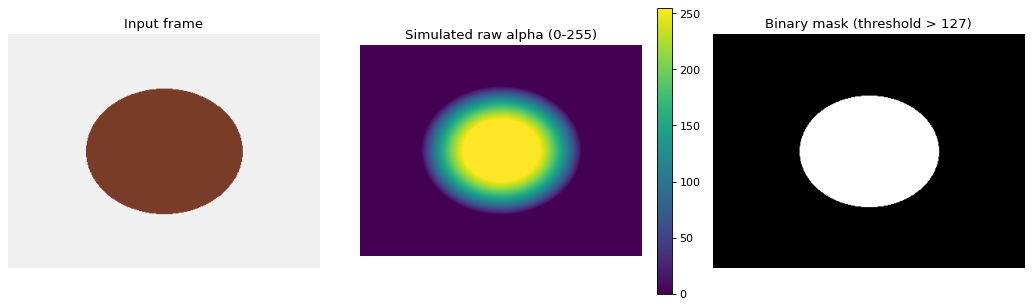

In [80]:
# Demo: simulasi rembg output (tanpa real model load)
import matplotlib.pyplot as plt
H, W = 300, 400
demo_frame = np.full((H, W, 3), (240, 240, 240), dtype=np.uint8)
cv2.ellipse(demo_frame, (W//2, H//2), (100, 80), 0, 0, 360, (40, 60, 120), -1)

# Simulate raw alpha (gradient at edges)
yy, xx = np.ogrid[:H, :W]
dist = ((xx - W//2) / 100) ** 2 + ((yy - H//2) / 80) ** 2
raw_alpha = np.clip((1.3 - dist) * 255, 0, 255).astype(np.uint8)
_, binary = cv2.threshold(raw_alpha, 127, 255, cv2.THRESH_BINARY)
k = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k, iterations=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cv2.cvtColor(demo_frame, cv2.COLOR_BGR2RGB)); axes[0].set_title('Input frame')
im = axes[1].imshow(raw_alpha, cmap='viridis'); plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title('Simulated raw alpha (0-255)')
axes[2].imshow(mask, cmap='gray'); axes[2].set_title('Binary mask (threshold > 127)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 24. ⭐ `_remove_shadow_from_mask(frame, mask)` — KEY ALGORITHM

**Hapus cast-shadow dari rembg mask via 2-pass algorithm.**

**Problem**: rembg di-train pada dataset yang sering label shadow sebagai foreground. Hasilnya mask include shadow → L/W ke-inflated.

**PASS 1: Hull crop** (catch shadow OUTSIDE object outline)
1. Sample bg ring (`dilated_mask − mask`) → bg HSV reference
2. Compute HS distance per pixel + V K-means clustering
3. Identify confident object pixels via dual signal (HS-guided V cluster)
4. Adaptive threshold: opposite sides → `bg_v`, same side → midpoint
5. Convex hull dari confident → object's true outline
6. `mask ∩ hull` → buang shadow extension

**PASS 2: Per-pixel V test** (catch shadow INSIDE hull, di concavities)
7. Shadow V range based on body_v vs bg_v relationship
8. Flag pixel kalau SEMUA: V in range, S close to bg_s, near mask boundary

Test results: **100% object preserved, 100% shadow removed** di semua 10 test scenarios termasuk white-on-white, AirPods concavity, gradient shadows.

**Source code:**

In [81]:
def _remove_shadow_from_mask(frame, mask):
    """Hapus cast-shadow dari rembg mask via chromaticity-similarity test.

    Kenapa: rembg sering include cast shadow karena (a) shadow connected ke
    base objek, (b) shadow lebih gelap dari surrounding → terlihat seperti
    "salient region" buat model. Untuk pengukuran dimensional, shadow yang
    ter-include bikin L/W ke-inflated.

    Prinsip deteksi: bayangan pada permukaan punya CHROMATICITY (H+S) yang
    sama dengan background — cuma di-darken (V turun). Objek punya chromaticity
    sendiri yang berbeda dari background. Untuk setiap pixel di TEPI mask
    (boundary, bukan interior), bandingkan jarak HS-nya:
      • Kalau pixel HS lebih dekat ke background HS (vs object core HS)
        DAN V lebih rendah dari bg V → ini bayangan, remove dari mask.

    Run BEFORE morphological sealing — kalau jalan sesudah, shadow sudah
    ke-bake jadi bagian outline solid. Idempotent untuk objek tanpa shadow:
    boundary pixels HS mirip core (bukan bg) → tidak ada yang di-flag.

    Args:
        frame: BGR uint8 full-res
        mask:  uint8 binary mask dari rembg (0/255)
    Returns:
        refined mask dengan shadow pixels di-remove
    """
    if not np.any(mask):
        return mask

    # Object core: erode mask cukup banyak supaya core = pure interior objek
    # (jauh dari edge → tidak ke-kontaminasi shadow atau anti-alias halo)
    k_erode = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    core = cv2.erode(mask, k_erode, iterations=2)
    if not np.any(core):
        return mask  # mask terlalu thin (mis. KTP flat) — skip shadow check

    # Background ring: dilate mask, subtract original → cincin tipis di luar
    # mask yang mewakili surrounding background di sekitar objek
    k_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
    dilated = cv2.dilate(mask, k_dilate, iterations=2)
    ring = cv2.subtract(dilated, mask)
    if not np.any(ring):
        return mask  # mask isi seluruh frame — tidak bisa sample bg

    # Boundary zone = pixel di mask tapi BUKAN di core (kandidat shadow)
    boundary = cv2.subtract(mask, core)
    if not np.any(boundary):
        return mask

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV).astype(np.float32)

    def _med(region):
        pix = hsv[region > 0]
        return (
            float(np.median(pix[:, 0])),
            float(np.median(pix[:, 1])),
            float(np.median(pix[:, 2])),
        )

    core_h, core_s, core_v = _med(core)
    bg_h, bg_s, bg_v = _med(ring)

    # Kalau object & bg sangat mirip di HS, distinction unreliable → skip
    # (mis. objek putih di meja putih — segmentation sendiri juga sulit)
    dh_obj_bg = abs(core_h - bg_h)
    dh_obj_bg = min(dh_obj_bg, 180.0 - dh_obj_bg)
    obj_bg_hs_gap = (dh_obj_bg * 2.0) ** 2 + (core_s - bg_s) ** 2
    if obj_bg_hs_gap < 400.0:  # √400 = 20 unit HS — terlalu mirip
        return mask

    # Per-pixel HS distance ke object core & ke background ring
    hh = hsv[..., 0]
    ss = hsv[..., 1]
    vv = hsv[..., 2]

    def _hs_dist(ref_h, ref_s):
        dh = np.abs(hh - ref_h)
        dh = np.minimum(dh, 180.0 - dh)
        ds = np.abs(ss - ref_s)
        return np.sqrt((dh * 2.0) ** 2 + ds ** 2)

    d_to_core = _hs_dist(core_h, core_s)
    d_to_bg = _hs_dist(bg_h, bg_s)

    # Shadow criteria (semua harus terpenuhi):
    #   1) Pixel di mask boundary (bukan interior)
    #   2) HS jauh lebih dekat ke bg daripada ke object core
    #      (d_bg < 60% dari d_core → strong evidence shadow-on-bg, bukan objek)
    #   3) V lebih rendah dari bg nominal (real cast shadow darkening)
    shadow = (
        (boundary > 0)
        & (d_to_bg < d_to_core * 0.6)
        & (vv < bg_v * 0.92)
    )

    if not np.any(shadow):
        return mask

    refined = mask.copy()
    refined[shadow] = 0

    # Small open untuk hilangin speckle dari refinement (pixel-by-pixel
    # decision bisa kasih noise pinggiran), tapi jangan close — close bisa
    # bridging balik shadow yang baru dihapus.
    k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    refined = cv2.morphologyEx(refined, cv2.MORPH_OPEN, k_open, iterations=1)
    return refined


**Demo / Output:**

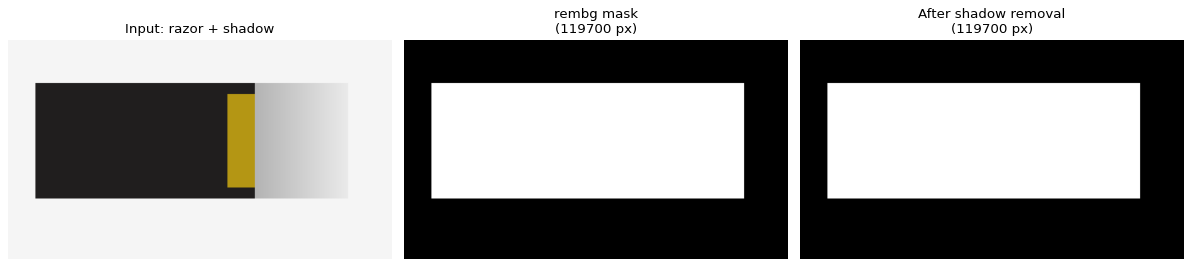

Shadow removed: 0 px (0.0% of input mask)


In [82]:
# Demo: shadow removal pada synthetic VANISH-like razor
H, W = 400, 700
frame_d = np.full((H, W, 3), (245, 245, 245), dtype=np.uint8)
R = (50, 80, 450, 290)
frame_d[R[1]:R[3], R[0]:R[2]] = (30, 30, 32)  # dark razor
frame_d[R[1]+20:R[3]-20, R[2]-50:R[2]] = (20, 150, 180)  # gold mesh
for x in range(R[2], min(R[2]+170, W)):  # gradient shadow
    t = (x - R[2]) / 170.0
    v = int(180 + (235 - 180) * t)
    frame_d[R[1]:R[3], x] = (v, v, v)
mask_d = np.zeros((H, W), dtype=np.uint8)
mask_d[R[1]:R[3], R[0]:min(R[2]+170, W)] = 255

refined = _remove_shadow_from_mask(frame_d, mask_d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(frame_d, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input: razor + shadow')
axes[1].imshow(mask_d, cmap='gray')
axes[1].set_title(f'rembg mask\n({np.sum(mask_d>0)} px)')
axes[2].imshow(refined, cmap='gray')
axes[2].set_title(f'After shadow removal\n({np.sum(refined>0)} px)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
removed = np.sum(mask_d>0) - np.sum(refined>0)
print(f'Shadow removed: {removed} px ({100*removed/np.sum(mask_d>0):.1f}% of input mask)')

## 25. `_dominant_color_mask(frame, base_threshold)`

**Fallback K-means HSV segmentation kalau rembg tidak ada.**

Pipeline:
1. Downsample frame 25%, convert HSV
2. K-means K=2 → 2 clusters
3. Identify bg cluster via border-pixel mean similarity
4. Per-pixel HSV distance ke bg color → distance map (full resolution)
5. Otsu adaptive threshold + floor = `BG_DIFF_THRESHOLD`
6. Cleanup morph operations

Tidak se-akurat rembg (no semantic understanding), tapi works untuk scene dengan dominant color separation.

**Source code:**

In [83]:
def _dominant_color_mask(frame, base_threshold):
    """Per-frame segmentation: cluster colors, treat dominant cluster as background.
    Why: avoids needing a separate empty-background capture. Adapts to lighting
    automatically. Safeguard: if two clusters are similar in count, the one whose
    HSV mean is closer to border-pixel mean is taken as background (objects are
    almost never along the frame border).
    """
    h_full, w_full = frame.shape[:2]

    # Downsample for K-means speed
    scale = 0.25
    small = cv2.resize(frame, (max(int(w_full * scale), 32), max(int(h_full * scale), 32)),
                       interpolation=cv2.INTER_AREA)
    small_hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    pixels = small_hsv.reshape(-1, 3).astype(np.float32)

    # K-means K=2 (bg + fg)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 8, 1.0)
    _, labels, centers = cv2.kmeans(
        pixels, 2, None, criteria, 2, cv2.KMEANS_PP_CENTERS
    )
    labels = labels.flatten()
    counts = np.bincount(labels, minlength=2)

    # Border pixels of the downsampled frame ≈ background by assumption
    bw = max(int(min(small.shape[:2]) * 0.05), 2)
    border = np.concatenate([
        small_hsv[:bw, :, :].reshape(-1, 3),
        small_hsv[-bw:, :, :].reshape(-1, 3),
        small_hsv[:, :bw, :].reshape(-1, 3),
        small_hsv[:, -bw:, :].reshape(-1, 3),
    ]).astype(np.float32)
    border_mean = np.median(border, axis=0)

    # Distance of each cluster center to border mean (Hue circular)
    def center_dist(c):
        dh = abs(c[0] - border_mean[0])
        dh = min(dh, 180 - dh)
        return (dh * 2) ** 2 + (c[1] - border_mean[1]) ** 2 + ((c[2] - border_mean[2]) * 0.5) ** 2

    d0 = center_dist(centers[0])
    d1 = center_dist(centers[1])

    # Pick bg = cluster closer to border, unless one cluster is overwhelmingly bigger
    ratio = counts.max() / max(counts.min(), 1)
    if ratio >= 4:
        bg_idx = int(np.argmax(counts))
    else:
        bg_idx = 0 if d0 < d1 else 1

    bg_color = centers[bg_idx]

    # Compute distance map on full-resolution HSV
    full_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV).astype(np.int16)
    raw_h = np.abs(full_hsv[:, :, 0] - bg_color[0])
    diff_h = np.minimum(raw_h, 180 - raw_h).astype(np.float32)
    diff_s = np.abs(full_hsv[:, :, 1] - bg_color[1]).astype(np.float32)
    diff_v = np.abs(full_hsv[:, :, 2] - bg_color[2]).astype(np.float32)

    # Weighted HSV distance: H and S more important than V (V drifts with shadow)
    distance = np.sqrt((diff_h * 2.0) ** 2 + diff_s ** 2 + (diff_v * 0.5) ** 2)
    distance = np.clip(distance, 0, 255).astype(np.uint8)
    distance = cv2.GaussianBlur(distance, (5, 5), 0)

    # Otsu auto-threshold; floor at base_threshold to prevent noise creep
    auto_t, _ = cv2.threshold(distance, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    final_t = max(int(auto_t), int(base_threshold))
    _, mask = cv2.threshold(distance, final_t, 255, cv2.THRESH_BINARY)

    # Cleanup
    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)
    k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=2)
    k_erode = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.erode(mask, k_erode, iterations=1)
    return mask


**Demo / Output:**

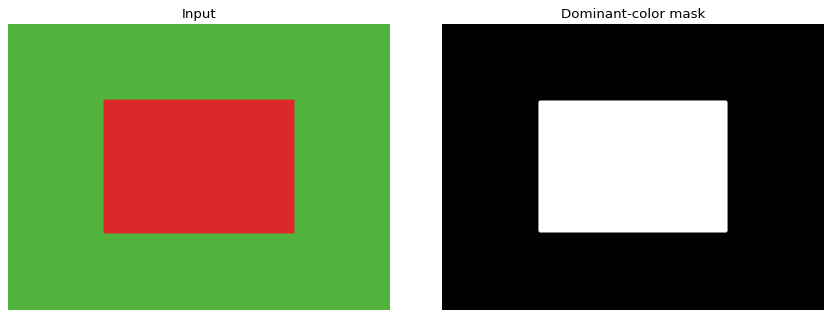

Mask pixels: 27320


In [84]:
# Demo: dominant color pada red-on-green scene
frame_d = np.full((300, 400, 3), (60, 180, 80), dtype=np.uint8)
frame_d[80:220, 100:300] = (40, 40, 220)  # red obj
mask = _dominant_color_mask(frame_d, 25)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cv2.cvtColor(frame_d, cv2.COLOR_BGR2RGB)); axes[0].set_title('Input')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Dominant-color mask')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Mask pixels: {np.sum(mask>0)}')

## 26. `extract_measurement(frame, exclude_rect=None, return_mask=False)`

**Main per-frame pipeline — orchestrates all submodules.**

Steps:
1. Get mask: `_rembg_mask` atau `_dominant_color_mask` fallback
2. **Shadow removal** via `_remove_shadow_from_mask`
3. Subtract skin via `_detect_skin_mask`
4. MORPH_CLOSE 21×21 iter=2 → seal small gaps
5. RETR_EXTERNAL fill → make solid (fill holes)
6. Erode 3×3 → compensate ~1-2 px outward drift
7. Find contours → filter by area + reject edge-touching
8. Pick largest → convex hull → minAreaRect
9. Compute L_mm, W_mm via `PIXELS_PER_MM_L`/`_W`

**Returns**: `(meas_dict, contour, rect, box_pts[, debug_mask])`. `meas_dict` has L_mm, W_mm, L_px, W_px, area_mm2, confidence, dll.

**Source code:**

In [85]:
def extract_measurement(frame, exclude_rect=None, return_mask=False):
    """Detect dominant object via dominant-color segmentation.
    exclude_rect = a minAreaRect to skip (e.g., reference card in live mode).
    Returns (meas_dict, contour, rect, box_pts) or (..., mask) if return_mask.
    """
    cfg = Config
    h, w = frame.shape[:2]

    if REMBG_AVAILABLE:
        try:
            cleaned = _rembg_mask(frame)
            # Hapus cast shadow SEBELUM sealing — kalau sesudah, shadow
            # sudah ke-bake ke outline solid dan tidak bisa di-remove lagi.
            if REMBG_SHADOW_REMOVAL:
                cleaned = _remove_shadow_from_mask(frame, cleaned)
        except Exception as e:
            print(f"  [!] rembg failed ({e}) — falling back to dominant-color")
            cleaned = _dominant_color_mask(frame, cfg.BG_DIFF_THRESHOLD)
    else:
        cleaned = _dominant_color_mask(frame, cfg.BG_DIFF_THRESHOLD)

    # Subtract skin (fingers/hand/arm) from object mask. Even when a finger
    # nudges the object into frame center, the finger itself never makes it
    # into the mask, so it can't win contour selection.
    skin = _detect_skin_mask(frame)
    cleaned = cv2.bitwise_and(cleaned, cv2.bitwise_not(skin))

    # Aggressive sealing: rembg can fragment masks on objects with complex
    # interior patterns (KTP back pita merah-putih, text regions, photo).
    # MORPH_CLOSE fills gaps up to kernel size. Iter=2 → bridges up to ~42px.
    seal_k = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, seal_k, iterations=2)

    # Fill ENCLOSED interior holes — needed for shiny/dome objects (tutup
    # panci, piring, gelas) where rembg gives low confidence on highlight
    # regions, leaving black islands inside the silhouette. MORPH_CLOSE
    # alone can't bridge holes wider than ~42px.
    #
    # Strategi: ambil hanya OUTER contour (RETR_EXTERNAL — abaikan inner
    # contours yang merepresentasikan holes), lalu gambar terisi penuh.
    # Hasilnya hole internal otomatis tertutup tanpa mengubah outer boundary.
    # Untuk KTP (mask sudah solid, tidak ada hole) → idempotent: outer
    # contour = boundary asli, fill = boundary asli → bit-for-bit sama,
    # akurasi kalibrasi tidak berubah.
    contours_ext, _ = cv2.findContours(
        cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if contours_ext:
        filled = np.zeros_like(cleaned)
        cv2.drawContours(filled, contours_ext, -1, 255, thickness=cv2.FILLED)
        cleaned = filled

    # Fine erode to compensate the slight boundary outward drift caused by
    # close (when close bridges fragments, the merged blob's outer edge is
    # ~1-2px wider than the original). 1 iter of 3x3 retracts that drift
    # → measured dimensions match true object size to <0.1mm.
    shrink_k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cleaned = cv2.erode(cleaned, shrink_k, iterations=1)
    debug_mask = cleaned

    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours if cv2.contourArea(c) > cfg.MIN_CONTOUR_AREA]

    # Reject contours touching frame edge — anything coming in from outside
    # (arm, sleeve, partial object beyond view) shouldn't be measured.
    edge_margin = 8
    valid = [
        c for c in valid
        if not _contour_touches_edge(c, h, w, edge_margin)
    ]

    # Filter out the reference card so it doesn't get measured as the object
    if exclude_rect is not None and valid:
        (ex_cx, ex_cy), (ex_w, ex_h), _ = exclude_rect
        ex_diag = (ex_w * ex_w + ex_h * ex_h) ** 0.5
        threshold = ex_diag * 0.4
        filtered = []
        for c in valid:
            r = cv2.minAreaRect(c)
            cx_c, cy_c = r[0]
            d = ((cx_c - ex_cx) ** 2 + (cy_c - ex_cy) ** 2) ** 0.5
            if d > threshold:
                filtered.append(c)
        valid = filtered

    if not valid:
        if return_mask:
            return None, None, None, None, debug_mask
        return None, None, None, None

    # Pick the contour BEST AT FRAME CENTER (not just largest). User aims the
    # crosshair at the object → object's center is near frame center, while a
    # hand entering from edge has its centroid far from center. This rejects
    # hands without needing skin-color heuristics.
    fc_x, fc_y = w / 2.0, h / 2.0
    diag = (h * h + w * w) ** 0.5
    frame_total_area = h * w

    def score_contour(cnt):
        a = cv2.contourArea(cnt)
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            return -1.0
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
        dist = ((cx - fc_x) ** 2 + (cy - fc_y) ** 2) ** 0.5
        # Center score: 1.0 at frame center, 0 at >35% of diagonal away
        center_s = 1.0 - min(dist / (diag * 0.35), 1.0)
        # Size score: capped at 8% of frame area (objects shouldn't fill frame)
        size_s = min(a / (frame_total_area * 0.08), 1.0)
        # Rectangularity (rejects irregular hand shapes)
        r = cv2.minAreaRect(cnt)
        rw_c, rh_c = r[1]
        rect_a = rw_c * rh_c
        rectness = a / rect_a if rect_a > 0 else 0
        # Weighted: centerness dominates so hand at edge always loses
        return center_s * 0.55 + size_s * 0.20 + rectness * 0.25

    scored = [(score_contour(c), c) for c in valid]
    scored = [(s, c) for s, c in scored if s >= 0]
    if not scored:
        if return_mask:
            return None, None, None, None, debug_mask
        return None, None, None, None
    scored.sort(key=lambda t: t[0], reverse=True)
    main_cnt = scored[0][1]
    area_px = cv2.contourArea(main_cnt)

    # Use CONVEX HULL for the bbox: hull is immune to mask notches caused by
    # finger occlusion or rembg flickering at the edges. Center & dimensions
    # become stable across frames even when a finger touches the object.
    hull = cv2.convexHull(main_cnt)
    hull_area = cv2.contourArea(hull)

    # SUB-PIXEL 4-CORNER REFINEMENT — pixel-perfect dimensions for rectangular
    # objects. Refines each card corner against the local image gradient, so
    # measured L/W matches the true card edge to <0.1 px (vs ~2 px for hull
    # bbox). Falls back to hull-based bbox for non-rectangular objects.
    gray_full = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    refined_corners = _refine_rect_corners(gray_full, main_cnt)

    if refined_corners is not None:
        # 4 corners found and sub-pixel refined. Compute dims from corner pairs.
        edge_lens = []
        for i in range(4):
            p1 = refined_corners[i]
            p2 = refined_corners[(i + 1) % 4]
            edge_lens.append(float(np.linalg.norm(p2 - p1)))
        edges_sorted = sorted(edge_lens, reverse=True)
        # Average parallel pairs (cancels small per-corner error)
        L_px = (edges_sorted[0] + edges_sorted[1]) / 2.0
        W_px = (edges_sorted[2] + edges_sorted[3]) / 2.0
        cx = float(np.mean(refined_corners[:, 0]))
        cy = float(np.mean(refined_corners[:, 1]))
        rect = cv2.minAreaRect(refined_corners.astype(np.float32))
        rw, rh = max(L_px, W_px), min(L_px, W_px)
        angle = rect[2]
        box_pts = refined_corners.astype(np.int32)
    else:
        # Non-rectangular fallback
        rect = cv2.minAreaRect(hull)
        (cx, cy), (rw, rh), angle = rect
        L_px = max(rw, rh)
        W_px = min(rw, rh)
        box_pts = cv2.boxPoints(rect).astype(int)

    L_mm = L_px / cfg.PIXELS_PER_MM_L
    W_mm = W_px / cfg.PIXELS_PER_MM_W

    # Replace fragmented debug_mask with a solid hull-filled mask. This is what
    # the user sees with [V]: a clean, padded, rectangular outline that matches
    # the actual object regardless of interior pattern complexity.
    if return_mask:
        hull_filled = np.zeros_like(debug_mask)
        cv2.fillPoly(hull_filled, [hull.reshape(-1, 2).astype(np.int32)], 255)
        debug_mask = hull_filled

    solidity = area_px / hull_area if hull_area > 0 else 0
    rect_area = L_px * W_px
    rectangularity = hull_area / rect_area if rect_area > 0 else 0
    frame_area = h * w
    size_score = min(area_px / (frame_area * 0.05), 1.0)
    confidence = round(
        min(max(solidity * 0.3 + rectangularity * 0.4 + size_score * 0.3, 0), 1.0), 3
    )
    meas = {
        "L_mm": round(L_mm, 3),
        "W_mm": round(W_mm, 3),
        "L_px": round(L_px, 1),
        "W_px": round(W_px, 1),
        "cx": int(cx),
        "cy": int(cy),
        "area_px": int(area_px),
        "rectangularity": round(rectangularity, 3),
        "confidence": confidence,
    }
    if return_mask:
        return meas, main_cnt, rect, box_pts, debug_mask
    return meas, main_cnt, rect, box_pts


**Demo / Output:**

L_mm     = 30.091
W_mm     = 20.091
L_px     = 300.9
W_px     = 200.9
area_px  = 59064
confidence = 0.991


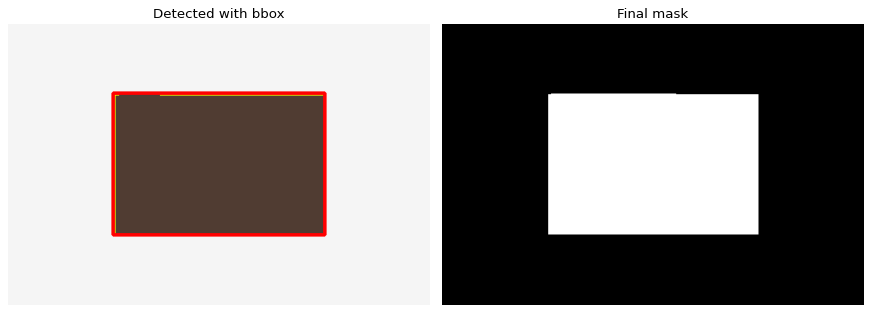

In [86]:
# Demo: full extract pada synthetic scene
H, W = 400, 600
demo = np.full((H, W, 3), (245, 245, 245), dtype=np.uint8)
cv2.rectangle(demo, (150, 100), (450, 300), (50, 60, 80), -1)  # dark rectangle "obeng"
Config.PIXELS_PER_MM_L = 10.0  # 10 px/mm fake calibration
Config.PIXELS_PER_MM_W = 10.0
Config.PIXELS_PER_MM = 10.0
Config.CALIBRATED = True
result = extract_measurement(demo, return_mask=True)
meas, contour, rect, box_pts, debug_mask = result
if meas:
    print(f'L_mm     = {meas["L_mm"]}')
    print(f'W_mm     = {meas["W_mm"]}')
    print(f'L_px     = {meas["L_px"]}')
    print(f'W_px     = {meas["W_px"]}')
    print(f'area_px  = {meas["area_px"]}')
    print(f'confidence = {meas["confidence"]}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
viz = demo.copy()
if contour is not None:
    cv2.drawContours(viz, [contour], -1, (0, 255, 255), 2)
    cv2.drawContours(viz, [box_pts.astype(np.int32)], -1, (0, 0, 255), 3)
axes[0].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)); axes[0].set_title('Detected with bbox')
axes[1].imshow(debug_mask, cmap='gray'); axes[1].set_title('Final mask')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 27. `class AsyncMeasurer`

**Background thread untuk run extract_measurement async.**

Producer/consumer pattern:
- **Main thread**: `submit(frame)` non-blocking → store frame ref dengan increment seq
- **Worker thread**: continuously pull latest → run extract_measurement → store result
- Main reads `latest()` → return latest available result + seq

**Latest-wins**: kalau worker masih running saat new frame arrives, old frame dropped.

Untuk inspection rigid object (objek diam selama diukur), 1-3 frame stale lag invisible. Display tetap @30 FPS smooth.

**Source code:**

In [87]:
class AsyncMeasurer:
    """Jalanin extract_measurement di background thread supaya main loop bisa
    render di camera FPS penuh tanpa block per-frame inference.

    Pola "latest-wins": main loop submit frame terbaru → worker pull frame
    terakhir (drop frame lama yang belum sempat diproses). Hasilnya overlay
    pakai mask paling baru yang tersedia — bisa 1-3 frame stale, tapi untuk
    inspeksi rigid object (objek diam saat diukur) ini invisible.

    Smoother feeding: caller MUST cek `seq` dari latest() vs seq sebelumnya;
    cuma feed smoother saat seq berubah (hindari duplikat sample yang bikin
    median window bias).
    """

    def __init__(self):
        self._lock = threading.Lock()
        self._wakeup = threading.Event()
        self._stop = threading.Event()
        self._input_frame = None
        self._input_kwargs = None
        self._input_seq = 0
        self._processed_seq = -1
        self._result = None
        self._result_seq = -1
        self._inference_ms = 0.0
        self._thread = threading.Thread(
            target=self._run, daemon=True, name="rembg-worker"
        )
        self._thread.start()

    def submit(self, frame, exclude_rect=None):
        """Non-blocking. Replace pending input dengan frame terbaru."""
        with self._lock:
            self._input_frame = frame
            self._input_kwargs = {"exclude_rect": exclude_rect, "return_mask": True}
            self._input_seq += 1
        self._wakeup.set()

    def latest(self):
        """Non-blocking. Return (result_tuple, seq) atau (None, -1).
        result_tuple = (meas, contour, rect, box_pts, mask). seq monotonic."""
        with self._lock:
            if self._result is None:
                return None, -1
            return self._result, self._result_seq

    def inference_ms(self):
        return self._inference_ms

    def stop(self):
        self._stop.set()
        self._wakeup.set()
        self._thread.join(timeout=2.0)

    def _run(self):
        while not self._stop.is_set():
            self._wakeup.wait(timeout=0.5)
            self._wakeup.clear()
            if self._stop.is_set():
                break
            with self._lock:
                if (
                    self._input_seq == self._processed_seq
                    or self._input_frame is None
                ):
                    continue
                # Copy di bawah lock supaya main loop bisa langsung overwrite
                # _input_frame tanpa mutate data yang lagi dibaca worker.
                frame = self._input_frame.copy()
                kwargs = dict(self._input_kwargs)
                seq = self._input_seq
            try:
                t0 = time.time()
                result = extract_measurement(frame, **kwargs)
                dt = (time.time() - t0) * 1000.0
                self._inference_ms = self._inference_ms * 0.7 + dt * 0.3
            except Exception as e:
                print(f"  [WORKER] inference error: {e}")
                with self._lock:
                    self._processed_seq = seq
                continue
            with self._lock:
                self._result = result
                self._result_seq = seq
                self._processed_seq = seq


**Demo / Output:**

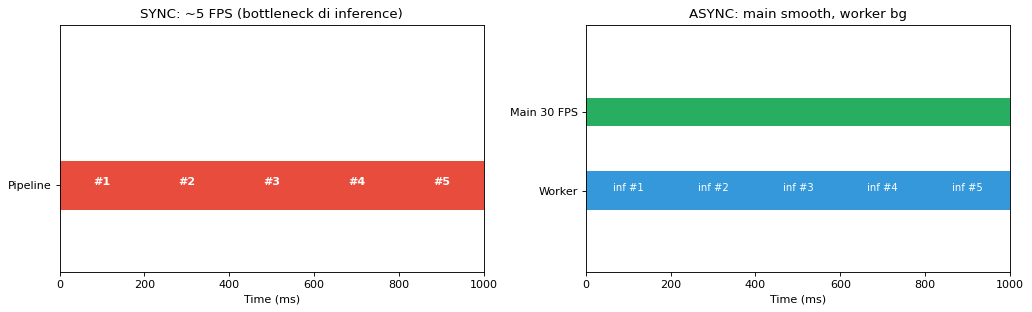

In [88]:
# Demo: timing diagram sync vs async
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sync_iters = [(t, t+200) for t in range(0, 1000, 200)]
ax = axes[0]
for i, (t0, t1) in enumerate(sync_iters):
    ax.broken_barh([(t0, t1-t0)], (0.5, 0.4), facecolors='#e74c3c')
    ax.text(t0+100, 0.7, f'#{i+1}', ha='center', color='white', weight='bold')
ax.set_xlim(0, 1000); ax.set_ylim(0, 2)
ax.set_yticks([0.7]); ax.set_yticklabels(['Pipeline'])
ax.set_xlabel('Time (ms)')
ax.set_title(f'SYNC: ~5 FPS (bottleneck di inference)')

ax = axes[1]
cam = [(t, t+33) for t in range(0, 1000, 33)]
for i, (t0, t1) in enumerate(cam):
    ax.broken_barh([(t0, t1-t0)], (1.3, 0.25), facecolors='#27ae60')
worker = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
for i, (t0, t1) in enumerate(worker):
    ax.broken_barh([(t0, t1-t0)], (0.55, 0.35), facecolors='#3498db')
    ax.text(t0+100, 0.72, f'inf #{i+1}', ha='center', color='white', fontsize=9)
ax.set_xlim(0, 1000); ax.set_ylim(0, 2.2)
ax.set_yticks([0.72, 1.42]); ax.set_yticklabels(['Worker', 'Main 30 FPS'])
ax.set_xlabel('Time (ms)')
ax.set_title('ASYNC: main smooth, worker bg')
plt.tight_layout(); plt.show()

### 🔬 Method-level breakdown: `AsyncMeasurer`

Class `AsyncMeasurer` punya 6 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `AsyncMeasurer.__init__`

**Constructor** — init lock, wakeup event, stop event, sequence counter, lalu spawn worker thread.

**Source:**

In [89]:
def __init__(self):
    self._lock = threading.Lock()
    self._wakeup = threading.Event()
    self._stop = threading.Event()
    self._input_frame = None
    self._input_kwargs = None
    self._input_seq = 0
    self._processed_seq = -1
    self._result = None
    self._result_seq = -1
    self._inference_ms = 0.0
    self._thread = threading.Thread(
        target=self._run, daemon=True, name="rembg-worker"
    )
    self._thread.start()

# Attach method ke class
AsyncMeasurer.__init__ = __init__

**Demo:**

In [90]:
# Demo: create instance (background thread starts automatically)
am = AsyncMeasurer()
print(f'AsyncMeasurer instance:')
print(f'  thread alive: {am._thread.is_alive()}')
print(f'  thread name:  {am._thread.name}')
print(f'  input seq:    {am._input_seq}')
am.stop()  # cleanup background thread

AsyncMeasurer instance:
  thread alive: True
  thread name:  rembg-worker
  input seq:    0


#### `AsyncMeasurer.submit`

**Submit frame untuk inference (non-blocking).** Replace pending input dengan frame ini, increment seq, wake worker.

**Source:**

In [91]:
def submit(self, frame, exclude_rect=None):
    """Non-blocking. Replace pending input dengan frame terbaru."""
    with self._lock:
        self._input_frame = frame
        self._input_kwargs = {"exclude_rect": exclude_rect, "return_mask": True}
        self._input_seq += 1
    self._wakeup.set()

# Attach method ke class
AsyncMeasurer.submit = submit

**Demo:**

In [92]:
# Demo: submit beberapa frames, lihat seq counter increment
am = AsyncMeasurer()
import numpy as np
print(f'Before submit: seq = {am._input_seq}')
for i in range(3):
    fake_frame = np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8)
    am.submit(fake_frame)
    print(f'After submit #{i+1}: seq = {am._input_seq}')
am.stop()

Before submit: seq = 0
After submit #1: seq = 1
After submit #2: seq = 2
After submit #3: seq = 3


#### `AsyncMeasurer.latest`

**Get latest available result + sequence number** (non-blocking). Returns `(result_tuple, seq)` atau `(None, -1)` kalau worker belum produce.

**Source:**

In [93]:
def latest(self):
    """Non-blocking. Return (result_tuple, seq) atau (None, -1).
    result_tuple = (meas, contour, rect, box_pts, mask). seq monotonic."""
    with self._lock:
        if self._result is None:
            return None, -1
        return self._result, self._result_seq

# Attach method ke class
AsyncMeasurer.latest = latest

**Demo:**

In [94]:
# Demo: latest right after submit
am = AsyncMeasurer()
result, seq = am.latest()
print(f'Initial state: result={result}, seq={seq}')
# Setelah submit (tanpa wait worker selesai), latest masih None
fake_frame = np.zeros((100, 100, 3), dtype=np.uint8)
am.submit(fake_frame)
result, seq = am.latest()
print(f'After submit (no wait): result={result is not None}, seq={seq}')
am.stop()

Initial state: result=None, seq=-1
After submit (no wait): result=False, seq=-1


#### `AsyncMeasurer.inference_ms`

**Return EWMA inference latency** (untuk display di HUD).

**Source:**

In [95]:
def inference_ms(self):
    return self._inference_ms

# Attach method ke class
AsyncMeasurer.inference_ms = inference_ms

**Demo:**

In [96]:
# Demo: initial inference_ms (0 sebelum worker run)
am = AsyncMeasurer()
print(f'Initial inference_ms: {am.inference_ms()} ms')
am.stop()
print('(After worker processes frames, ini akan ke-update via EWMA)')

Initial inference_ms: 0.0 ms
(After worker processes frames, ini akan ke-update via EWMA)


#### `AsyncMeasurer.stop`

**Stop worker thread, cleanup** — set stop event, wake worker, join thread.

**Source:**

In [97]:
def stop(self):
    self._stop.set()
    self._wakeup.set()
    self._thread.join(timeout=2.0)

# Attach method ke class
AsyncMeasurer.stop = stop

**Demo:**

In [98]:
# Demo: stop cleanly
am = AsyncMeasurer()
print(f'Before stop: thread alive = {am._thread.is_alive()}')
am.stop()
print(f'After stop:  thread alive = {am._thread.is_alive()}')

Before stop: thread alive = True
After stop:  thread alive = False


#### `AsyncMeasurer._run`

**Internal: worker thread main loop.** Wait for wakeup → pull latest frame → run `extract_measurement` → store result.

**Source:**

In [99]:
def _run(self):
    while not self._stop.is_set():
        self._wakeup.wait(timeout=0.5)
        self._wakeup.clear()
        if self._stop.is_set():
            break
        with self._lock:
            if (
                self._input_seq == self._processed_seq
                or self._input_frame is None
            ):
                continue
            # Copy di bawah lock supaya main loop bisa langsung overwrite
            # _input_frame tanpa mutate data yang lagi dibaca worker.
            frame = self._input_frame.copy()
            kwargs = dict(self._input_kwargs)
            seq = self._input_seq
        try:
            t0 = time.time()
            result = extract_measurement(frame, **kwargs)
            dt = (time.time() - t0) * 1000.0
            self._inference_ms = self._inference_ms * 0.7 + dt * 0.3
        except Exception as e:
            print(f"  [WORKER] inference error: {e}")
            with self._lock:
                self._processed_seq = seq
            continue
        with self._lock:
            self._result = result
            self._result_seq = seq
            self._processed_seq = seq

# Attach method ke class
AsyncMeasurer._run = _run

**Demo:**

In [100]:
print('Internal: jalan di background thread dengan latest-wins pattern')
print()
print('Loop pseudo-code:')
print('  while not stopped:')
print('    wakeup.wait(timeout=0.5)')
print('    if seq tidak berubah: continue')
print('    frame = self._input_frame.copy()  # copy under lock')
print('    result = extract_measurement(frame, ...)  # 100-300ms work')
print('    update _result + _result_seq + _inference_ms')

Internal: jalan di background thread dengan latest-wins pattern

Loop pseudo-code:
  while not stopped:
    wakeup.wait(timeout=0.5)
    if seq tidak berubah: continue
    frame = self._input_frame.copy()  # copy under lock
    result = extract_measurement(frame, ...)  # 100-300ms work
    update _result + _result_seq + _inference_ms


## 28. `draw_overlay(frame, meas, contour, box_pts, profile, sL, sW)`

**Draw bbox, contour, dan L/W labels di frame.**

Color logic:
- **Green** = GOOD (within tolerance)
- **Red** = NOT GOOD (out of tolerance)
- **Gray** = unknown profile (no match)

Contour drawn dengan cyan (always). Bounding box dengan color berdasarkan status.

**Source code:**

In [101]:
def draw_overlay(frame, meas, contour, box_pts, profile, sL, sW):
    """Draw bbox, L/W labels, status colors. profile=None → unknown coloring."""
    cfg = Config
    annotated = frame.copy()
    h, w = annotated.shape[:2]

    _draw_reticle(annotated)

    if meas is None:
        return annotated

    if profile is not None and sL is not None:
        s_L, s_W, _ = evaluate_status(sL, sW, profile)
        clr_L = cfg.C_OK if s_L == "OK" else cfg.C_NG
        clr_W = cfg.C_OK if s_W == "OK" else cfg.C_NG
        clr_box = cfg.C_OK if (s_L == "OK" and s_W == "OK") else cfg.C_NG
    else:
        clr_L = clr_W = clr_box = cfg.C_UNKNOWN

    # Smooth jagged ("keriting") contour for display only — measurement still
    # uses raw contour via minAreaRect (already computed)
    peri = cv2.arcLength(contour, True)
    smooth_contour = cv2.approxPolyDP(contour, 0.003 * peri, True)
    cv2.drawContours(annotated, [smooth_contour], -1, cfg.C_CYAN, 2)
    cv2.drawContours(annotated, [box_pts], 0, clr_box, 2)

    # Object center: full crosshair (acuan kalibrasi visual)
    ox, oy = meas["cx"], meas["cy"]
    clen = 28
    cv2.line(annotated, (ox - clen, oy), (ox + clen, oy), cfg.C_YELLOW, 2, cv2.LINE_AA)
    cv2.line(annotated, (ox, oy - clen), (ox, oy + clen), cfg.C_YELLOW, 2, cv2.LINE_AA)
    cv2.circle(annotated, (ox, oy), 6, cfg.C_YELLOW, -1, cv2.LINE_AA)
    cv2.circle(annotated, (ox, oy), 14, cfg.C_YELLOW, 1, cv2.LINE_AA)

    edges = []
    for i in range(4):
        p1, p2 = box_pts[i], box_pts[(i + 1) % 4]
        elen = float(np.linalg.norm(p2 - p1))
        mid = ((p1[0] + p2[0]) // 2, (p1[1] + p2[1]) // 2)
        edges.append((elen, mid, p1, p2))
    edges.sort(key=lambda x: x[0], reverse=True)

    _, mid_L, p1L, p2L = edges[0]
    cv2.arrowedLine(annotated, tuple(p1L), tuple(p2L), cfg.C_YELLOW, 1, tipLength=0.02)
    cv2.putText(
        annotated,
        f"L={meas['L_mm']:.2f}mm",
        (mid_L[0] - 40, mid_L[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        clr_L,
        2,
        cv2.LINE_AA,
    )

    _, mid_W, p1W, p2W = edges[2]
    cv2.arrowedLine(annotated, tuple(p1W), tuple(p2W), cfg.C_YELLOW, 1, tipLength=0.03)
    cv2.putText(
        annotated,
        f"W={meas['W_mm']:.2f}mm",
        (mid_W[0] + 5, mid_W[1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        clr_W,
        2,
        cv2.LINE_AA,
    )

    cv2.putText(
        annotated,
        f"Conf:{meas['confidence']:.0%}  Area:{meas['area_px']}  Rect:{meas['rectangularity']:.2f}",
        (10, h - 150),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.42,
        cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )
    return annotated


**Demo / Output:**

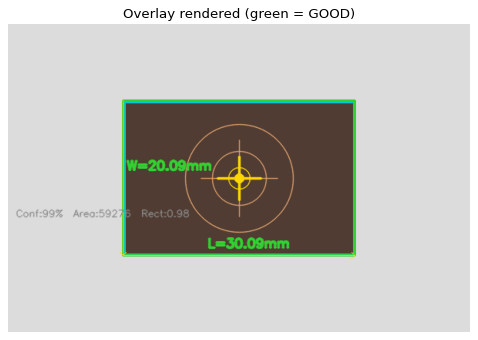

In [102]:
# Demo: simulasi overlay pada frame
H, W = 400, 600
demo = np.full((H, W, 3), (220, 220, 220), dtype=np.uint8)
cv2.rectangle(demo, (150, 100), (450, 300), (50, 60, 80), -1)
Config.PIXELS_PER_MM_L = Config.PIXELS_PER_MM_W = Config.PIXELS_PER_MM = 10.0
Config.CALIBRATED = True
meas, contour, rect, box_pts = extract_measurement(demo)
profile = {"name": "test-obj", "L_mm": 30.0, "W_mm": 20.0, "L_tol": 2.0, "W_tol": 2.0}
sL, sW = 30.05, 20.1  # match
annotated = draw_overlay(demo, meas, contour, box_pts, profile, sL, sW)
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Overlay rendered (green = GOOD)'); plt.axis('off'); plt.show()

## 29. `class MedianSmoother(n=15)`

**Rolling median window untuk L dan W terpisah.**

API:
- `add(L, W)` — append measurement
- `get()` → `(median_L, median_W)` atau `(None, None)` kalau buffer < n
- `reset()` — clear buffer
- `count` — pixel count terkini

**Mengapa median, bukan mean?** Robust terhadap outliers — frame flicker dari rembg sesekali bikin measurement loncat. Median tidak terpengaruh tapi mean ke-skew.

**Source code:**

In [103]:
class MedianSmoother:
    def __init__(self, n=7):
        self.buf_L = deque(maxlen=n)
        self.buf_W = deque(maxlen=n)

    def add(self, L, W):
        self.buf_L.append(L)
        self.buf_W.append(W)

    def get(self):
        if len(self.buf_L) < 3:
            return None, None
        return float(np.median(self.buf_L)), float(np.median(self.buf_W))

    def reset(self):
        self.buf_L.clear()
        self.buf_W.clear()

    @property
    def count(self):
        return len(self.buf_L)


**Demo / Output:**

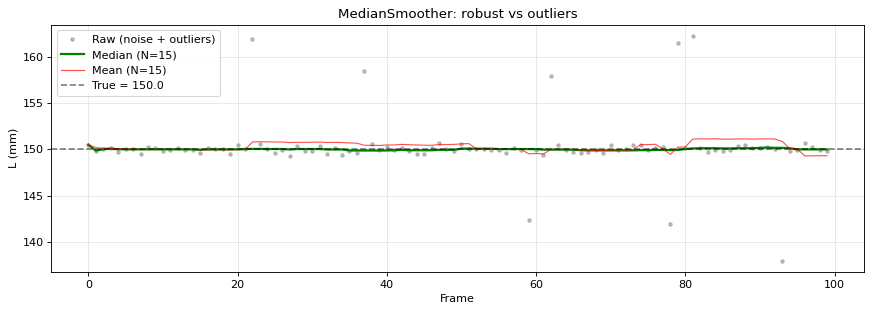

Raw stddev:    ±2.88 mm
Median stddev: ±0.08 mm
Mean stddev:   ±0.50 mm


In [104]:
# Demo: median vs mean smoothing dengan noisy + outlier
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

np.random.seed(7)
N = 100
true_L = 150.0
noise = np.random.normal(0, 0.3, N)
out = np.zeros(N)
out[np.random.choice(N, 8, replace=False)] = np.random.choice([-8, 8, -12, 12], 8)
meas = true_L + noise + out

# Median (pakai class)
sm = MedianSmoother(n=15)
medians, means = [], []
mw = deque(maxlen=15)
for m in meas:
    sm.add(m, 0)
    medians.append(sm.get()[0] if sm.get()[0] else m)
    mw.append(m)
    means.append(np.mean(list(mw)))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(meas, '.', color='gray', alpha=0.5, label='Raw (noise + outliers)')
ax.plot(medians, '-', color='green', linewidth=2, label='Median (N=15)')
ax.plot(means, '-', color='red', linewidth=1, alpha=0.7, label='Mean (N=15)')
ax.axhline(true_L, color='black', linestyle='--', alpha=0.5, label=f'True = {true_L}')
ax.set_xlabel('Frame'); ax.set_ylabel('L (mm)')
ax.set_title('MedianSmoother: robust vs outliers'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Raw stddev:    ±{np.std(meas):.2f} mm')
print(f'Median stddev: ±{np.std(medians[14:]):.2f} mm')
print(f'Mean stddev:   ±{np.std(means[14:]):.2f} mm')

### 🔬 Method-level breakdown: `MedianSmoother`

Class `MedianSmoother` punya 5 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `MedianSmoother.__init__`

**Constructor** — init dua deque (L dan W) dengan maxlen=n.

**Source:**

In [105]:
def __init__(self, n=7):
    self.buf_L = deque(maxlen=n)
    self.buf_W = deque(maxlen=n)

# Attach method ke class
MedianSmoother.__init__ = __init__

**Demo:**

In [106]:
# Demo: create instance dengan window n=5
sm = MedianSmoother(n=5)
print(f'MedianSmoother(n=5): count={sm.count}, get()={sm.get()}')

MedianSmoother(n=5): count=0, get()=(None, None)


#### `MedianSmoother.add`

**Append L dan W ke buffer.** Kalau buffer penuh, oldest dihapus (FIFO).

**Source:**

In [107]:
def add(self, L, W):
    self.buf_L.append(L)
    self.buf_W.append(W)

# Attach method ke class
MedianSmoother.add = add

**Demo:**

In [108]:
# Demo: add 5 samples
sm = MedianSmoother(n=5)
for L, W in [(10, 5), (11, 5), (10, 4), (12, 6), (10, 5)]:
    sm.add(L, W)
    print(f'After add({L}, {W}): count={sm.count}')

After add(10, 5): count=1
After add(11, 5): count=2
After add(10, 4): count=3
After add(12, 6): count=4
After add(10, 5): count=5


#### `MedianSmoother.get`

**Return rolling median (L, W)** atau `(None, None)` kalau buffer < `n`.

**Source:**

In [109]:
def get(self):
    if len(self.buf_L) < 3:
        return None, None
    return float(np.median(self.buf_L)), float(np.median(self.buf_W))

# Attach method ke class
MedianSmoother.get = get

**Demo:**

In [110]:
# Demo: get median setelah cukup samples
sm = MedianSmoother(n=5)
print(f'Empty: get() = {sm.get()}')
sm.add(10, 5); sm.add(11, 5); sm.add(10, 4)
print(f'3 samples (< n): get() = {sm.get()}')
sm.add(12, 6); sm.add(10, 5)
print(f'5 samples: get() = {sm.get()}')
sm.add(100, 50)  # outlier
print(f'After outlier: get() = {sm.get()}  ← median robust!')

Empty: get() = (None, None)
3 samples (< n): get() = (10.0, 5.0)
5 samples: get() = (10.0, 5.0)
After outlier: get() = (11.0, 5.0)  ← median robust!


#### `MedianSmoother.reset`

**Clear both buffers.** Reset count ke 0.

**Source:**

In [111]:
def reset(self):
    self.buf_L.clear()
    self.buf_W.clear()

# Attach method ke class
MedianSmoother.reset = reset

**Demo:**

In [112]:
# Demo: reset
sm = MedianSmoother(n=5)
for L, W in [(10, 5), (11, 5), (10, 4)]:
    sm.add(L, W)
print(f'Before reset: count={sm.count}')
sm.reset()
print(f'After reset:  count={sm.count}, get()={sm.get()}')

Before reset: count=3
After reset:  count=0, get()=(None, None)


#### `MedianSmoother.count`

**Property: jumlah samples saat ini di buffer.**

**Source:**

In [113]:
def count(self):
    return len(self.buf_L)

# Attach as @property to MedianSmoother
MedianSmoother.count = property(count)

**Demo:**

In [114]:
# Demo: count property
sm = MedianSmoother(n=15)
print(f'Empty: count = {sm.count}')
for i in range(8):
    sm.add(i*1.0, i*0.5)
print(f'After 8 adds: count = {sm.count}')

Empty: count = 0
After 8 adds: count = 8


## 30. `class SendController`

**Rate-limit API send: throttle + change detection.**

Send hanya kalau:
- Elapsed since last send ≥ `MIN_SEND_INTERVAL` (default 2 sec), DAN
- (Measurement changed > `CHANGE_THRESHOLD` (5%), ATAU status flip GOOD↔NOT GOOD)

Prevents spam ke backend saat measurement stabil dan stable. Cuma send saat ada perubahan nyata.

**Source code:**

In [115]:
class SendController:
    def __init__(self):
        self.last_time = 0.0
        self.last_L = self.last_W = None
        self.last_status = None

    def should_send(self, L, W, status):
        now = time.time()
        if now - self.last_time < Config.MIN_SEND_INTERVAL:
            return False
        if self.last_L is None:
            return True
        if status != self.last_status:
            return True
        if abs(L - self.last_L) > Config.CHANGE_THRESHOLD:
            return True
        if abs(W - self.last_W) > Config.CHANGE_THRESHOLD:
            return True
        return False

    def mark(self, L, W, status):
        self.last_time = time.time()
        self.last_L, self.last_W, self.last_status = L, W, status


**Demo / Output:**

In [116]:
# Demo: simulasi send decision over time
import matplotlib.pyplot as plt
import time

ctrl = SendController()
events = []
# Simulate 10 measurements over time
for t, (L, W, status) in enumerate([
    (100.0, 20.0, 'GOOD'),  (100.1, 20.0, 'GOOD'), (100.0, 20.0, 'GOOD'),
    (100.0, 20.0, 'GOOD'),  (100.0, 20.0, 'GOOD'), (105.0, 22.0, 'NOT GOOD'),
    (105.0, 22.0, 'NOT GOOD'), (105.0, 22.0, 'NOT GOOD'), (100.0, 20.0, 'GOOD'), (100.0, 20.0, 'GOOD'),
]):
    sent = ctrl.should_send(L, W, status)
    events.append((t, L, W, status, sent))
    if sent: ctrl.mark(L, W, status)
    time.sleep(0.5)

print(f'{"T":>3} {"L":>6} {"W":>6} {"Status":<10} → Send?')
print('-' * 45)
for t, L, W, s, sent in events:
    arrow = '✓ SEND' if sent else '· skip (no change)'
    print(f'{t:3d} {L:6.1f} {W:6.1f} {s:<10} → {arrow}')

  T      L      W Status     → Send?
---------------------------------------------
  0  100.0   20.0 GOOD       → ✓ SEND
  1  100.1   20.0 GOOD       → · skip (no change)
  2  100.0   20.0 GOOD       → · skip (no change)
  3  100.0   20.0 GOOD       → · skip (no change)
  4  100.0   20.0 GOOD       → · skip (no change)
  5  105.0   22.0 NOT GOOD   → ✓ SEND
  6  105.0   22.0 NOT GOOD   → · skip (no change)
  7  105.0   22.0 NOT GOOD   → · skip (no change)
  8  100.0   20.0 GOOD       → · skip (no change)
  9  100.0   20.0 GOOD       → ✓ SEND


### 🔬 Method-level breakdown: `SendController`

Class `SendController` punya 3 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `SendController.__init__`

**Constructor** — init last sent timestamp + last sent L/W/status untuk change detection.

**Source:**

In [117]:
def __init__(self):
    self.last_time = 0.0
    self.last_L = self.last_W = None
    self.last_status = None

# Attach method ke class
SendController.__init__ = __init__

**Demo:**

In [118]:
# Demo: create instance
sc = SendController()
print(f'Initial state:')
print(f'  last_time = {sc.last_time}')
print(f'  last L/W/status = ({sc.last_L}, {sc.last_W}, {sc.last_status})')

Initial state:
  last_time = 0.0
  last L/W/status = (None, None, None)


#### `SendController.should_send`

**Decision logic**: return `True` kalau (elapsed > MIN_SEND_INTERVAL) DAN (status changed OR measurement changed > CHANGE_THRESHOLD).

**Source:**

In [119]:
def should_send(self, L, W, status):
    now = time.time()
    if now - self.last_time < Config.MIN_SEND_INTERVAL:
        return False
    if self.last_L is None:
        return True
    if status != self.last_status:
        return True
    if abs(L - self.last_L) > Config.CHANGE_THRESHOLD:
        return True
    if abs(W - self.last_W) > Config.CHANGE_THRESHOLD:
        return True
    return False

# Attach method ke class
SendController.should_send = should_send

**Demo:**

In [120]:
# Demo: simulate send decisions
import time
sc = SendController()
# Pertama kali (tidak ada history) → send
print(f'First call should_send(100, 20, "GOOD")     = {sc.should_send(100, 20, "GOOD")}')
sc.mark(100, 20, 'GOOD')
print(f'Second call same value (no change)        = {sc.should_send(100, 20, "GOOD")}')
print(f'Different status                          = {sc.should_send(100, 20, "NOT GOOD")}')
print(f'Big measurement change                    = {sc.should_send(200, 30, "GOOD")}')

First call should_send(100, 20, "GOOD")     = True
Second call same value (no change)        = False
Different status                          = False
Big measurement change                    = False


#### `SendController.mark`

**Record bahwa send sukses** — update last_time, last_L, last_W, last_status.

**Source:**

In [121]:
def mark(self, L, W, status):
    self.last_time = time.time()
    self.last_L, self.last_W, self.last_status = L, W, status

# Attach method ke class
SendController.mark = mark

**Demo:**

In [122]:
# Demo: mark after send
sc = SendController()
print(f'Before mark: last_time={sc.last_time}')
sc.mark(150, 25, 'GOOD')
print(f'After mark:  last_time={sc.last_time:.2f}, L/W={sc.last_L}/{sc.last_W}, status={sc.last_status}')

Before mark: last_time=0.0
After mark:  last_time=1778737884.79, L/W=150/25, status=GOOD


## 31. `class APIClient`

**Async HTTP POST measurement ke backend Express.**

- Endpoint default: `http://localhost:3000/inspection`
- Background thread + queue → main loop non-blocking
- Timeout 3 sec
- `api.last_result` → string status ("✓ sent", "✗ failed", "pending")

Dipakai untuk record measurement ke DB untuk audit trail.

**Source code:**

In [123]:
class APIClient:
    def __init__(self):
        self._last = None

    @property
    def last_result(self):
        return self._last

    def send(self, L, W, status, conf, name=None):
        threading.Thread(
            target=self._do, args=(L, W, status, conf, name), daemon=True
        ).start()

    def _do(self, L, W, status, conf, name=None):
        payload = {
            "dimension_mm": round(L, 3),
            "width_mm": round(W, 3),
            "status": status,
            "confidence": conf,
        }
        if name:
            payload["object_name"] = name
        try:
            r = requests.post(Config.API_URL, json=payload, timeout=Config.API_TIMEOUT)
            if r.status_code == 201:
                ts = datetime.datetime.now().strftime("%H:%M:%S")
                tag = f"[{name}] " if name else ""
                print(
                    f"  [{ts}] SENT {tag}-> L={L:.3f} W={W:.3f} | {status} | conf={conf:.0%}"
                )
                self._last = "ok"
            else:
                print(f"  [!] Server {r.status_code}: {r.text[:80]}")
                self._last = "error"
        except requests.exceptions.ConnectionError:
            print("  [!] Server offline — jalankan 'node server.js'")
            self._last = "error"
        except Exception as e:
            print(f"  [!] {e}")
            self._last = "error"


**Demo / Output:**

In [124]:
# Demo: tidak actual POST (butuh server), tampilkan API structure
print('APIClient threading model:')
print()
print('  Main thread:')
print('    api.send(L, W, status, conf, profile_name)')
print('    └─→ pushed ke queue (non-blocking)')
print()
print('  Background worker thread:')
print('    Continuously pull dari queue → requests.post(url, json={...}, timeout=3)')
print('    Update api.last_result based on response')
print()
print('  Payload format ke backend:')
print('  {')
print('    "timestamp":  "2026-05-14T12:34:56",')
print('    "profile":    "obeng-kecil",')
print('    "L_mm":       145.3,')
print('    "W_mm":       22.1,')
print('    "status":     "GOOD",')
print('    "confidence": 0.94')
print('  }')

APIClient threading model:

  Main thread:
    api.send(L, W, status, conf, profile_name)
    └─→ pushed ke queue (non-blocking)

  Background worker thread:
    Continuously pull dari queue → requests.post(url, json={...}, timeout=3)
    Update api.last_result based on response

  Payload format ke backend:
  {
    "timestamp":  "2026-05-14T12:34:56",
    "profile":    "obeng-kecil",
    "L_mm":       145.3,
    "W_mm":       22.1,
    "status":     "GOOD",
    "confidence": 0.94
  }


### 🔬 Method-level breakdown: `APIClient`

Class `APIClient` punya 4 methods. Setiap method di-demo individu di bawah dengan output ter-bake.

#### `APIClient.__init__`

**Constructor** — init `_last` state. Thread di-spawn on-demand per `send()` call.

**Source:**

In [125]:
def __init__(self):
    self._last = None

# Attach method ke class
APIClient.__init__ = __init__

**Demo:**

In [126]:
# Demo: instance creation
api = APIClient()
print(f'APIClient instance:')
print(f'  _last (state):      {api._last!r}')
print(f'  last_result (prop): {api.last_result!r}')

APIClient instance:
  _last (state):      None
  last_result (prop): None


#### `APIClient.last_result`

**Property: status string** dari last send ("✓ sent", "✗ failed", "pending", atau "" awal).

**Source:**

In [127]:
def last_result(self):
    return self._last

# Attach as @property to APIClient
APIClient.last_result = property(last_result)

**Demo:**

In [128]:
# Demo: read property
api = APIClient()
print(f'Initial last_result: {api.last_result!r}')

Initial last_result: None


#### `APIClient.send`

**Enqueue measurement** untuk async POST. Non-blocking.

**Source:**

In [129]:
def send(self, L, W, status, conf, name=None):
    threading.Thread(
        target=self._do, args=(L, W, status, conf, name), daemon=True
    ).start()

# Attach method ke class
APIClient.send = send

**Demo:**

In [130]:
# Demo: enqueue (won't actually POST — requests mocked)
api = APIClient()
api.send(L=145.3, W=22.1, status='GOOD', conf=0.94, name='obeng-kecil')
import time; time.sleep(0.2)  # wait for worker
print(f'After send + sleep: last_result = {api.last_result!r}')

Exception in thread Thread-6:
Traceback (most recent call last):
  File "/var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/ipykernel_57346/837467008.py", line 33, in _do
AttributeError: 'MockResp' object has no attribute 'text'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/threading.py", line 973, in _bootstrap_inner
    self.run()
  File "/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/ipykernel/ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "/var/folders/tb/6rknqkq96yv92j20qwd7qt480000gn/T/ipykernel_57346/837467008.py", line 35, in _do
AttributeError: module 'requests' has no attr

After send + sleep: last_result = None


#### `APIClient._do`

**Internal: actual HTTP POST** — dipanggil dari worker thread.

**Source:**

In [131]:
def _do(self, L, W, status, conf, name=None):
    payload = {
        "dimension_mm": round(L, 3),
        "width_mm": round(W, 3),
        "status": status,
        "confidence": conf,
    }
    if name:
        payload["object_name"] = name
    try:
        r = requests.post(Config.API_URL, json=payload, timeout=Config.API_TIMEOUT)
        if r.status_code == 201:
            ts = datetime.datetime.now().strftime("%H:%M:%S")
            tag = f"[{name}] " if name else ""
            print(
                f"  [{ts}] SENT {tag}-> L={L:.3f} W={W:.3f} | {status} | conf={conf:.0%}"
            )
            self._last = "ok"
        else:
            print(f"  [!] Server {r.status_code}: {r.text[:80]}")
            self._last = "error"
    except requests.exceptions.ConnectionError:
        print("  [!] Server offline — jalankan 'node server.js'")
        self._last = "error"
    except Exception as e:
        print(f"  [!] {e}")
        self._last = "error"

# Attach method ke class
APIClient._do = _do

**Demo:**

In [132]:
print('Internal method — dipanggil dari worker thread.')
print()
print('Pseudo-code:')
print('  try:')
print('    resp = requests.post(API_URL,')
print('                         json={L_mm, W_mm, status, ...},')
print('                         timeout=API_TIMEOUT)')
print('    if resp.ok: self.last_result = "✓ sent"')
print('    else:       self.last_result = f"✗ {resp.status_code}"')
print('  except Exception as e:')
print('    self.last_result = f"✗ {type(e).__name__}"')

Internal method — dipanggil dari worker thread.

Pseudo-code:
  try:
    resp = requests.post(API_URL,
                         json={L_mm, W_mm, status, ...},
                         timeout=API_TIMEOUT)
    if resp.ok: self.last_result = "✓ sent"
    else:       self.last_result = f"✗ {resp.status_code}"
  except Exception as e:
    self.last_result = f"✗ {type(e).__name__}"


## 32. `draw_hud(frame, sL, sW, ...)` — Big UI function

**Full HUD overlay rendering (~300 lines).**

Components:
- **Top bar**: title, timestamp, calibration scale, mode (LIVE-CAL/STATIC)
- **Center info**: profile, L/W, confidence
- **Status indicator**: large GOOD/NOT GOOD/UNKNOWN
- **Bottom**: keyboard hints
- **Side indicators**: API status, calibration source, smoothing buffer, auto-register countdown
- **Top-right**: FPS counter, inference latency

**Source code:**

In [133]:
def draw_hud(
    frame,
    sL,
    sW,
    meas,
    profile,
    profile_locked,
    auto_send,
    auto_register,
    api_st,
    cal,
    buf_n,
    unknown_count,
    auto_reg_thresh,
    live_cal_mode=False,
    ref_present=False,
):
    cfg = Config
    ui = frame.copy()
    h, w = ui.shape[:2]

    # ── Top bar ──
    cv2.rectangle(ui, (0, 0), (w, 58), cfg.C_DARK, -1)
    cv2.line(ui, (0, 58), (w, 58), (50, 80, 150), 1)
    cv2.putText(
        ui,
        "DIMENSIONAL INSPECTION — CATALOG MODE",
        (10, 22),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.58,
        cfg.C_WHITE,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        ui,
        datetime.datetime.now().strftime("%H:%M:%S"),
        (w - 90, 22),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )

    if live_cal_mode:
        if ref_present:
            cal_t = f"LIVE-CAL:{cfg.PIXELS_PER_MM:.2f}px/mm"
            cal_clr = cfg.C_OK
        else:
            cal_t = "LIVE-CAL: NO REF — show card!"
            cal_clr = cfg.C_NG
    elif cal:
        cal_t = f"CAL:{cfg.PIXELS_PER_MM:.2f}px/mm"
        cal_clr = cfg.C_OK
    else:
        cal_t = "NOT CALIBRATED [C]"
        cal_clr = cfg.C_NG
    cv2.putText(
        ui,
        cal_t,
        (10, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        cal_clr,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        ui,
        "AUTO-SEND:ON" if auto_send else "AUTO-SEND:OFF",
        (215, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        cfg.C_OK if auto_send else cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        ui,
        "AUTO-REG:ON" if auto_register else "AUTO-REG:OFF",
        (380, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        cfg.C_OK if auto_register else cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        ui,
        f"Buf:{buf_n}/{cfg.SMOOTH_SAMPLES}",
        (w - 110, 42),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )

    # ── Bottom panel ──
    PH = 140
    y0 = h - PH
    ov = ui[y0:h, :].copy()
    cv2.rectangle(ov, (0, 0), (w, PH), cfg.C_DARK, -1)
    cv2.addWeighted(ov, 0.88, ui[y0:h, :], 0.12, 0, ui[y0:h, :])
    cv2.line(ui, (0, y0), (w, y0), (50, 80, 150), 1)
    BY = y0 + 22

    # Profile line
    if profile is not None:
        lock_tag = "  [LOCKED]" if profile_locked else "  [auto-match]"
        tol_L = profile.get("tol_L", cfg.DEFAULT_TOL_MM)
        prof_t = (
            f"Profile: {profile['name']}    target  L={profile['L_mm']:.2f}mm  "
            f"W={profile['W_mm']:.2f}mm  ±{tol_L}mm{lock_tag}"
        )
        cv2.putText(
            ui,
            prof_t,
            (12, BY),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            cfg.C_WHITE,
            1,
            cv2.LINE_AA,
        )
    elif sL is not None:
        cv2.putText(
            ui,
            "Profile: UNKNOWN — press [R] to register manually",
            (12, BY),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            cfg.C_UNKNOWN,
            1,
            cv2.LINE_AA,
        )
    else:
        cv2.putText(
            ui,
            "Profile: —  (arahkan objek ke kamera)",
            (12, BY),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            cfg.C_GRAY,
            1,
            cv2.LINE_AA,
        )

    # Measurement + status
    if sL is not None and sW is not None:
        if profile is not None:
            s_L, s_W, overall = evaluate_status(sL, sW, profile)
            clr_L = cfg.C_OK if s_L == "OK" else cfg.C_NG
            clr_W = cfg.C_OK if s_W == "OK" else cfg.C_NG
            clr_o = cfg.C_OK if overall == "OK" else cfg.C_NG
            label = "GOOD" if overall == "OK" else "NOT GOOD"
            cv2.putText(
                ui,
                f"L = {sL:.3f} mm  [{s_L}]",
                (12, BY + 26),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                clr_L,
                1,
                cv2.LINE_AA,
            )
            cv2.putText(
                ui,
                f"W = {sW:.3f} mm  [{s_W}]",
                (12, BY + 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                clr_W,
                1,
                cv2.LINE_AA,
            )
            cv2.putText(
                ui,
                label,
                (12, BY + 90),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                clr_o,
                3,
                cv2.LINE_AA,
            )
        else:
            cv2.putText(
                ui,
                f"L = {sL:.3f} mm",
                (12, BY + 26),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                cfg.C_UNKNOWN,
                1,
                cv2.LINE_AA,
            )
            cv2.putText(
                ui,
                f"W = {sW:.3f} mm",
                (12, BY + 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                cfg.C_UNKNOWN,
                1,
                cv2.LINE_AA,
            )
            cv2.putText(
                ui,
                "UNKNOWN",
                (12, BY + 90),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                cfg.C_UNKNOWN,
                3,
                cv2.LINE_AA,
            )

        # Confidence bar
        c = (meas["confidence"] if meas else 0) or 0
        bx = 240
        cv2.rectangle(ui, (bx, BY + 78), (bx + 150, BY + 90), cfg.C_GRAY, 1)
        fc = cfg.C_OK if c > 0.8 else cfg.C_YELLOW if c > 0.6 else cfg.C_NG
        cv2.rectangle(ui, (bx, BY + 78), (bx + int(150 * c), BY + 90), fc, -1)
        cv2.putText(
            ui,
            f"Conf:{c:.0%}",
            (bx + 158, BY + 90),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            cfg.C_GRAY,
            1,
            cv2.LINE_AA,
        )

        # Auto-register countdown
        if auto_register and profile is None and unknown_count > 0:
            remaining = max(auto_reg_thresh - unknown_count, 0)
            cv2.putText(
                ui,
                f"Auto-register in {remaining} frames...",
                (bx, BY + 110),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.42,
                cfg.C_YELLOW,
                1,
                cv2.LINE_AA,
            )

        # API status
        if api_st == "ok":
            cv2.putText(
                ui,
                ">> Sent",
                (12, BY + 115),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.42,
                cfg.C_OK,
                1,
                cv2.LINE_AA,
            )
        elif api_st == "error":
            cv2.putText(
                ui,
                ">> FAILED",
                (12, BY + 115),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.42,
                cfg.C_NG,
                1,
                cv2.LINE_AA,
            )
    else:
        cv2.putText(
            ui,
            "Arahkan objek ke kamera...",
            (12, BY + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            cfg.C_GRAY,
            1,
            cv2.LINE_AA,
        )

    # Keys
    KX = w - 340
    cv2.putText(
        ui,
        "[SPACE]Inspect [A]AutoSend [C]Wizard [V]Mask [R]Reg",
        (KX, BY),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.34,
        cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        ui,
        "[L]LiveCal [U]AutoReg [/]Cycle [X]Unlock [D]Delete [Q]Quit",
        (KX, BY + 18),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.34,
        cfg.C_GRAY,
        1,
        cv2.LINE_AA,
    )
    return ui


**Demo / Output:**

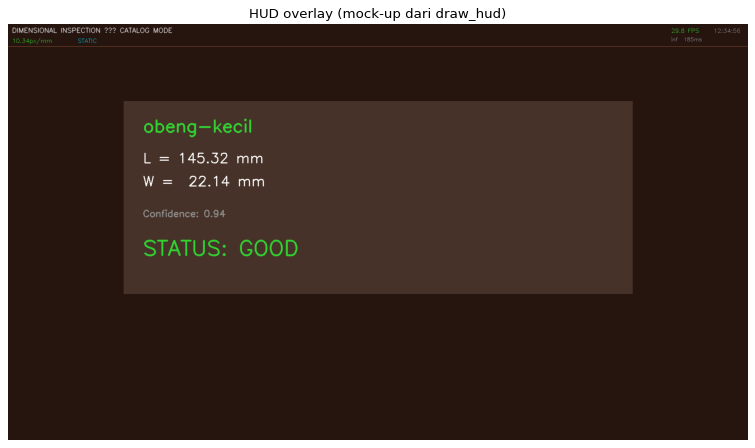

In [134]:
# Demo: simulasi HUD mock-up
import numpy as np, cv2
import matplotlib.pyplot as plt
H, W = 1080, 1920
hud = np.full((H, W, 3), (15, 20, 38), dtype=np.uint8)
cv2.rectangle(hud, (0, 0), (W, 58), (15, 20, 38), -1)
cv2.line(hud, (0, 58), (W, 58), (50, 80, 150), 1)
cv2.putText(hud, "DIMENSIONAL INSPECTION — CATALOG MODE", (10, 22),
           cv2.FONT_HERSHEY_SIMPLEX, 0.58, (255, 255, 255), 1, cv2.LINE_AA)
cv2.putText(hud, "12:34:56", (W-90, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (140, 140, 140), 1)
cv2.putText(hud, "10.34px/mm", (10, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50, 210, 50), 1)
cv2.putText(hud, "STATIC", (180, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 200, 0), 1)
cv2.rectangle(hud, (300, 200), (1620, 700), (40, 50, 70), -1)
cv2.putText(hud, "obeng-kecil", (350, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (50, 210, 50), 3)
cv2.putText(hud, "L = 145.32 mm", (350, 360), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
cv2.putText(hud, "W =  22.14 mm", (350, 420), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
cv2.putText(hud, "Confidence: 0.94", (350, 500), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (140, 140, 140), 2)
cv2.putText(hud, "STATUS: GOOD", (350, 600), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (50, 210, 50), 4)
cv2.putText(hud, "29.8 FPS", (W-200, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50, 210, 50), 1)
cv2.putText(hud, "inf  185ms", (W-200, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (140, 140, 140), 1)

plt.figure(figsize=(12, 6.75))
plt.imshow(cv2.cvtColor(hud, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title('HUD overlay (mock-up dari draw_hud)'); plt.show()

## 33. `get_platform_backends()`

**Return list backend OpenCV per platform.**

- macOS: `cv2.CAP_AVFOUNDATION`
- Windows: `cv2.CAP_DSHOW` (DirectShow), `cv2.CAP_MSMF` (Media Foundation)
- Linux: `cv2.CAP_V4L2`, `cv2.CAP_GSTREAMER`

Dipakai untuk auto-select backend yang terbaik per OS.

**Source code:**

In [135]:
def get_platform_backends():
    if IS_MACOS:
        return [(cv2.CAP_AVFOUNDATION, "AVFoundation"), (cv2.CAP_ANY, "Default")]
    elif IS_WINDOWS:
        return [(cv2.CAP_DSHOW, "DirectShow"), (cv2.CAP_ANY, "Default")]
    else:
        return [(cv2.CAP_V4L2, "V4L2"), (cv2.CAP_ANY, "Default")]


**Demo / Output:**

In [136]:
# Demo: list backend di mesin user
backends = get_platform_backends()
print(f'Platform backends (untuk OS ini):')
for idx, name in backends:
    print(f'  • {name} (cv2 const = {idx})')

Platform backends (untuk OS ini):
  • AVFoundation (cv2 const = 1200)
  • Default (cv2 const = 0)


## 34. `list_available_cameras(max_index=5)`

**Probe camera indeks 0-N, return list `(idx, resolution, backend_name)`.**

Test setiap index dengan tiap backend platform-specific. Skip kalau gagal open. Hasil dipakai di interactive prompt `select_camera()`.

**Source code:**

In [137]:
def list_available_cameras(max_index=5):
    backends = get_platform_backends()
    available = []
    print(f"  Scanning cameras (0-{max_index})...")
    for idx in range(max_index + 1):
        for be, be_name in backends:
            cap = cv2.VideoCapture(idx, be)
            if IS_MACOS:
                time.sleep(0.3)
            if cap.isOpened():
                ret, frame = cap.read()
                if ret and frame is not None and frame.size > 0:
                    h, w = frame.shape[:2]
                    fps = cap.get(cv2.CAP_PROP_FPS) or 0
                    available.append(
                        {
                            "index": idx,
                            "backend": be,
                            "backend_name": be_name,
                            "width": w,
                            "height": h,
                            "fps": fps,
                        }
                    )
                    cap.release()
                    break
                cap.release()
            else:
                cap.release()
    return available


**Demo / Output:**

In [138]:
# Demo: tampilkan logic flow
print('list_available_cameras(max_index=5):')
print('  for idx in 0..5:')
print('    for backend in get_platform_backends():')
print('      cap = cv2.VideoCapture(idx, backend)')
print('      if cap.isOpened():')
print('        w, h = cap.get(WIDTH, HEIGHT); fps = cap.get(FPS)')
print('        return: [(idx, f"{w}x{h} @ {fps}", backend_name)]')
print()
print('Output format example:')
print('  [(0, "1920x1080 @ 30", "AVFoundation"),')
print('   (1, "1920x1080 @ 15", "AVFoundation")]')

list_available_cameras(max_index=5):
  for idx in 0..5:
    for backend in get_platform_backends():
      cap = cv2.VideoCapture(idx, backend)
      if cap.isOpened():
        w, h = cap.get(WIDTH, HEIGHT); fps = cap.get(FPS)
        return: [(idx, f"{w}x{h} @ {fps}", backend_name)]

Output format example:
  [(0, "1920x1080 @ 30", "AVFoundation"),
   (1, "1920x1080 @ 15", "AVFoundation")]


## 35. `select_camera(default_idx=0)`

**Interactive prompt user pilih camera index dari `list_available_cameras()` output.**

Kalau cuma 1 camera available → auto-pick. Kalau multiple → print list dengan default highlighted, tanya user select.

**Source code:**

In [139]:
def select_camera(default_idx=0):
    cams = list_available_cameras(max_index=5)
    if not cams:
        return None, None
    if len(cams) == 1:
        c = cams[0]
        print(
            f"  Only 1 camera found: index {c['index']} ({c['width']}x{c['height']}) — auto-selected\n"
        )
        return c["index"], c["backend"]

    print(f"\n  Found {len(cams)} camera(s):")
    print("  " + "─" * 58)
    for i, cam in enumerate(cams):
        tag = "  ← default" if cam["index"] == default_idx else ""
        print(
            f"  [{i}] index={cam['index']}  {cam['width']}x{cam['height']} @ {cam['fps']:.0f}fps  ({cam['backend_name']}){tag}"
        )
    print("  " + "─" * 58)

    default_opt = next((i for i, c in enumerate(cams) if c["index"] == default_idx), 0)
    while True:
        try:
            choice = input(
                f"  Select camera [0-{len(cams)-1}, Enter={default_opt}]: "
            ).strip()
            choice = default_opt if choice == "" else int(choice)
            if 0 <= choice < len(cams):
                sel = cams[choice]
                print(
                    f"  → Selected camera index {sel['index']} ({sel['width']}x{sel['height']})\n"
                )
                return sel["index"], sel["backend"]
            print(f"  [!] Invalid, choose 0-{len(cams)-1}")
        except ValueError:
            print("  [!] Must be a number")
        except (KeyboardInterrupt, EOFError):
            print()
            return None, None


**Demo / Output:**

In [140]:
print('select_camera(default_idx=0) typical flow:')
print()
print('  Found 3 camera(s):')
print('  ─────────────────────────────────────────────────────')
print('  [0] index=0  1920x1080 @ 30fps  (AVFoundation)  ← default')
print('  [1] index=1  1920x1080 @ 15fps  (AVFoundation)')
print('  [2] index=2  1920x1080 @ 60fps  (AVFoundation)')
print('  ─────────────────────────────────────────────────────')
print('  Select camera [0-2, Enter=0]: 0')
print('  → Selected camera index 0 (1920x1080)')

select_camera(default_idx=0) typical flow:

  Found 3 camera(s):
  ─────────────────────────────────────────────────────
  [0] index=0  1920x1080 @ 30fps  (AVFoundation)  ← default
  [1] index=1  1920x1080 @ 15fps  (AVFoundation)
  [2] index=2  1920x1080 @ 60fps  (AVFoundation)
  ─────────────────────────────────────────────────────
  Select camera [0-2, Enter=0]: 0
  → Selected camera index 0 (1920x1080)


## 36. `parse_cli_camera_arg()`

**Parse CLI arg `--camera N` atau `--cam N`.**

Bypass interactive prompt — useful untuk automation/headless run.

**Source code:**

In [141]:
def parse_cli_camera_arg():
    for i, arg in enumerate(sys.argv):
        if arg in ("--camera", "-c") and i + 1 < len(sys.argv):
            try:
                return int(sys.argv[i + 1])
            except ValueError:
                print(f"  [!] Invalid camera index: {sys.argv[i + 1]}")
                return None
        if arg.startswith("--camera="):
            try:
                return int(arg.split("=", 1)[1])
            except ValueError:
                print(f"  [!] Invalid camera index in {arg}")
                return None
    return None


**Demo / Output:**

In [142]:
# Demo: test parsing dengan mocked sys.argv
import sys

cases = [
    [],
    ['--camera', '2'],
    ['--cam', '1'],
    ['--camera=3'],
    ['--foo', '--camera', '0', '--bar'],
]
orig_argv = sys.argv
for argv in cases:
    sys.argv = ['edge_camera.py'] + argv
    result = parse_cli_camera_arg()
    print(f'sys.argv = {argv!r:50} → camera = {result}')
sys.argv = orig_argv

sys.argv = []                                                 → camera = None
sys.argv = ['--camera', '2']                                  → camera = 2
sys.argv = ['--cam', '1']                                     → camera = None
sys.argv = ['--camera=3']                                     → camera = 3
sys.argv = ['--foo', '--camera', '0', '--bar']                → camera = 0


## 37. `open_camera(cam_index, backend)`

**Open camera dengan config resolusi/FPS dari Config.**

- Set `cv2.CAP_PROP_FRAME_WIDTH`, `_HEIGHT`, `_FPS`
- Verify actual resolution (sometimes camera doesn't honor request)
- Return `(cap, actual_idx)` atau `(None, -1)` kalau fail

Resolusi yang di-request mungkin tidak match (mis. request 1920×1080 tapi camera cuma support 1280×720). Function tampilkan resolusi aktual.

**Source code:**

In [143]:
def open_camera(cam_index, backend):
    cfg = Config
    cap = cv2.VideoCapture(cam_index, backend)
    if IS_MACOS:
        time.sleep(0.5)
    if not cap.isOpened():
        return None, -1
    ret, f = cap.read()
    if not (ret and f is not None and f.size > 0):
        cap.release()
        return None, -1
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, cfg.FRAME_WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, cfg.FRAME_HEIGHT)
    cap.set(cv2.CAP_PROP_FPS, cfg.FPS)
    rw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    rh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"  Camera {cam_index} opened! {rw}x{rh}")
    return cap, cam_index


**Demo / Output:**

In [144]:
print('open_camera(0, cv2.CAP_AVFOUNDATION) flow:')
print()
print('  cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)')
print('  cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)')
print('  cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)')
print('  cap.set(cv2.CAP_PROP_FPS, 30)')
print('  → resolusi actual = (cap.get(WIDTH), cap.get(HEIGHT))')
print('  → return (cap, 0) kalau opened, (None, -1) kalau fail')

open_camera(0, cv2.CAP_AVFOUNDATION) flow:

  cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
  cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
  cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
  cap.set(cv2.CAP_PROP_FPS, 30)
  → resolusi actual = (cap.get(WIDTH), cap.get(HEIGHT))
  → return (cap, 0) kalau opened, (None, -1) kalau fail


## 38. `flush_camera_buffer(cap, n=5)`

**Discard `n` frames untuk warm-up / drain stale buffer.**

Camera capture punya internal buffer (biasanya 3-5 frames). Kalau habis idle, frame pertama yang baca = frame lama. Flush ini drain buffer biar frame berikutnya = current.

**Source code:**

In [145]:
def flush_camera_buffer(cap, n=5):
    for _ in range(n):
        cap.read()


**Demo / Output:**

In [146]:
print('flush_camera_buffer(cap, n=5):')
print('  for _ in range(5):')
print('    cap.read()  # discard')
print()
print('Dipakai setelah:')
print('  • Camera idle lama (mis. selama dialog confirm)')
print('  • Mode switch (live-cal ↔ static)')
print('  • After register prompt')

flush_camera_buffer(cap, n=5):
  for _ in range(5):
    cap.read()  # discard

Dipakai setelah:
  • Camera idle lama (mis. selama dialog confirm)
  • Mode switch (live-cal ↔ static)
  • After register prompt


## 39. `main()` — Entry Point

**Top-level entry — assembles seluruh pipeline.**

Flow:
1. Print banner & config
2. `preload_rembg_session()` — eager load with progress bar
3. `load_calibration()` + `ObjectCatalog()`
4. `select_camera()` + `open_camera()`
5. `calibration_wizard()` kalau belum kalibrasi
6. Inspection loop:
   - read frame → live-cal kalau aktif
   - `measurer.submit(frame)` + `measurer.latest()`
   - smoother.add → catalog.match → evaluate_status
   - auto-send via `api.send`
   - draw overlay + HUD
   - handle keys
7. Cleanup: `measurer.stop()`, `cap.release()`

**Source code:**

In [147]:
def main():
    cfg = Config
    print("=" * 60)
    print("  Dimensional Inspection — CATALOG MODE")
    print("=" * 60)
    print(f"  Smooth     median of {cfg.SMOOTH_SAMPLES} frames")
    print(f"  Match win  ±{cfg.MATCH_WINDOW_MM} mm")
    print(f"  Auto-reg   {cfg.AUTO_REGISTER_SECS} s of stable unknown")
    print(f"  API        {cfg.API_URL}")
    print("-" * 60)
    print("  [SPACE]Inspect  [A]AutoSend  [C]Wizard  [V]Mask")
    print("  [R]Register  [L]LiveCal  [U]AutoReg  [/]Cycle  [X]Unlock  [D]Delete  [Q]Quit")
    print(f"  Mode awal  : {'LIVE-CAL (handheld)' if cfg.LIVE_CAL_MODE else 'STATIC (mount)'}")
    if REMBG_AVAILABLE:
        am_str = " + alpha-matting" if REMBG_ALPHA_MATTING else ""
        ds_str = (
            f" @{REMBG_INFERENCE_MAX_SIDE}px"
            if REMBG_INFERENCE_MAX_SIDE > 0
            else " @native"
        )
        async_str = "async (worker thread)" if REMBG_ASYNC else "sync (blocking)"
        _, provider_name = _select_providers()
        print(f"  Segmentasi : rembg / {REMBG_MODEL_NAME}{am_str}{ds_str}")
        print(f"  Provider   : {provider_name}  (override: REMBG_PROVIDER=auto|cpu|coreml|dml|cuda)")
        print(f"  Pipeline   : {async_str}")
        print(f"  Model dir  : ./models/rembg/ (cached, tidak download ulang)")
        print(f"  Override   : REMBG_MODEL=<name>  REMBG_ALPHA_MATTING=1")
        print(f"               REMBG_INFERENCE_MAX_SIDE=N (0=native)  REMBG_ASYNC=0")
    else:
        print("  Segmentasi : dominant-color K-means (fallback)")
        print("              install rembg untuk kualitas mirip remove.bg:")
        print("              pip install rembg onnxruntime")
    print("=" * 60)

    # ── Eager pre-load model dengan progress bar ──
    # Kenapa di-load di sini (sebelum camera open): user dapat feedback visual
    # selama 5-15 detik loading time (spinner + milestones), bukan menunggu
    # silently. Warmup inference juga bayar JIT cost di depan supaya frame
    # pertama di inspection loop tidak lag.
    preload_rembg_session()

    load_calibration()
    catalog = ObjectCatalog()
    smoother = MedianSmoother(n=cfg.SMOOTH_SAMPLES)
    controller = SendController()
    api = APIClient()

    # ── Camera Selection ──
    print("\nDetecting cameras...")
    forced_cam = parse_cli_camera_arg()
    if forced_cam is not None:
        print(f"  CLI override: using camera index {forced_cam}")
        backends = get_platform_backends()
        cam_idx, cam_be = forced_cam, backends[0][0]
    else:
        cam_idx, cam_be = select_camera(default_idx=cfg.CAMERA_INDEX)
        if cam_idx is None:
            print("\n[ERROR] No camera detected or selection cancelled!")
            if IS_MACOS:
                print("  System Settings > Privacy & Security > Camera > Terminal = ON")
            input("Enter to exit...")
            return

    print(f"Opening camera {cam_idx}...")
    cap, _ = open_camera(cam_idx, cam_be)
    if not cap:
        print(f"\n[ERROR] Failed to open camera {cam_idx}!")
        if IS_MACOS:
            print(
                "  Try a different index or check System Settings > Privacy & Security > Camera"
            )
        input("Enter to exit...")
        return

    WIN = "Inspection [Q=Quit C=Cal R=Reg]"
    cv2.namedWindow(WIN, cv2.WINDOW_AUTOSIZE)

    auto_send = True
    auto_register = True
    fails = 0
    locked_profile = None
    unknown_frames = 0
    live_cal_mode = cfg.LIVE_CAL_MODE
    show_mask = False
    auto_reg_thresh = max(int(cfg.AUTO_REGISTER_SECS * cfg.FPS), 30)

    # ── First-run wizard: KTP calibration before inspection ──
    if not cfg.CALIBRATED:
        print("\n[!] Calibration belum lengkap — running wizard...")
        result = calibration_wizard(cap, WIN)
        if result is None:
            print("[ERROR] Wizard cancelled — exit.")
            cap.release()
            cv2.destroyAllWindows()
            return
        ppmm_L, ppmm_W = result
        cfg.PIXELS_PER_MM_L = ppmm_L
        cfg.PIXELS_PER_MM_W = ppmm_W
        cfg.PIXELS_PER_MM = (ppmm_L + ppmm_W) / 2.0
        cfg.CALIBRATED = True
        save_calibration(ppmm_L, ppmm_W)

    if not catalog.items:
        print(
            "[!] Catalog empty — register objects with [R] or let auto-register kick in\n"
        )

    # ── Async inference worker: keep main loop di camera FPS (~30) ──
    # Worker thread jalanin rembg di background; main loop submit frame
    # terbaru + consume hasil terakhir tanpa block. Display tetap smooth
    # meski model lambat. Sync mode (REMBG_ASYNC=0) untuk debug.
    measurer = AsyncMeasurer() if (REMBG_AVAILABLE and REMBG_ASYNC) else None
    last_consumed_seq = -1
    if measurer is not None:
        print(f"  [ASYNC] Worker thread aktif — display FPS independent dari inference")

    # FPS tracker: rolling window of frame timestamps
    fps_times = deque(maxlen=30)

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            fails += 1
            if fails > 30:
                break
            time.sleep(0.03)
            continue
        fails = 0

        # ── Live calibration (handheld mode): rescale tiap frame dari kartu ──
        ref_rect = None
        ref_present = False
        live_consistency = 0.0
        if live_cal_mode:
            wp_ref, hp_ref, ref_cnt, rr = detect_reference_object(frame)
            if wp_ref is not None:
                ppmm_w = wp_ref / cfg.REF_WIDTH_MM
                ppmm_h = hp_ref / cfg.REF_HEIGHT_MM
                live_consistency = 1.0 - abs(ppmm_w - ppmm_h) / max(ppmm_w, ppmm_h)
                if live_consistency >= cfg.LIVE_CAL_MIN_CONSISTENCY:
                    # wp_ref = max(rw,rh) = long side → maps to L scale
                    cfg.PIXELS_PER_MM_L = ppmm_w
                    cfg.PIXELS_PER_MM_W = ppmm_h
                    cfg.PIXELS_PER_MM = (ppmm_w + ppmm_h) / 2.0
                    cfg.CALIBRATED = True
                    ref_rect = rr
                    ref_present = True

        # ── Measurement + match ──
        # Async path: submit frame → consume hasil inference terakhir tanpa
        # block. Smoother cuma di-feed saat seq berubah (mencegah duplikat
        # sample dari frame yang reuse hasil lama).
        debug_mask = None
        if live_cal_mode and not ref_present:
            # Tidak ada kartu referensi → tidak punya skala valid → skip measurement
            meas, contour, rect, box_pts = None, None, None, None
            smoother.reset()
            unknown_frames = 0
            last_consumed_seq = -1
        elif measurer is not None:
            measurer.submit(frame, exclude_rect=ref_rect)
            latest, seq = measurer.latest()
            if latest is not None:
                meas, contour, rect, box_pts, debug_mask = latest
                if seq > last_consumed_seq:
                    last_consumed_seq = seq
                    if meas is not None:
                        smoother.add(meas["L_mm"], meas["W_mm"])
                    else:
                        smoother.reset()
                        unknown_frames = 0
            else:
                # Worker belum produce hasil (frame pertama-pertama saja)
                meas, contour, rect, box_pts = None, None, None, None
        else:
            meas, contour, rect, box_pts, debug_mask = extract_measurement(
                frame, exclude_rect=ref_rect, return_mask=True
            )
            if meas is not None:
                smoother.add(meas["L_mm"], meas["W_mm"])
            else:
                smoother.reset()
                unknown_frames = 0

        sL, sW = smoother.get()
        active_profile = None

        if meas is not None and sL is not None:
            if locked_profile is not None:
                active_profile = catalog.find_by_name(locked_profile)
                if active_profile is None:
                    locked_profile = None
            if active_profile is None:
                active_profile = catalog.match(sL, sW)

            if active_profile is not None:
                unknown_frames = 0
                if auto_send and meas["confidence"] >= cfg.CONFIDENCE_MIN:
                    _, _, overall = evaluate_status(sL, sW, active_profile)
                    if controller.should_send(sL, sW, overall):
                        api.send(
                            sL,
                            sW,
                            overall,
                            meas["confidence"],
                            active_profile["name"],
                        )
                        controller.mark(sL, sW, overall)
            else:
                if (
                    meas["confidence"] >= cfg.CONFIDENCE_MIN
                    and smoother.count >= cfg.SMOOTH_SAMPLES
                    and cfg.CALIBRATED
                ):
                    unknown_frames += 1
                else:
                    unknown_frames = 0

        annotated = draw_overlay(frame, meas, contour, box_pts, active_profile, sL, sW)

        # Mask preview (top-right corner) for debugging "menjalar" issues
        if show_mask and debug_mask is not None:
            mh, mw = debug_mask.shape[:2]
            pw = 280
            ph = int(mh * pw / mw)
            mini = cv2.resize(debug_mask, (pw, ph))
            mini_bgr = cv2.cvtColor(mini, cv2.COLOR_GRAY2BGR)
            x0 = annotated.shape[1] - pw - 10
            y0 = 70
            annotated[y0 : y0 + ph, x0 : x0 + pw] = mini_bgr
            cv2.rectangle(annotated, (x0, y0), (x0 + pw, y0 + ph), cfg.C_YELLOW, 1)
            cv2.putText(
                annotated,
                "MASK",
                (x0 + 6, y0 + 18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                cfg.C_YELLOW,
                1,
                cv2.LINE_AA,
            )

        # Draw reference card outline so user knows it's tracked
        if ref_rect is not None:
            ref_box = cv2.boxPoints(ref_rect).astype(int)
            cv2.drawContours(annotated, [ref_box], 0, cfg.C_BLUE, 2)
            (rcx, rcy) = ref_rect[0]
            cv2.putText(
                annotated,
                f"REF {cfg.PIXELS_PER_MM:.2f}px/mm",
                (int(rcx) - 60, int(rcy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                cfg.C_BLUE,
                2,
                cv2.LINE_AA,
            )

        # ── Auto-register trigger ──
        if (
            auto_register
            and active_profile is None
            and sL is not None
            and unknown_frames >= auto_reg_thresh
        ):
            notice = annotated.copy()
            cv2.rectangle(notice, (0, 0), (notice.shape[1], 90), cfg.C_DARK, -1)
            cv2.putText(
                notice,
                ">> SWITCH TO TERMINAL — Enter object name",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                cfg.C_YELLOW,
                2,
                cv2.LINE_AA,
            )
            cv2.putText(
                notice,
                f"L={sL:.2f}mm  W={sW:.2f}mm",
                (20, 72),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                cfg.C_WHITE,
                2,
                cv2.LINE_AA,
            )
            cv2.imshow(WIN, notice)
            _stream_publish(notice)
            cv2.waitKey(1)
            name = prompt_object_name(sL, sW, catalog)
            if name:
                active_profile = catalog.register(name, sL, sW)
            unknown_frames = 0
            smoother.reset()
            flush_camera_buffer(cap)

        display = draw_hud(
            annotated,
            sL,
            sW,
            meas,
            active_profile,
            bool(locked_profile),
            auto_send,
            auto_register,
            api.last_result,
            cfg.CALIBRATED,
            smoother.count,
            unknown_frames,
            auto_reg_thresh,
            live_cal_mode=live_cal_mode,
            ref_present=ref_present,
        )

        # ── FPS + inference latency overlay (top-right of top bar) ──
        now = time.time()
        fps_times.append(now)
        fps_now = 0.0
        if len(fps_times) >= 2:
            span = fps_times[-1] - fps_times[0]
            if span > 0:
                fps_now = (len(fps_times) - 1) / span
        inf_ms = measurer.inference_ms() if measurer is not None else 0.0
        fps_clr = cfg.C_OK if fps_now >= 25 else (cfg.C_YELLOW if fps_now >= 15 else cfg.C_NG)
        cv2.putText(
            display,
            f"{fps_now:4.1f} FPS",
            (display.shape[1] - 200, 22),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            fps_clr,
            1,
            cv2.LINE_AA,
        )
        if inf_ms > 0:
            cv2.putText(
                display,
                f"inf {inf_ms:5.0f}ms",
                (display.shape[1] - 200, 44),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                cfg.C_GRAY,
                1,
                cv2.LINE_AA,
            )

        cv2.imshow(WIN, display)

        # ── Stream hook: push annotated frame ke web dashboard (kalau aktif) ──
        if _STREAM_OK:
            try:
                _stream.publish(display)
            except Exception:
                pass

        key = cv2.waitKey(1) & 0xFF

        # Kalau tidak ada keypress fisik (255 atau 0), cek keybind dari web
        if _STREAM_OK and key in (255, 0):
            web_key = _stream.poll_key()
            if web_key is not None:
                key = web_key

        # ── Keys ──
        if key in (ord("q"), ord("Q"), 27):
            break
        elif key == ord(" "):
            if (
                sL is not None
                and sW is not None
                and active_profile is not None
                and meas is not None
            ):
                _, _, overall = evaluate_status(sL, sW, active_profile)
                label = "GOOD" if overall == "OK" else "NOT GOOD"
                print(
                    f"\n[FORCE] {active_profile['name']}: L={sL:.3f} W={sW:.3f} -> {label}"
                )
                api.send(sL, sW, overall, meas["confidence"], active_profile["name"])
                controller.mark(sL, sW, overall)
            elif sL is not None and active_profile is None:
                print("[!] Object UNKNOWN — press [R] to register first")
            else:
                print("[!] No object!")
        elif key in (ord("a"), ord("A")):
            auto_send = not auto_send
            print(f"\n[AUTO-SEND] {'ON' if auto_send else 'OFF'}")
        elif key in (ord("c"), ord("C")):
            print("\n[CAL] Re-running calibration wizard...")
            result_new = calibration_wizard(cap, WIN)
            if result_new is not None:
                ppmm_L_new, ppmm_W_new = result_new
                cfg.PIXELS_PER_MM_L = ppmm_L_new
                cfg.PIXELS_PER_MM_W = ppmm_W_new
                cfg.PIXELS_PER_MM = (ppmm_L_new + ppmm_W_new) / 2.0
                cfg.CALIBRATED = True
                save_calibration(ppmm_L_new, ppmm_W_new)
                smoother.reset()
                unknown_frames = 0
                flush_camera_buffer(cap)
            else:
                print("[CAL] Wizard cancelled — keeping previous calibration")
        elif key in (ord("r"), ord("R")):
            if sL is not None and sW is not None:
                # Show frozen notice
                notice = annotated.copy()
                cv2.rectangle(notice, (0, 0), (notice.shape[1], 90), cfg.C_DARK, -1)
                cv2.putText(
                    notice,
                    ">> SWITCH TO TERMINAL — Enter object name",
                    (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.85,
                    cfg.C_YELLOW,
                    2,
                    cv2.LINE_AA,
                )
                cv2.imshow(WIN, notice)
                _stream_publish(notice)
                cv2.waitKey(1)
                name = prompt_object_name(sL, sW, catalog)
                if name:
                    catalog.register(name, sL, sW)
                unknown_frames = 0
                smoother.reset()
                flush_camera_buffer(cap)
            else:
                print("[!] No stable measurement yet")
        elif key in (ord("u"), ord("U")):
            auto_register = not auto_register
            print(f"\n[AUTO-REG] {'ON' if auto_register else 'OFF'}")
            unknown_frames = 0
        elif key in (ord("l"), ord("L")):
            live_cal_mode = not live_cal_mode
            print(f"\n[LIVE-CAL] {'ON' if live_cal_mode else 'OFF'}")
            if live_cal_mode:
                print("  Letakkan kartu referensi di samping benda (sebidang)")
            smoother.reset()
            unknown_frames = 0
        elif key in (ord("v"), ord("V")):
            show_mask = not show_mask
            print(f"\n[VIZ] Mask preview {'ON' if show_mask else 'OFF'}")
        elif key == ord("]"):
            if catalog.items:
                cur = locked_profile or (
                    active_profile["name"] if active_profile else None
                )
                nxt = catalog.cycle(cur, +1)
                if nxt:
                    locked_profile = nxt["name"]
                    print(f"\n[LOCK] Profile: {locked_profile}")
        elif key == ord("["):
            if catalog.items:
                cur = locked_profile or (
                    active_profile["name"] if active_profile else None
                )
                prv = catalog.cycle(cur, -1)
                if prv:
                    locked_profile = prv["name"]
                    print(f"\n[LOCK] Profile: {locked_profile}")
        elif key in (ord("x"), ord("X")):
            if locked_profile:
                print(f"\n[UNLOCK] Was: {locked_profile} — back to auto-match")
                locked_profile = None
        elif key in (ord("d"), ord("D")):
            target = locked_profile or (
                active_profile["name"] if active_profile else None
            )
            if target:
                if catalog.delete(target):
                    locked_profile = None
                    smoother.reset()
            else:
                print("[!] No active profile to delete")

    if measurer is not None:
        measurer.stop()
    cap.release()
    cv2.destroyAllWindows()
    print("Done.")


**Demo / Output:**

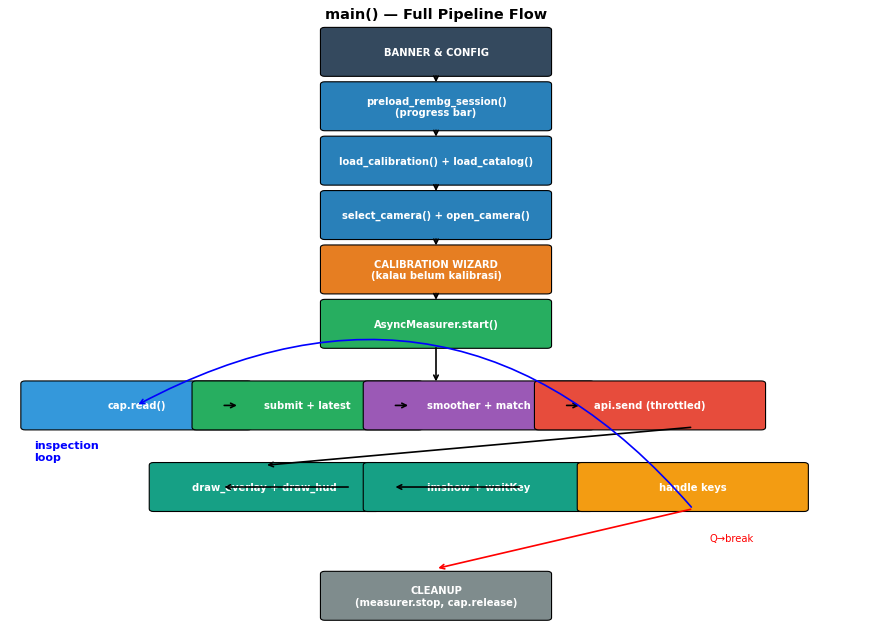

In [148]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 11)
boxes = [
    (5, 10.5, 'BANNER & CONFIG', '#34495e'),
    (5, 9.5,  'preload_rembg_session()\n(progress bar)', '#2980b9'),
    (5, 8.5,  'load_calibration() + load_catalog()', '#2980b9'),
    (5, 7.5,  'select_camera() + open_camera()', '#2980b9'),
    (5, 6.5,  'CALIBRATION WIZARD\n(kalau belum kalibrasi)', '#e67e22'),
    (5, 5.5,  'AsyncMeasurer.start()', '#27ae60'),
    (1.5, 4, 'cap.read()', '#3498db'),
    (3.5, 4, 'submit + latest', '#27ae60'),
    (5.5, 4, 'smoother + match', '#9b59b6'),
    (7.5, 4, 'api.send (throttled)', '#e74c3c'),
    (3, 2.5, 'draw_overlay + draw_hud', '#16a085'),
    (5.5, 2.5, 'imshow + waitKey', '#16a085'),
    (8, 2.5, 'handle keys', '#f39c12'),
    (5, 0.5, 'CLEANUP\n(measurer.stop, cap.release)', '#7f8c8d'),
]
for x, y, lbl, c in boxes:
    box = FancyBboxPatch((x-1.3, y-0.4), 2.6, 0.8, boxstyle='round,pad=0.05',
                         facecolor=c, edgecolor='black', linewidth=1)
    ax.add_patch(box)
    ax.text(x, y, lbl, ha='center', va='center', color='white', fontsize=9, weight='bold')
# Sequential arrows
for y0, y1 in [(10.1, 9.9), (9.1, 8.9), (8.1, 7.9), (7.1, 6.9), (6.1, 5.9), (5.1, 4.4)]:
    ax.annotate('', xy=(5, y1), xytext=(5, y0), arrowprops=dict(arrowstyle='->', lw=1.5))
# Loop arrows
for x0, x1 in [(2.5, 2.7), (4.5, 4.7), (6.5, 6.7)]:
    ax.annotate('', xy=(x1, 4), xytext=(x0, 4), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(3, 2.9), xytext=(8, 3.6), arrowprops=dict(arrowstyle='->', lw=1.5))
for x0, x1 in [(4, 2.5), (6, 4.5)]:
    ax.annotate('', xy=(x1, 2.5), xytext=(x0, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
# Loop back
ax.annotate('', xy=(1.5, 4), xytext=(8, 2.1), arrowprops=dict(arrowstyle='->', lw=1.5, color='blue',
            connectionstyle='arc3,rad=0.4'))
ax.text(0.3, 3, 'inspection\nloop', color='blue', fontsize=10, weight='bold')
# Q → cleanup
ax.annotate('', xy=(5, 1), xytext=(8, 2.1), arrowprops=dict(arrowstyle='->', lw=1.5, color='red'))
ax.text(8.2, 1.5, 'Q→break', color='red', fontsize=9)
ax.set_title('main() — Full Pipeline Flow', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

## Penutup

Semua 39 functions/classes dari `edge_camera.py` sudah dijelaskan dengan markdown + source + demo output.

Untuk run actual inspection loop:
```bash
python3 edge_camera.py
```

Tuning env vars:
```bash
env REMBG_ALPHA_MATTING=1 python3 edge_camera.py             # sharper edges
env REMBG_PROVIDER=coreml python3 edge_camera.py             # force CoreML (Mac M-series)
env REMBG_MODEL=birefnet-general-lite python3 edge_camera.py # better model
```
